# **02. MLSA Models**

## **Introduction**
Development and evaluation of Artificial Intelligence for Survival (Machine Learning for Survival Analysis) models for predicting survival in prostate cancer patients, using data from [the data preparation and analysis notebook](https://colab.research.google.com/drive/1ALQsx7YEigy1LPti5yYw-Vb48Wyaq0X4?usp=drive_link) and machine learning techniques.

## **Imports**

In [ ]:
%%capture

# Libraries
!pip install lifelines
!pip install shap
!pip install optuna
!pip install cmaes
!pip install scikit-survival


In [ ]:
# Imports
seed = 1

import os
import pickle
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib

from scipy.interpolate import interp1d

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, MinMaxScaler, MaxAbsScaler, QuantileTransformer
from sklearn.metrics import roc_curve, roc_auc_score, auc, ConfusionMatrixDisplay, classification_report, confusion_matrix
from sklearn.inspection import permutation_importance

from sksurv.ensemble import RandomSurvivalForest
from sksurv.ensemble import GradientBoostingSurvivalAnalysis
from sksurv.svm import FastSurvivalSVM
from sksurv.util import Surv
from sksurv.metrics import concordance_index_censored, concordance_index_ipcw, brier_score
from sksurv.nonparametric import kaplan_meier_estimator

from lifelines.statistics import logrank_test
from lifelines import KaplanMeierFitter

import xgboost as xgb
from xgboost import XGBRegressor
import lightgbm as lgb

import optuna
from optuna.samplers import RandomSampler, TPESampler, CmaEsSampler

import shap

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

## **Functions**

In [ ]:
# Importing the functions
!gdown 1pAV7B9_BYIMRiC5_O1nMW2E9Qu5O57F0 --quiet

from functions_ml_survival import *

# **Preparation for comparing survival models**

## **Train e Test**

Dividing the database into training and testing components.

In [ ]:
# Prostate Dataset
!gdown 1ZSljungAYB8ElWTk3ZNNnO3KAxgAgc8h --quiet

In [ ]:
https://drive.google.com/file/d/1ZSljungAYB8ElWTk3ZNNnO3KAxgAgc8h/view?usp=drive_link

In [ ]:
# Reading data
df = pd.read_csv('df_prostata.csv')  # Load the dataset from a CSV file
print(df.shape)  # Print the dimensions of the DataFrame
df.head(3)

(28385, 34)


,INSTITU,ESCOLARI,IDADE,CEP,IBGE,CATEATEND,DIAGPREV,TOPO,TOPOGRUP,MORFO,...,HABILIT_HOSP,DISTANCIA_CARRO,ULTIDIAG,TRATCONS_CAT,DIAGTRAT_CAT,OBITO_GERAL,ivs_infraestrutura_urbana,ivs_capital_humano,ivs_renda_e_trabalho,meses_diag
0,20737,1,98,14787012,3505500.0,2,1,C619,C61,85503,...,1,0,573,0,0,1,0,1,0,20
1,10,2,98,17022091,3506003.0,2,2,C619,C61,81403,...,2,1,1828,0,0,0,0,1,0,61
2,15,2,98,13847176,3530706.0,2,1,C619,C61,85503,...,0,0,248,2,2,1,0,1,1,9


In [ ]:
# Exclude patients with EC = 0 (In Situ)
# df = df[df.ECGRUP_CAT != 'In Situ']

# Exclude patients with morphology ending in 2
df = df[~df['MORFO'].astype(str).str.endswith('2')]

# Exclude patients with morphology starting with 9
df = df[~df.MORFO.isin([90143, 90153])]

df.shape

(28379, 34)

In [ ]:
# Columns
df.columns

Index(['INSTITU', 'ESCOLARI', 'IDADE', 'CEP', 'IBGE', 'CATEATEND', 'DIAGPREV',
       'TOPO', 'TOPOGRUP', 'MORFO', 'EC', 'ECGRUP', 'PSA', 'GLEASON',
       'ANODIAG', 'DRS', 'RRAS', 'DSCINST', 'IBGEATEN', 'DRS_INST',
       'RRAS_INST', 'CIDADE_INST', 'BAIRRO_RESID', 'BAIRRO_HOSP',
       'HABILIT_HOSP', 'DISTANCIA_CARRO', 'ULTIDIAG', 'TRATCONS_CAT',
       'DIAGTRAT_CAT', 'OBITO_GERAL', 'ivs_infraestrutura_urbana',
       'ivs_capital_humano', 'ivs_renda_e_trabalho', 'meses_diag'],
      dtype='object')

In [ ]:
# Overall Survival
df['OBITO_GERAL'].value_counts()

,count
OBITO_GERAL,
0,20095
1,8284


In [ ]:
# PSA Frequency
psa_freq = df['PSA'].value_counts(dropna=False).sort_index()
psa_pct = df['PSA'].value_counts(normalize=True, dropna=False).sort_index() * 100

# Frequências Gleason
gleason_freq = df['GLEASON'].value_counts(dropna=False).sort_index()
gleason_pct = df['GLEASON'].value_counts(normalize=True, dropna=False).sort_index() * 100

# Categorias existentes em ambas
categorias = sorted(set(psa_freq.index).union(set(gleason_freq.index)))

# Tabela resumo
tabela = pd.DataFrame(index=categorias)

tabela['PSA (n)'] = psa_freq.reindex(categorias, fill_value=0)
tabela['PSA (%)'] = psa_pct.reindex(categorias, fill_value=0).round(2)

tabela['GLEASON (n)'] = gleason_freq.reindex(categorias, fill_value=0)
tabela['GLEASON (%)'] = gleason_pct.reindex(categorias, fill_value=0).round(2)

print(tabela)

   PSA (n)  PSA (%)  GLEASON (n)  GLEASON (%)
1    16903    59.56         9482        33.41
2     6086    21.45        13079        46.09
3     5390    18.99         5818        20.50


In [ ]:
# Data Splitting into Training and Testing Sets
# Separate features (X) and target variable (y)
X = df.drop(['OBITO_GERAL'], axis=1)  # Features (all columns except 'obito_geral')
y = df['OBITO_GERAL']  # Target variable ('obito_geral')

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,  # 80% train, 20% test
                                                    random_state=seed,  # For reproducibility
                                                    stratify=y)  # Stratified sampling to maintain class proportions

# Print the shapes of the resulting datasets
print(f'X_train: {X_train.shape}')
print(f'y_train: {y_train.shape}')
print(f'X_test: {X_test.shape}')
print(f'y_test: {y_test.shape}')

X_train: (22703, 33)
y_train: (22703,)
X_test: (5676, 33)
y_test: (5676,)


In [ ]:
# Saving the Datasets
# Concatenate features and target variable for training and testing sets
df_treino = pd.concat([X_train, y_train], axis=1)  # Combine X_train and y_train into a single DataFrame
df_teste = pd.concat([X_test, y_test], axis=1)  # Combine X_test and y_test into a single DataFrame

# Save the DataFrames to CSV files
df_treino.to_csv('prostata_treino.csv', index=False)  # Save the training DataFrame to 'prostata_treino.csv'
df_teste.to_csv('prostata_teste.csv', index=False)  # Save the testing DataFrame to 'prostata_teste.csv'

## **Kaplan-Meier**

A non-parametric statistical method used to estimate patient survival probability over time, allowing visualization and comparison of survival curves between groups.

In [ ]:
# Reading Test Data
df_teste = pd.read_csv('prostata_teste.csv')  # Load the test data from the CSV file
print(df_teste.shape)  # Print the dimensions of the test DataFrame
df_teste.head(3)  # Display the first 3 rows of the test DataFrame

(5676, 34)


,INSTITU,ESCOLARI,IDADE,CEP,IBGE,CATEATEND,DIAGPREV,TOPO,TOPOGRUP,MORFO,...,HABILIT_HOSP,DISTANCIA_CARRO,ULTIDIAG,TRATCONS_CAT,DIAGTRAT_CAT,ivs_infraestrutura_urbana,ivs_capital_humano,ivs_renda_e_trabalho,meses_diag,OBITO_GERAL
0,20737,2,55,15802125,3511102.0,2,2,C619,C61,85503,...,1,3,2450,2,2,0,1,0,82,0
1,21130,3,64,14860000,3505609.0,2,1,C619,C61,85503,...,1,2,3383,2,2,3,2,1,113,0
2,21130,2,60,15970000,3546504.0,2,2,C619,C61,85503,...,1,3,2858,0,0,1,1,1,96,0


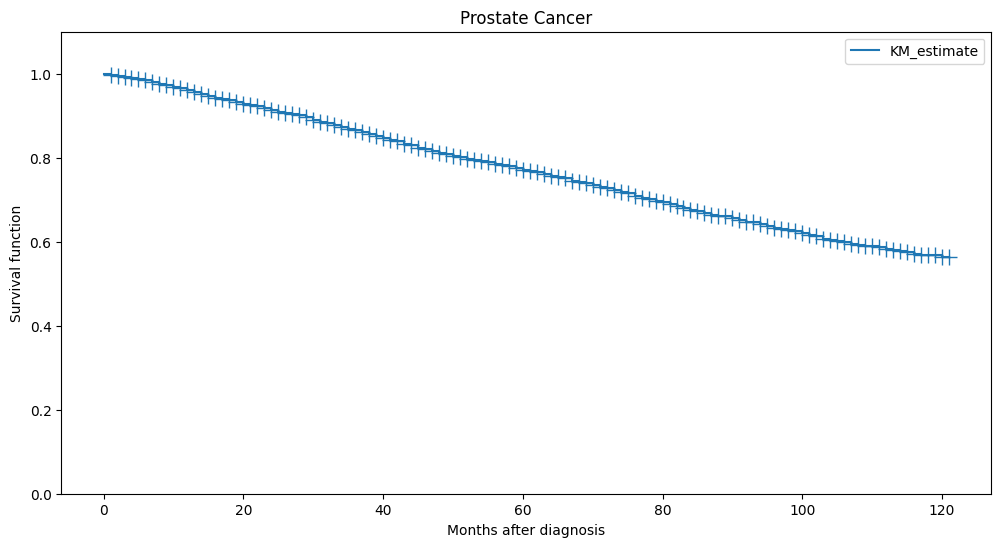

In [ ]:
# Kaplan-Meier Survival Curve Plot
# Reading Test Data to ensure 'meses_diag' and 'obito_geral' are present
df_teste = pd.read_csv('prostata_teste.csv')

# Extract event (E) and time (T) data from the test set
E = (df_teste.OBITO_GERAL == 1)  # Event indicator (obito_geral = 1 means event occurred)
T = df_teste.meses_diag  # Time to event (months since diagnosis)

title = f'Prostate Cancer'  # Set the plot title

kmf = KaplanMeierFitter()  # Initialize the Kaplan-Meier fitter

fig = plt.figure(figsize=(12, 6))  # Create the plot figure
ax = plt.subplot(111)  # Create the axes for the plot

# Fit and plot the Kaplan-Meier survival curve
ax = kmf.fit(T, E).plot(ax=ax, ci_show=False, show_censors=True)  # Fit the model, plot the curve, show censoring marks
ax.set_title(title)  # Set the plot title
ax.set_xlabel('Months after diagnosis')  # Set the x-axis label
ax.set_ylabel('Survival function')  # Set the y-axis label
plt.ylim([0, 1.1])  # Set y-axis limits
plt.show()  # Display the plot

In [ ]:
# Survival at 1, 3, 5, 7, and 10 Years
# Access survival probabilities at specific time points (12, 36, 60, 84, and 120 months)
kmf.survival_function_.loc[[12, 36, 60, 84, 120]]

,KM_estimate
timeline,
12.0,0.961365
36.0,0.865632
60.0,0.771449
84.0,0.675989
120.0,0.564650


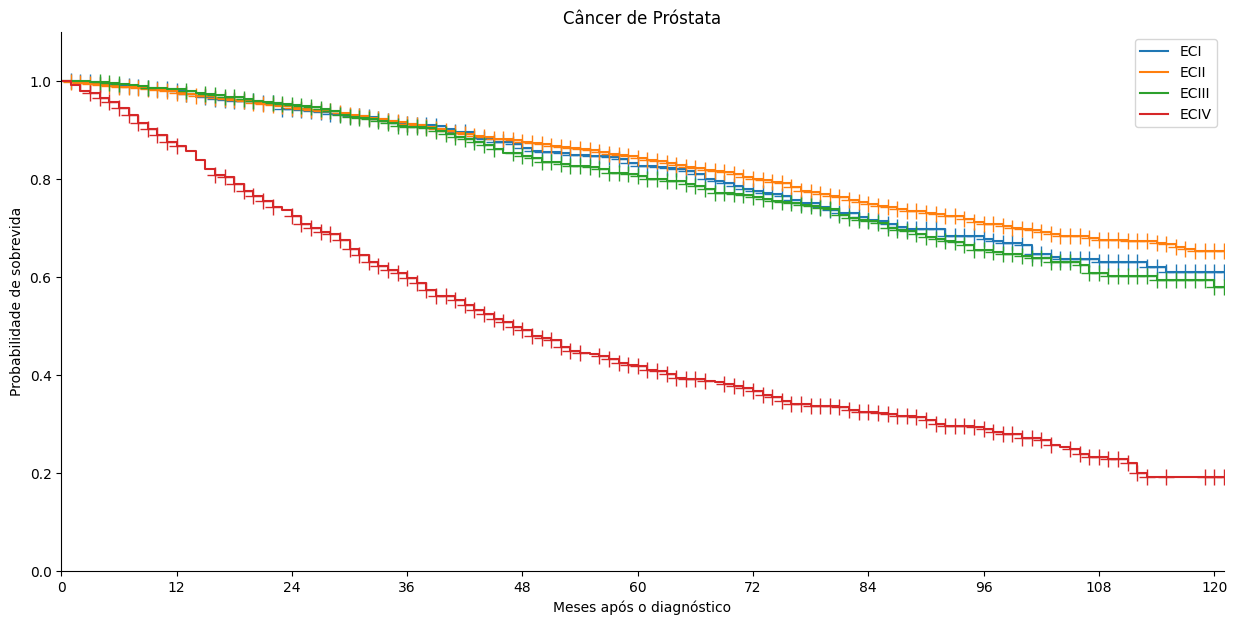

In [ ]:
data = df_teste

E = (data.OBITO_GERAL == 1)
T = data.meses_diag
title = 'Câncer de Próstata'

fig = plt.figure(figsize=(15, 7))
ax = plt.subplot(111)

group1 = (data.ECGRUP == 'I')
label1 = 'ECI'
kmf1 = KaplanMeierFitter()
T1=T[group1]
E1=E[group1]

group2 = (data.ECGRUP == 'II')
label2 = 'ECII'
kmf2 = KaplanMeierFitter()
T2=T[group2]
E2=E[group2]

group3 = (data.ECGRUP == 'III')
label3 = 'ECIII'
kmf3 = KaplanMeierFitter()
T3=T[group3]
E3=E[group3]

group4 = (data.ECGRUP == 'IV')
label4 = 'ECIV'
kmf4 = KaplanMeierFitter()
T4=T[group4]
E4=E[group4]

ax = kmf1.fit(T1, E1, label=label1).plot(ax=ax, ci_show=False, show_censors=True)
ax = kmf2.fit(T2, E2, label=label2).plot(ax=ax, ci_show=False, show_censors=True)
ax = kmf3.fit(T3, E3, label=label3).plot(ax=ax, ci_show=False, show_censors=True)
ax = kmf4.fit(T4, E4, label=label4).plot(ax=ax, ci_show=False, show_censors=True)

ax.set_title(title)
ax.set_xlabel('Meses após o diagnóstico')
ax.set_ylabel('Probabilidade de sobrevida')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks(np.arange(0, 132, 12))
plt.ylim([0, 1.1])
plt.xlim([0, 121])

plt.savefig('prostata.svg')

In [ ]:
months = [12, 24, 36, 48, 60, 72, 84, 96, 108, 120]

df_at_risk = pd.DataFrame(index=kmf1.event_table.iloc[months].index)

df_at_risk['at_risk_ECI'] = kmf1.event_table.loc[months]['at_risk'].to_list()
df_at_risk['at_risk_ECII'] = kmf2.event_table.loc[months]['at_risk'].to_list()
df_at_risk['at_risk_ECIII'] = kmf3.event_table.loc[months]['at_risk'].to_list()
df_at_risk['at_risk_ECIV'] = kmf4.event_table.loc[months]['at_risk'].to_list()

df_at_risk

,at_risk_ECI,at_risk_ECII,at_risk_ECIII,at_risk_ECIV
event_at,,,,
12.0,742,2959,954,721
24.0,677,2759,894,589
36.0,620,2525,803,457
48.0,566,2268,701,349
60.0,490,1955,599,266
72.0,365,1464,456,189
84.0,265,1022,321,127
96.0,182,690,186,85
108.0,101,371,107,44


# **Machine Learning Survival**

Predictive models designed for survival analysis that simultaneously estimate the time until an event occurs and the occurrence outcome itself, enabling risk and prognosis assessment.

## **Machine Learning Survival - Baseline**

The training process was conducted without 'GLEASON' or 'PSA' features.

### Best Model Results - RSF and XGB-AFT on different metrics
- C-Index: RSF - 0,7423
- C-Index IPCW: XGB-AFT - 0,7105

### **Data preparation for survival models**

In [ ]:
# Reading Training Data
df_treino = pd.read_csv('prostata_treino.csv')  # Load the training data from the CSV file
print(df_treino.shape)  # Print the dimensions of the training DataFrame

df_treino.head(3).style.set_sticky(axis="columns") # Display the first 3 rows of the training DataFrame

(22703, 34)


,INSTITU,ESCOLARI,IDADE,CEP,IBGE,CATEATEND,DIAGPREV,TOPO,TOPOGRUP,MORFO,EC,ECGRUP,PSA,GLEASON,ANODIAG,DRS,RRAS,DSCINST,IBGEATEN,DRS_INST,RRAS_INST,CIDADE_INST,BAIRRO_RESID,BAIRRO_HOSP,HABILIT_HOSP,DISTANCIA_CARRO,ULTIDIAG,TRATCONS_CAT,DIAGTRAT_CAT,ivs_infraestrutura_urbana,ivs_capital_humano,ivs_renda_e_trabalho,meses_diag,OBITO_GERAL
0,20737,3,78,15790000,3544509.000000,2,2,C619,C61,85503,IIA,II,1,2,2017,15,RRAS 12,FUND PIO XII,3505500,5,RRAS 13,BARRETOS,nan,Centro,1,3,2591,3,3,0,0,1,87,0
1,208068,3,64,8693190,3552502.000000,2,2,C619,C61,81403,IIA,II,1,1,2014,1,RRAS 02,HOSP CLINICAS LUZIA PINHO MELO,3530607,1,RRAS 02,MOGI DAS CRUZES,Cidade Boa Vista,Vila Mogilar,0,1,1932,0,0,3,1,2,65,0
2,16624,2,65,4863600,3550308.000000,2,2,C619,C61,81403,IIA,II,1,2,2014,1,RRAS 06,IAVC,3550308,1,RRAS 06,SAO PAULO,Jardim Arco-Iris,Vila Buarque,1,2,3734,1,2,3,1,1,121,0


In [ ]:
# Reading Test Data
df_teste = pd.read_csv('prostata_teste.csv')  # Load the test data from the CSV file
print(df_teste.shape)  # Print the dimensions of the test DataFrame

df_teste.head(3).style.set_sticky(axis="columns")  # Display the first 3 rows of the test DataFrame

(5676, 34)


,INSTITU,ESCOLARI,IDADE,CEP,IBGE,CATEATEND,DIAGPREV,TOPO,TOPOGRUP,MORFO,EC,ECGRUP,PSA,GLEASON,ANODIAG,DRS,RRAS,DSCINST,IBGEATEN,DRS_INST,RRAS_INST,CIDADE_INST,BAIRRO_RESID,BAIRRO_HOSP,HABILIT_HOSP,DISTANCIA_CARRO,ULTIDIAG,TRATCONS_CAT,DIAGTRAT_CAT,ivs_infraestrutura_urbana,ivs_capital_humano,ivs_renda_e_trabalho,meses_diag,OBITO_GERAL
0,20737,2,55,15802125,3511102.000000,2,2,C619,C61,85503,IIB,II,1,2,2018,15,RRAS 12,FUND PIO XII,3505500,5,RRAS 13,BARRETOS,Parque Residencial Agudo Romão,Centro,1,3,2450,2,2,0,1,0,82,0
1,21130,3,64,14860000,3505609.000000,2,1,C619,C61,85503,I,I,1,1,2015,13,RRAS 13,HOSP CLINICAS DE RIBEIRAO PRETO,3543402,13,RRAS 13,RIBEIRAO PRETO,nan,Vila Monte Alegre,1,2,3383,2,2,3,2,1,113,0
2,21130,2,60,15970000,3546504.000000,2,2,C619,C61,85503,IIA,II,1,1,2016,3,RRAS 18,HOSP CLINICAS DE RIBEIRAO PRETO,3543402,13,RRAS 13,RIBEIRAO PRETO,nan,Vila Monte Alegre,1,3,2858,0,0,1,1,1,96,0


In [ ]:
# Y train and test for survival data (Death, Months from Diagnosis)
y_train = Surv.from_arrays(df_treino.OBITO_GERAL, df_treino.meses_diag)  # Create survival data for training set
y_test = Surv.from_arrays(df_teste.OBITO_GERAL, df_teste.meses_diag)  # Create survival data for test set

In [ ]:
# X train and test after removing unnecessary columns, including Death and Months from Diagnosis (which go to the target Y)
list_drop = ['CEP', 'TOPO', 'TOPOGRUP','EC', 'RRAS','DSCINST', 'RRAS_INST',
             'CIDADE_INST', 'BAIRRO_RESID', 'BAIRRO_HOSP','ULTIDIAG',
             'OBITO_GERAL', 'meses_diag', 'PSA', 'GLEASON','DISTANCIA_CARRO',
             'ivs_infraestrutura_urbana', 'ivs_capital_humano',
             'ivs_renda_e_trabalho',]

X_train = df_treino.drop(list_drop, axis=1)  # Remove specified columns from the training dataset

X_test = df_teste.drop(list_drop, axis=1)  # Remove specified columns from the test dataset

In [ ]:
# Preprocessing of Training and Test data
X_train, X_test, feat_cols, enc, norm = preprocessing(X_train, X_test,
                                                      norm_name='StandardScaler',  # Specify normalization method
                                                      return_enc_norm=True,  # Return encoder and normalizer objects
                                                      random_state=seed)  # Set random state for reproducibility

# Display the shapes of the processed training and test datasets
X_train.shape, X_test.shape

((22703, 15), (5676, 15))

In [ ]:
# Features columns
feat_cols

Index(['INSTITU', 'ESCOLARI', 'IDADE', 'IBGE', 'CATEATEND', 'DIAGPREV',
       'MORFO', 'ECGRUP', 'ANODIAG', 'DRS', 'IBGEATEN', 'DRS_INST',
       'HABILIT_HOSP', 'TRATCONS_CAT', 'DIAGTRAT_CAT'],
      dtype='object')

### **Random Survival Forest**

#### **Base Model**

In [ ]:
%%time
# RSF (Random Survival Forest) Model
rsf = RandomSurvivalForest(max_depth=10, n_jobs=-1, random_state=seed)  # Initialize the RSF model with a max depth of 10
rsf.fit(X_train, y_train)  # Train the model using the training data

# Calculate the C-index for the test dataset
c_index_base = rsf.score(X_test, y_test)

# Print the C-index for both test and training datasets
print(f'C-Index Test: {c_index_base}')
print(f'C-Index Train: {rsf.score(X_train, y_train)}')

C-Index Test: 0.7412026485897766
C-Index Train: 0.7799314168135085
CPU times: user 9.72 s, sys: 1.8 s, total: 11.5 s
Wall time: 1.42 s


C-Index IPCW Teste: 0.7084572705862782
C-Index IPCW Treino: 0.7511275646999366

Integrated Brier Score (IBS): 0.13239861501969297

Brier Score:
    > 1 ano = 0.03181045146570221
    > 3 anos = 0.09635564075256035
    > 5 anos = 0.14155286810004816



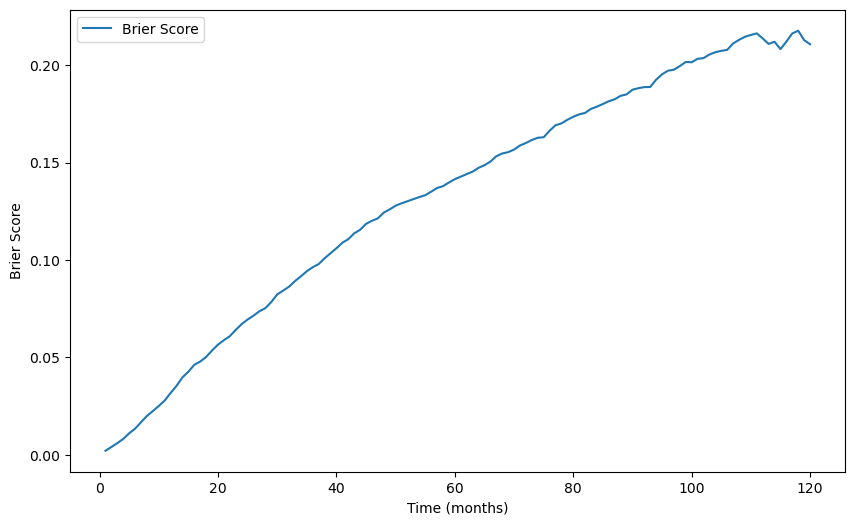

In [ ]:
# C-Index IPCW and Brier Score
c_index_ipcw_brier_score(rsf, X_train, y_train, X_test, y_test)  # Compute and evaluate the IPCW C-index and Brier Score

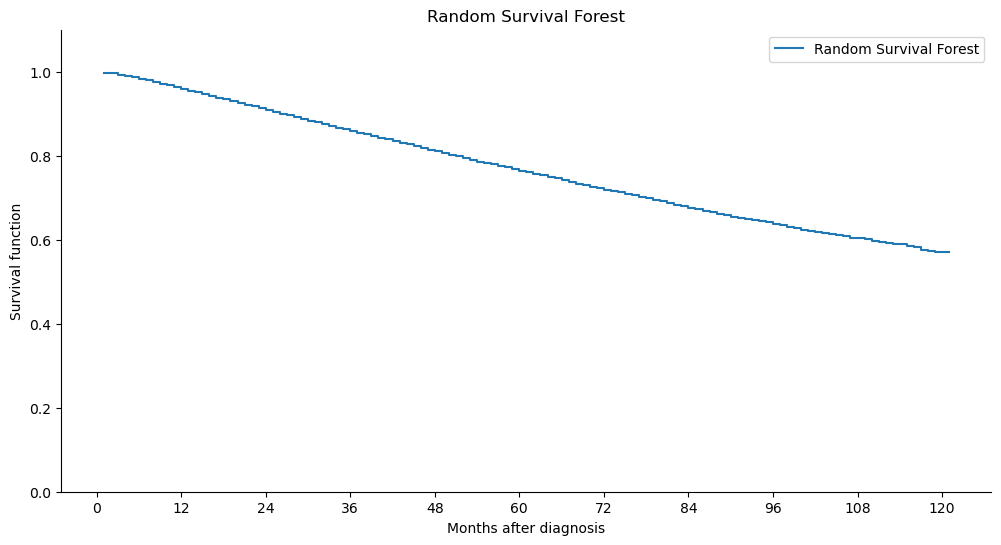

In [ ]:
# Survival prediction (Probability)
surv_rsf = rsf.predict_survival_function(X_test, return_array=True)  # Predict survival probabilities for the test set
surv_rsf_mean = surv_rsf.mean(axis=0)  # Compute the mean survival probability across samples

# Plot the predicted survival curve
name = 'Random Survival Forest'

plot_survival_curve(rsf.unique_times_, surv_rsf_mean, name=name)  # Generate and display the survival curve

In [ ]:
# Survival probability at 12, 36, 60, 84 and 120 months
print(f'12 months: {surv_rsf_mean[12]}')  # Print survival probability at 12 months
print(f'36 months: {surv_rsf_mean[36]}')  # Print survival probability at 36 months
print(f'60 months: {surv_rsf_mean[60]}')  # Print survival probability at 60 months
print(f'84 months: {surv_rsf_mean[84]}')  # Print survival probability at 84 months
print(f'120 months: {surv_rsf_mean[120]}')  # Print survival probability at 120 months

12 months: 0.9552453603361368
36 months: 0.8544021696033001
60 months: 0.7608374568447626
84 months: 0.672297666581204
120 months: 0.569623114088658


#### **Optuna**

**Principais Hiperparâmetros para Otimização no RSF**

1. `n_estimators` (int)
* Descrição: Número de árvores na floresta. Mais árvores geralmente aumentam a precisão, mas podem tornar o treinamento mais lento.
* Sugestão de valores: 50 a 1000.

2. `max_depth` (int)
* Descrição: Profundidade máxima das árvores. Uma maior profundidade permite capturar padrões complexos, mas pode levar ao overfitting.
* Sugestão de valores: 3 a 30.

3. `min_samples_split` (int)
* Descrição: Número mínimo de amostras necessárias para dividir um nó. Controla o crescimento da árvore. Valores mais altos evitam o overfitting.
* Sugestão de valores: 2 a 20.

4. `min_samples_leaf` (int)
* Descrição: Número mínimo de amostras necessárias para formar uma folha. Valores maiores evitam folhas com muito poucas amostras, reduzindo o overfitting.
* Sugestão de valores: 1 a 50.

5. `max_features` (float, int, str)
* Descrição: Proporção ou número de recursos a serem considerados ao dividir um nó. Define a aleatoriedade do modelo, balanceando viés e variância.

    a) 'sqrt': Considera a raiz quadrada do total de features.

    b) 'log2': Considera o logaritmo base 2 do total de features.

    c) Valores numéricos: Pode ser um número específico ou uma proporção das features.

* Sugestão de valores: 'sqrt', 'log2', ou entre 0.1 e 1.0.

6. `bootstrap` (bool)
* Descrição: Se as amostras de treino são extraídas com ou sem reposição. Aumenta a diversidade entre as árvores, reduzindo o overfitting.
* Sugestão de valores: True ou False.

7. `oob_score` (bool)
* Descrição: Se o modelo deve calcular o erro fora da amostra (out-of-bag) durante o treinamento. Pode fornecer uma estimativa do desempenho sem a necessidade de um conjunto de validação separado.
* Sugestão de valores: True ou False.

8. `n_jobs` (int)
* Descrição: Número de processadores a serem usados em paralelo. Define a quantidade de processamento paralelo.
* Sugestão de valores: -1 (usa todos os processadores disponíveis).

9. `min_weight_fraction_leaf` (float)
* Descrição: Fração mínima do peso total das amostras que deve estar em cada folha. Previne folhas muito pequenas com base no peso das amostras.
* Sugestão de valores: 0.0 a 0.5.

In [ ]:
# Optuna number of trials
n_trials = 128

In [ ]:
# Folds for cross-validation
kf = KFold(n_splits=10, shuffle=True, random_state=seed)  # Create a 10-fold cross-validation strategy

# Function to compute the C-index for a given estimator
def c_index(estimator, X, y):
    cindex = estimator.score(X, y)  # Compute the C-index score
    return cindex

# Objective function for hyperparameter optimization
def objective(trial):
    # Define hyperparameters to be optimized
    n_estimators = trial.suggest_int('n_estimators', 50, 150)  # Number of trees in the forest
    max_depth = trial.suggest_int('max_depth', 5, 10)  # Maximum depth of each tree
    min_samples_split = trial.suggest_int('min_samples_split', 3, 12)  # Min samples required to split a node
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 3, 12)  # Min samples required at a leaf node
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.5, 0.75, 1.0])  # Feature selection strategy
    bootstrap = trial.suggest_categorical('bootstrap', [True, False])  # Whether to use bootstrap sampling

    # Create and train the model with the suggested hyperparameters
    rsf = RandomSurvivalForest(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        bootstrap=bootstrap,
        random_state=seed,
        n_jobs=-1
    )

    # Perform cross-validation and return the mean C-index score
    return cross_val_score(rsf, X_train, y_train, cv=kf, scoring=c_index).mean()

**RandomSampler**

In [ ]:
# # Otimização dos hiperparâmetros com Optuna - RandomSampler
# study = optuna.create_study(direction='maximize', sampler=RandomSampler(seed),
#                             study_name='RSF_RandomSampler')
# study.optimize(objective, n_trials=n_trials, n_jobs=-1)

In [ ]:
%%time
# Pickle filename to save the study
pickle_filename = 'prost_opt_rsf_rand.pkl'

# Load existing study or create a new one
if os.path.exists(pickle_filename):
    with open(pickle_filename, 'rb') as f:
        study = pickle.load(f)
else:
    study = optuna.create_study(direction='maximize', sampler=RandomSampler(seed=seed),
                                study_name='RSF_RandomSampler')

# Total number of desired trials
completed_trials = len(study.trials)

# Execute remaining trials in batches
while completed_trials < n_trials:
    study.optimize(objective, n_trials=128, n_jobs=-1)
    completed_trials = len(study.trials)
    print(f"\nTrials completed: {completed_trials}/{n_trials}")

    # Save the study after each batch
    with open(pickle_filename, 'wb') as f:
        pickle.dump(study, f)

[I 2026-06-12 11:09:00,978] A new study created in memory with name: RSF_RandomSampler
[I 2026-06-12 11:16:46,347] Trial 97 finished with value: 0.7344586725534329 and parameters: {'n_estimators': 50, 'max_depth': 5, 'min_samples_split': 6, 'min_samples_leaf': 7, 'max_features': 'log2', 'bootstrap': True}. Best is trial 97 with value: 0.7344586725534329.
[I 2026-06-12 11:16:47,287] Trial 15 finished with value: 0.7402183525551806 and parameters: {'n_estimators': 72, 'max_depth': 7, 'min_samples_split': 11, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 15 with value: 0.7402183525551806.
[I 2026-06-12 11:16:47,938] Trial 30 finished with value: 0.7390280007347549 and parameters: {'n_estimators': 61, 'max_depth': 7, 'min_samples_split': 8, 'min_samples_leaf': 11, 'max_features': 'sqrt', 'bootstrap': False}. Best is trial 15 with value: 0.7402183525551806.
[I 2026-06-12 11:16:48,722] Trial 104 finished with value: 0.7377324712139706 and parameters: {'n_es


Trials completed: 128/128
CPU times: user 4h 21min 39s, sys: 4min 43s, total: 4h 26min 22s
Wall time: 7min 54s


In [ ]:
# Display the best hyperparameters found by Optuna
print('Best parameters:', study.best_params)  # Print the best hyperparameters after optimization

Best parameters: {'n_estimators': 127, 'max_depth': 10, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'bootstrap': True}


In [ ]:
# Training and metrics with the best hyperparameters
best_params = study.best_params  # Get the best parameters from the study
rsf_rand = RandomSurvivalForest(**best_params, random_state=seed)  # Initialize the RSF model with the best parameters
rsf_rand.fit(X_train, y_train)  # Train the model with the training data

# Compute the C-index for the test dataset
c_index_rand = rsf_rand.score(X_test, y_test)

# Print the C-index for both test and training datasets
print(f'C-Index Test: {c_index_rand}')
print(f'C-Index Train: {rsf_rand.score(X_train, y_train)}')

C-Index Test: 0.7423124708379746
C-Index Train: 0.7777489519494334


**TPESampler**

In [ ]:
# # Otimização dos hiperparâmetros com Optuna - TPESampler
# study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=seed),
#                             study_name='RSF_TPESampler')
# study.optimize(objective, n_trials=n_trials, n_jobs=-1)

In [ ]:
%%time
# Pickle filename to save the study
pickle_filename = 'prost_opt_rsf_tpe.pkl'

# Load existing study or create a new one
if os.path.exists(pickle_filename):
    with open(pickle_filename, 'rb') as f:
        study = pickle.load(f)
else:
    study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=seed),
                                study_name='RSF_TPESampler')

# Total number of desired trials
completed_trials = len(study.trials)

# Execute remaining trials in batches
while completed_trials < n_trials:
    study.optimize(objective, n_trials=128, n_jobs=-1)
    completed_trials = len(study.trials)
    print(f"\nTrials completed: {completed_trials}/{n_trials}")

    # Save the study after each batch
    with open(pickle_filename, 'wb') as f:
        pickle.dump(study, f)

[I 2026-06-12 11:17:03,735] A new study created in memory with name: RSF_TPESampler
[I 2026-06-12 11:24:19,218] Trial 4 finished with value: 0.7409013682197714 and parameters: {'n_estimators': 50, 'max_depth': 10, 'min_samples_split': 10, 'min_samples_leaf': 7, 'max_features': 0.5, 'bootstrap': True}. Best is trial 4 with value: 0.7409013682197714.
[I 2026-06-12 11:24:21,011] Trial 27 finished with value: 0.7344499568051372 and parameters: {'n_estimators': 52, 'max_depth': 5, 'min_samples_split': 4, 'min_samples_leaf': 11, 'max_features': 0.5, 'bootstrap': False}. Best is trial 4 with value: 0.7409013682197714.
[I 2026-06-12 11:24:21,206] Trial 6 finished with value: 0.7332465283583025 and parameters: {'n_estimators': 58, 'max_depth': 5, 'min_samples_split': 5, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'bootstrap': False}. Best is trial 4 with value: 0.7409013682197714.
[I 2026-06-12 11:24:21,380] Trial 60 finished with value: 0.7388989037679061 and parameters: {'n_estimators': 54


Trials completed: 128/128
CPU times: user 3h 50min 55s, sys: 4min 3s, total: 3h 54min 58s
Wall time: 7min 27s


In [ ]:
# Display the best hyperparameters found by Optuna
print('Best parameters:', study.best_params)  # Print the best hyperparameters after optimization

Best parameters: {'n_estimators': 96, 'max_depth': 10, 'min_samples_split': 4, 'min_samples_leaf': 4, 'max_features': 'log2', 'bootstrap': True}


In [ ]:
# Training and metrics with the best hyperparameters
best_params = study.best_params  # Get the best parameters from the study
rsf_tpe = RandomSurvivalForest(**best_params, random_state=seed)  # Initialize the RSF model with the best parameters
rsf_tpe.fit(X_train, y_train)  # Train the model with the training data

# Compute the C-index for the test dataset
c_index_tpe = rsf_tpe.score(X_test, y_test)

# Print the C-index for both test and training datasets
print(f'C-Index Test: {c_index_tpe}')
print(f'C-Index Train: {rsf_tpe.score(X_train, y_train)}')

C-Index Test: 0.7412767830232461
C-Index Train: 0.7780489994901931


**CmaEsSampler**

In [ ]:
# # Otimização dos hiperparâmetros com Optuna - CmaEsSampler
# study = optuna.create_study(direction='maximize', sampler=CmaEsSampler(seed=seed),
#                             study_name='RSF_CmaEsSampler')
# study.optimize(objective, n_trials=n_trials, n_jobs=-1)

In [ ]:
%%time
# Pickle filename to save the study
pickle_filename = 'prost_opt_rsf_cma.pkl'

# Load existing study or create a new one
if os.path.exists(pickle_filename):
    with open(pickle_filename, 'rb') as f:
        study = pickle.load(f)
else:
    study = optuna.create_study(direction='maximize', sampler=CmaEsSampler(seed=seed),
                                study_name='RSF_CmaEsSampler')

# Total number of desired trials
completed_trials = len(study.trials)

# Execute remaining trials in batches
while completed_trials < n_trials:
    study.optimize(objective, n_trials=128, n_jobs=-1)
    completed_trials = len(study.trials)
    print(f"\nTrials completed: {completed_trials}/{n_trials}")

    # Save the study after each batch
    with open(pickle_filename, 'wb') as f:
        pickle.dump(study, f)

[I 2026-06-12 11:24:37,977] A new study created in memory with name: RSF_CmaEsSampler
[I 2026-06-12 11:31:48,060] Trial 2 finished with value: 0.7438326379414988 and parameters: {'n_estimators': 56, 'max_depth': 10, 'min_samples_split': 5, 'min_samples_leaf': 7, 'max_features': 'sqrt', 'bootstrap': False}. Best is trial 2 with value: 0.7438326379414988.
[I 2026-06-12 11:31:57,513] Trial 1 finished with value: 0.7438547595723745 and parameters: {'n_estimators': 53, 'max_depth': 10, 'min_samples_split': 4, 'min_samples_leaf': 7, 'max_features': 'log2', 'bootstrap': False}. Best is trial 1 with value: 0.7438547595723745.
[I 2026-06-12 11:32:07,931] Trial 67 finished with value: 0.7412385924988318 and parameters: {'n_estimators': 52, 'max_depth': 8, 'min_samples_split': 12, 'min_samples_leaf': 9, 'max_features': 'log2', 'bootstrap': True}. Best is trial 1 with value: 0.7438547595723745.
[I 2026-06-12 11:32:08,801] Trial 119 finished with value: 0.7334029041601077 and parameters: {'n_estima


Trials completed: 128/128
CPU times: user 4h 12min 31s, sys: 4min 6s, total: 4h 16min 38s
Wall time: 7min 39s


In [ ]:
# Display the best hyperparameters found by Optuna
print('Best parameters:', study.best_params)  # Print the best hyperparameters after optimization

Best parameters: {'n_estimators': 79, 'max_depth': 10, 'min_samples_split': 12, 'min_samples_leaf': 5, 'max_features': 'log2', 'bootstrap': True}


In [ ]:
# Training and metrics with the best hyperparameters
best_params = study.best_params  # Get the best parameters from the study
rsf_cma = RandomSurvivalForest(**best_params, random_state=seed)  # Initialize the RSF model with the best parameters
rsf_cma.fit(X_train, y_train)  # Train the model with the training data

# Compute the C-index for the test dataset
c_index_cma = rsf_cma.score(X_test, y_test)

# Print the C-index for both test and training datasets
print(f'C-Index Test: {c_index_cma}')
print(f'C-index Train: {rsf_cma.score(X_train, y_train)}')

C-Index Test: 0.7418401576978891
C-index Train: 0.7769504859838027


#### **Best Random Survival Forest Model**

In [ ]:
# Best RSF model
scores = [c_index_base, c_index_rand, c_index_tpe, c_index_cma]  # List of C-index scores for different models
models = [rsf, rsf_rand, rsf_tpe, rsf_cma]  # List of the corresponding models

# Find the index of the model with the highest C-index score
id_best_score = scores.index(max(scores))
best = models[id_best_score]  # Select the model with the best score

# Print the best model
print(best)

RandomSurvivalForest(max_depth=10, min_samples_leaf=4, min_samples_split=10,
                     n_estimators=127, random_state=1)


C-Index Test: 0.7423124708379746
C-Index Train: 0.7777489519494334

C-Index IPCW Teste: 0.7095478081880052
C-Index IPCW Treino: 0.7498476767229274

Integrated Brier Score (IBS): 0.13204717240759603

Brier Score:
    > 1 ano = 0.03185314420599035
    > 3 anos = 0.09598814287313308
    > 5 anos = 0.14113530306604138



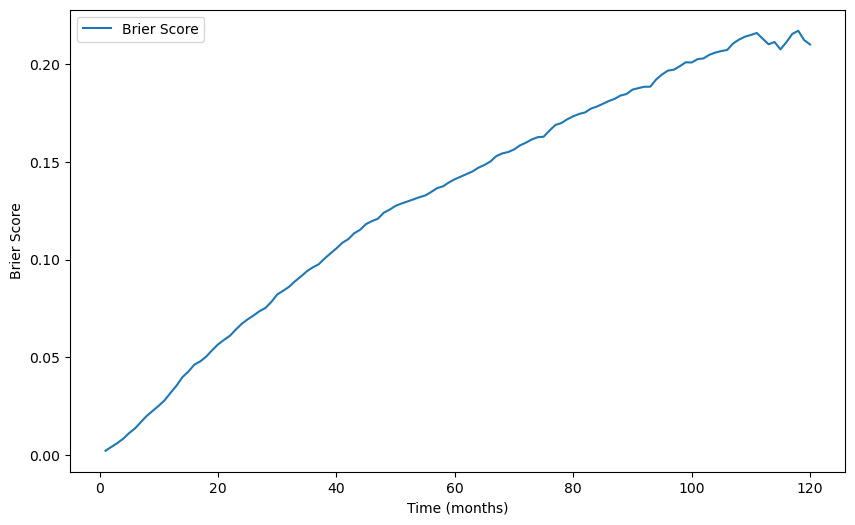

In [ ]:
# Metrics of the best RSF model
final_c_index = best.score(X_test, y_test)  # Compute the final C-index for the test dataset

# Print the C-index for both test and training datasets
print(f'C-Index Test: {final_c_index}')
print(f'C-Index Train: {best.score(X_train, y_train)}\n')

# Compute and display the IPCW C-index and Brier Score for the best model
c_index_ipcw_brier_score(best, X_train, y_train, X_test, y_test)

In [ ]:
# Best features by permutation importance
calculate_permutation_importance(best, X_test, y_test, feat_cols, random_state=seed)  # Calculate permutation importance of features for the best model

,importances_mean,importances_std
ECGRUP,0.101164,0.005276
IDADE,0.065331,0.003246
DIAGTRAT_CAT,0.010754,0.001258
INSTITU,0.009608,0.001486
TRATCONS_CAT,0.008439,0.002230
DRS_INST,0.004561,0.000855
IBGEATEN,0.003191,0.000575
DRS,0.002748,0.000378
DIAGPREV,0.002365,0.000344
MORFO,0.002315,0.000711


PermutationExplainer explainer: 5677it [1:29:10,  1.06it/s]                          


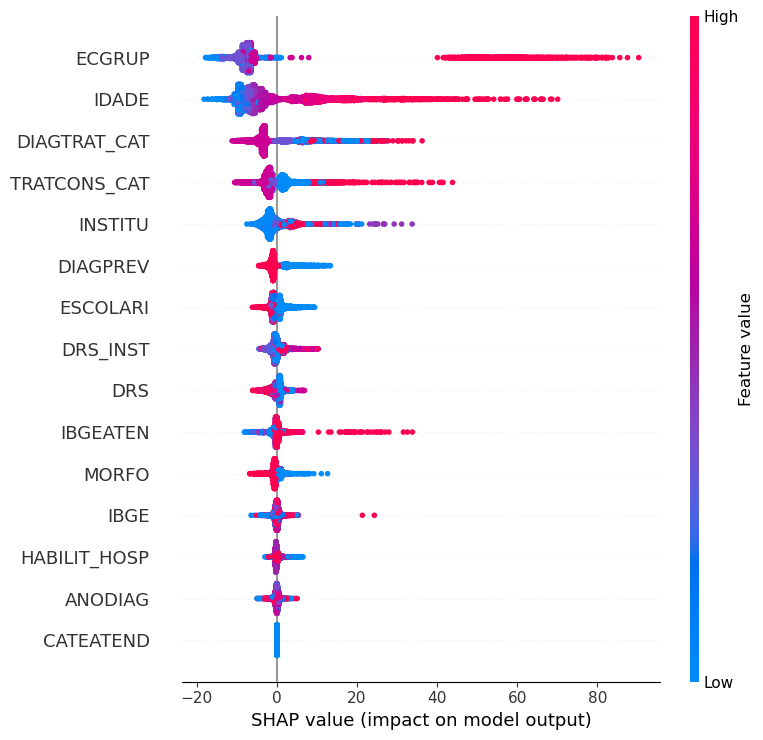

In [ ]:
# Best features by SHAP
explainer = shap.Explainer(best.predict, X_train, seed=seed,  # Create a SHAP explainer for the best model
                           output_names=feat_cols,  # Specify the feature names
                           n_jobs=-1)  # Use multiple jobs for parallel computation

shap_values = explainer(X_test)  # Calculate SHAP values for the test set

# Plot the SHAP summary plot to visualize feature importance
shap.summary_plot(shap_values, X_test, feature_names=feat_cols)

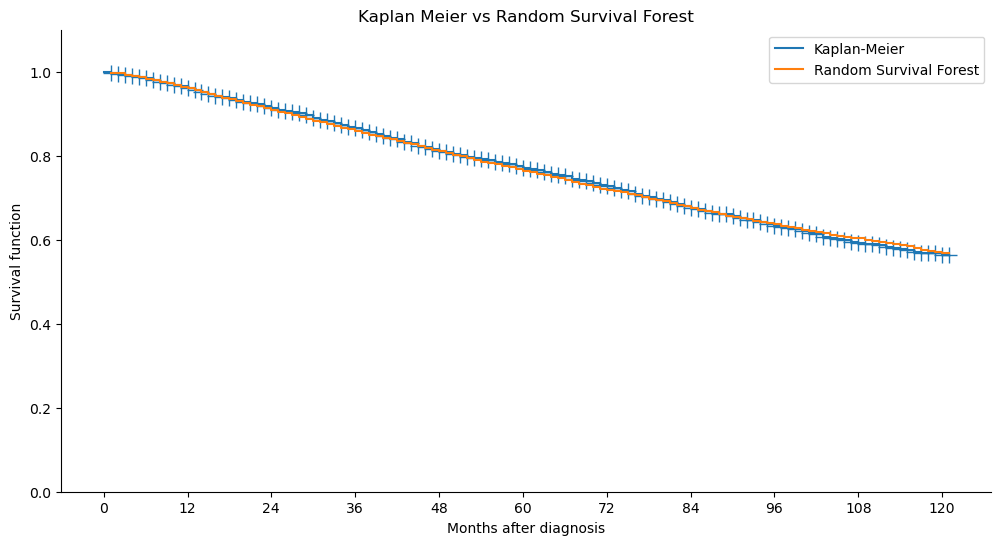

In [ ]:
# Comparison of survival curves
name = 'Random Survival Forest'  # Name of the model to be displayed on the plot

# Predict survival functions for the test set and compute the mean survival function
surv_rsf = best.predict_survival_function(X_test, return_array=True)
surv_rsf_mean = surv_rsf.mean(axis=0)  # Compute the mean survival function across all samples

# Plot the survival curve and compare with Kaplan-Meier (KM) estimates
plot_survival_curve(best.unique_times_, surv_rsf_mean,
                    name=name, compare_km=True, test_df=df_teste)  # Plot the survival curve and compare with the test dataset

### **XGBoost - AFT**

#### **Base Model**

In [ ]:
# Define weights (1.0 for events, 0.7 for censored cases)
weights = np.where(y_train['event'], 1.0, 0.7)

# The AFT model requires lower and upper bounds for survival time
label_lower_bound = y_train['time']
label_upper_bound = np.where(y_train['event'], y_train['time'], np.inf)

# Creating DMatrix for XGBoost (necessary to define bounds for AFT)
dtrain = xgb.DMatrix(X_train,
                     label_lower_bound=label_lower_bound,
                     label_upper_bound=label_upper_bound,
                     weight=weights)

dtest = xgb.DMatrix(X_test)

# Configuration of hyperparameters for the XGBoost Survival AFT model
params = {
    'objective': 'survival:aft',  # Use AFT to model survival analysis
    'eval_metric': 'aft-nloglik',  # Evaluation metric for AFT
    'aft_loss_distribution': 'normal',  # Failure time distribution ('normal', 'logistic', etc.)
    'aft_loss_distribution_scale': 1.0,  # Scale of the distribution (adjustable)
    'max_depth': 4,  # Maximum depth of trees
    'seed': seed,  # Seed for reproducibility
}

# Model training
xgb_aft = xgb.train(params, dtrain, num_boost_round=100)

# Predictions and C-Index calculation for the test set
y_pred = xgb_aft.predict(dtest)
c_index_base = concordance_index_censored(y_test['event'], y_test['time'], -y_pred)[0]

# Predictions and C-Index calculation for the training set
y_pred_train = xgb_aft.predict(dtrain)
c_index_train = concordance_index_censored(y_train['event'], y_train['time'], -y_pred_train)[0]

# Display C-Index results
print(f'C-index Test: {c_index_base}')
print(f'C-index Train: {c_index_train}')

C-index Test: 0.7380140059222912
C-index Train: 0.7845467306713485


In [ ]:
# C-Index IPCW (Inverse Probability of Censoring Weight)
surv_risks = xgb_aft.predict(dtest)  # Predict the survival risks for the test set
surv_risks_train = xgb_aft.predict(dtrain)  # Predict the survival risks for the training set

# Calculate the C-Index IPCW for Test and Train data
c_index_ipcw = concordance_index_ipcw(y_train, y_test, -surv_risks)  # Compute the C-Index IPCW for the test data
c_index_ipcw_train = concordance_index_ipcw(y_train, y_train, -surv_risks_train)  # Compute the C-Index IPCW for the training data

# Display C-Index IPCW for Test and Train data
print(f'C-Index IPCW Test: {c_index_ipcw[0]}')  # Print the C-Index IPCW for the test data
print(f'C-Index IPCW Train: {c_index_ipcw_train[0]}')  # Print the C-Index IPCW for the training data

C-Index IPCW Test: 0.6995276560041962
C-Index IPCW Train: 0.7494623611910396


#### **Optuna**

**Principais Parâmetros a Otimizar no XGBoost**

1. `n_estimators` (int):
* Número de árvores (boosting rounds) que o modelo vai treinar. Mais árvores podem melhorar o aprendizado, mas aumentam o risco de overfitting e o custo computacional.
* Sugestão de valores: 50 a 1000.

2. `learning_rate` (float):
* Taxa de aprendizado usada para diminuir a contribuição de cada árvore. Taxas menores exigem mais árvores, mas aumentam a estabilidade.
* Sugestão de valores: 0.01 a 0.3 (log-scale).

3. `max_depth` (int):
* Profundidade máxima das árvores individuais. Árvores mais profundas captam interações complexas, mas correm maior risco de overfitting.
* Sugestão de valores: 3 a 30.

4. `min_child_weight` (float):
* Peso mínimo da soma dos gradientes (hessian) em uma divisão de nó. Controla o tamanho mínimo de uma divisão, evitando overfitting.
* Sugestão de valores: 1 a 10.

5. `subsample` (float):
* Percentual de amostras utilizadas em cada árvore. Reduz overfitting ao amostrar dados de forma aleatória.
* Sugestão de valores: 0.5 a 1.0.

6. `colsample_bytree` (float):
* Percentual de colunas (features) usadas para cada árvore. Melhora a robustez e evita correlação entre as árvores.
* Sugestão de valores: 0.5 a 1.0.

7. `reg_alpha` (float):
* Regularização L1 (sparsidade). Incentiva a geração de árvores mais esparsas, evitando overfitting.
* Sugestão de valores: 1e-5 a 10 (log-scale).

8. `reg_lambda` (float):
* Regularização L2 (penalização quadrática). Controla a complexidade do modelo.
* Sugestão de valores: 1e-5 a 10 (log-scale).

9. `objective` (str):
* Função objetivo. Para sobrevivência, pode-se usar:

    'survival:cox': Regressão de Cox.
    
    'survival:aft': Modelo AFT (Accelerated Failure Time).

In [ ]:
# Optuna number o trials
n_trials = 128

In [ ]:
# Folds for Cross-Validation
kf = KFold(10, shuffle=True, random_state=seed)  # Create 10-fold cross-validation with shuffling

def objective(trial):
    # Define the hyperparameters to be optimized
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 150),  # Number of estimators (trees)
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.25, step=0.01),  # Learning rate
        'max_depth': trial.suggest_int('max_depth', 2, 5),  # Maximum depth of trees
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),  # Minimum weight of child nodes
        'subsample': trial.suggest_float('subsample', 0.5, 1.0, step=0.05),  # Fraction of data used for training
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0, step=0.05),  # Fraction of features used per tree
        'reg_alpha': trial.suggest_categorical('reg_alpha', [1e-4, 1e-3, 1e-2, 1e-1, 1, 10]),  # L1 regularization term
        'reg_lambda': trial.suggest_categorical('reg_lambda', [1e-4, 1e-3, 1e-2, 1e-1, 1, 10]),  # L2 regularization term
        'aft_loss_distribution': trial.suggest_categorical('aft_loss_distribution', ['normal', 'logistic', 'extreme']),  # AFT Distribution Type
        'aft_loss_distribution_scale': trial.suggest_float('aft_loss_distribution_scale', 0.5, 2.0, step=0.05),  # AFT distribution scale
        'objective': 'survival:aft',  # AFT loss function for survival analysis
        'eval_metric': 'aft-nloglik',  # Evaluation metric for AFT model
        'random_state': seed,  # Seed for reproducibility
        'n_jobs': -1,  # Use all available cores for training
    }

    fold_c_indices = []  # List to store the C-index values from each fold

    # Loop over the folds in cross-validation
    for train_idx, valid_idx in kf.split(X_train):
        try:
            # Split the data into training and validation sets for the current fold
            X_t, X_v = X_train[train_idx], X_train[valid_idx]  # Split features
            y_t, y_v = y_train[train_idx], y_train[valid_idx]  # Split labels

            # Defining the lower and upper limits for AFT (survival time)
            label_lower_bound = y_t['time']
            label_upper_bound = np.where(y_t['event'], y_t['time'], np.inf)

            # Create DMatrix for training and validation (DMatrix is an optimized data structure for XGBoost)
            dtrain = xgb.DMatrix(X_t, label_lower_bound=label_lower_bound,
                                 label_upper_bound=label_upper_bound,
                                 weight=np.where(y_t['event'], 1.0, 0.7))  # Set event weights

            dvalid = xgb.DMatrix(X_v)  # Validation DMatrix (no labels, predictions will be made)

            # Train the XGBoost model using the specified hyperparameters
            model = xgb.train(param, dtrain, num_boost_round=100, verbose_eval=False)  # Train model with 100 boosting rounds

            # Make predictions on the validation set
            pred_valid = model.predict(dvalid)

            # Calculate the Concordance Index (C-Index) for the validation fold
            c_index = concordance_index_censored(y_v['event'],
                                                 y_v['time'],
                                                 -pred_valid)[0]
            fold_c_indices.append(c_index)  # Append the C-Index for this fold to the list

        except (ValueError, xgb.core.XGBoostError) as e:
            continue  # Next Fold

    # Return the average C-Index
    return np.nanmean(fold_c_indices)  # The objective function returns the mean C-Index from the cross-validation folds

**RandomSampler**

In [ ]:
# Hyperparameter optimization with Optuna - RandomSampler
study = optuna.create_study(direction='maximize', sampler=RandomSampler(seed),  # Create a study to maximize the objective function
                            study_name='XGB_RandomSampler')  # Study name

study.optimize(objective, n_trials=n_trials, n_jobs=-1)  # Run the optimization with 'n_trials' trials in parallel

[I 2026-06-19 03:39:26,069] A new study created in memory with name: XGB_RandomSampler
[I 2026-06-19 03:39:44,315] Trial 0 finished with value: 0.6957400779042682 and parameters: {'n_estimators': 91, 'learning_rate': 0.08, 'max_depth': 3, 'min_child_weight': 3, 'subsample': 0.65, 'colsample_bytree': 0.7, 'reg_alpha': 10, 'reg_lambda': 1, 'aft_loss_distribution': 'logistic', 'aft_loss_distribution_scale': 0.7}. Best is trial 0 with value: 0.6957400779042682.
[I 2026-06-19 03:39:45,394] Trial 1 finished with value: 0.7424606760206067 and parameters: {'n_estimators': 61, 'learning_rate': 0.2, 'max_depth': 4, 'min_child_weight': 2, 'subsample': 0.6, 'colsample_bytree': 0.95, 'reg_alpha': 0.01, 'reg_lambda': 10, 'aft_loss_distribution': 'extreme', 'aft_loss_distribution_scale': 0.6}. Best is trial 1 with value: 0.7424606760206067.
[I 2026-06-19 03:39:54,012] Trial 2 finished with value: 0.7397738777517944 and parameters: {'n_estimators': 69, 'learning_rate': 0.19, 'max_depth': 2, 'min_child

In [ ]:
# Display the best hyperparameters found
print('Best parameters:', study.best_params)

Best parameters: {'n_estimators': 111, 'learning_rate': 0.13, 'max_depth': 4, 'min_child_weight': 2, 'subsample': 0.8, 'colsample_bytree': 0.95, 'reg_alpha': 1, 'reg_lambda': 1, 'aft_loss_distribution': 'normal', 'aft_loss_distribution_scale': 1.3}


In [ ]:
# Training and evaluation with the best hyperparameters
weights = np.where(y_train['event'], 1.0, 0.7)  # Assign higher weights to events (1.0 for event and 0.7 for non-event)

# The AFT model requires lower and upper bounds for survival time
label_lower_bound = y_train['time']
label_upper_bound = np.where(y_train['event'], y_train['time'], np.inf)

best_params = study.best_params  # Get the best parameters from the study
best_params.update({'objective': 'survival:aft',  # AFT loss function for survival analysis
                    'eval_metric': 'aft-nloglik',  # Evaluation metric for AFT model
                    'random_state': seed,  # Seed for reproducibility
                    'n_jobs': -1})  # Use all available cores for training

# Prepare the DMatrix objects for training and testing data
dtrain = xgb.DMatrix(X_train,
                     label_lower_bound=label_lower_bound,
                     label_upper_bound=label_upper_bound,
                     weight=weights)  # DMatrix for training with weights

dtest = xgb.DMatrix(X_test)  # DMatrix for testing without labels

# Train the XGBoost model with the best parameters
xgb_rand = xgb.train(best_params, dtrain, num_boost_round=100)

# Make predictions on the test and training datasets
y_pred = xgb_rand.predict(dtest)  # Predictions on the test data
y_pred_train = xgb_rand.predict(dtrain)  # Predictions on the training data

# Calculate the Concordance Index (C-Index) for test and training predictions
c_index_rand = concordance_index_censored(y_test['event'], y_test['time'], -y_pred)[0]  # C-Index for test
c_index_rand_train = concordance_index_censored(y_train['event'], y_train['time'], -y_pred_train)[0]  # C-Index for train

# Print the C-Index values
print(f'C-Index Test: {c_index_rand}')  # C-Index for the test set
print(f'C-Index Train: {c_index_rand_train}')  # C-Index for the training set

C-Index Test: 0.7401224487684829
C-Index Train: 0.7665758057489901


**TPESampler**

In [ ]:
# Hyperparameter optimization with Optuna - TPESampler
study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=seed),  # Create a study with TPE sampler for optimization
                            study_name='XGB_TPESampler')  # Study name for identification

study.optimize(objective, n_trials=n_trials, n_jobs=-1)  # Run optimization for 'n_trials' trials using parallel processing

[I 2026-06-19 03:51:47,464] A new study created in memory with name: XGB_TPESampler
[I 2026-06-19 03:52:00,128] Trial 0 finished with value: 0.7366224669504804 and parameters: {'n_estimators': 146, 'learning_rate': 0.13, 'max_depth': 2, 'min_child_weight': 3, 'subsample': 0.55, 'colsample_bytree': 0.9, 'reg_alpha': 1, 'reg_lambda': 0.1, 'aft_loss_distribution': 'extreme', 'aft_loss_distribution_scale': 0.65}. Best is trial 0 with value: 0.7366224669504804.
[I 2026-06-19 03:52:01,585] Trial 1 finished with value: 0.5994102483226864 and parameters: {'n_estimators': 129, 'learning_rate': 0.01, 'max_depth': 4, 'min_child_weight': 3, 'subsample': 1.0, 'colsample_bytree': 0.9, 'reg_alpha': 0.001, 'reg_lambda': 0.001, 'aft_loss_distribution': 'extreme', 'aft_loss_distribution_scale': 0.5}. Best is trial 0 with value: 0.7366224669504804.
[I 2026-06-19 03:52:10,725] Trial 2 finished with value: 0.7369635811749362 and parameters: {'n_estimators': 76, 'learning_rate': 0.25, 'max_depth': 3, 'min_c

In [ ]:
# Display the best hyperparameters found during optimization
print('Best parameters:', study.best_params)

Best parameters: {'n_estimators': 50, 'learning_rate': 0.24000000000000002, 'max_depth': 5, 'min_child_weight': 4, 'subsample': 1.0, 'colsample_bytree': 0.7, 'reg_alpha': 10, 'reg_lambda': 1, 'aft_loss_distribution': 'extreme', 'aft_loss_distribution_scale': 0.75}


In [ ]:
# Training and evaluation with the best hyperparameters
weights = np.where(y_train['event'], 1.0, 0.7)  # Assign higher weights to events (1.0 for event and 0.7 for non-event)

# The AFT model requires lower and upper bounds for survival time
label_lower_bound = y_train['time']
label_upper_bound = np.where(y_train['event'], y_train['time'], np.inf)

best_params = study.best_params  # Get the best parameters from the study
best_params.update({'objective': 'survival:aft',  # AFT loss function for survival analysis
                    'eval_metric': 'aft-nloglik',  # Evaluation metric for AFT model
                    'random_state': seed,  # Seed for reproducibility
                    'n_jobs': -1})  # Use all available cores for training

# Prepare the DMatrix objects for training and testing data
dtrain = xgb.DMatrix(X_train,
                     label_lower_bound=label_lower_bound,
                     label_upper_bound=label_upper_bound,
                     weight=weights)  # DMatrix for training with weights

dtest = xgb.DMatrix(X_test)  # DMatrix for testing without labels

# Train the XGBoost model with the best parameters
xgb_tpe = xgb.train(best_params, dtrain, num_boost_round=100)

# Make predictions on the test and training datasets
y_pred = xgb_tpe.predict(dtest)  # Predictions on the test data
y_pred_train = xgb_tpe.predict(dtrain)  # Predictions on the training data

# Calculate the Concordance Index (C-Index) for test and training predictions
c_index_tpe = concordance_index_censored(y_test['event'], y_test['time'], -y_pred)[0]  # C-Index for test
c_index_tpe_train = concordance_index_censored(y_train['event'], y_train['time'], -y_pred_train)[0]  # C-Index for train

# Print the C-Index values
print(f'C-Index Test: {c_index_tpe}')  # C-Index for the test set
print(f'C-Index Train: {c_index_tpe_train}')  # C-Index for the training set

C-Index Test: 0.7412489630191428
C-Index Train: 0.7765142991719983


**CmaEsSampler**

In [ ]:
# Hyperparameter optimization with Optuna - CmaEsSampler
study = optuna.create_study(direction='maximize', sampler=CmaEsSampler(seed=seed),  # Create a study with CMA-ES sampler for optimization
                            study_name='XGB_CmaEsSampler')  # Study name for identification

study.optimize(objective, n_trials=n_trials, n_jobs=-1)  # Run optimization for 'n_trials' trials using parallel processing

[I 2026-06-19 04:05:09,769] A new study created in memory with name: XGB_CmaEsSampler
[I 2026-06-19 04:05:20,645] Trial 1 finished with value: 0.7441904470892486 and parameters: {'n_estimators': 88, 'learning_rate': 0.09, 'max_depth': 4, 'min_child_weight': 10, 'subsample': 0.55, 'colsample_bytree': 1.0, 'reg_alpha': 0.0001, 'reg_lambda': 0.01, 'aft_loss_distribution': 'normal', 'aft_loss_distribution_scale': 0.95}. Best is trial 1 with value: 0.7441904470892486.
[W 2026-06-19 04:05:20,703] The parameter `reg_alpha` in Trial#2 is sampled independently using `RandomSampler` instead of `CmaEsSampler`, potentially degrading the optimization performance. This fallback happened because dynamic search space and `CategoricalDistribution` are not supported by `CmaEsSampler`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `CmaEsSampler` if this independent sampling is intended behavior.
[W 2026-06-19 04:05:20,708] The parameter `reg_lambda`

In [ ]:
# Display the best hyperparameters found during optimization
print('Best parameters:', study.best_params)

Best parameters: {'n_estimators': 97, 'learning_rate': 0.13, 'max_depth': 4, 'min_child_weight': 6, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_alpha': 0.01, 'reg_lambda': 0.1, 'aft_loss_distribution': 'normal', 'aft_loss_distribution_scale': 1.25}


In [ ]:
# Training and evaluation with the best hyperparameters
weights = np.where(y_train['event'], 1.0, 0.7)  # Assign higher weights to events (1.0 for event and 0.7 for non-event)

# The AFT model requires lower and upper bounds for survival time
label_lower_bound = y_train['time']
label_upper_bound = np.where(y_train['event'], y_train['time'], np.inf)

best_params = study.best_params  # Get the best parameters from the study
best_params.update({'objective': 'survival:aft',  # AFT loss function for survival analysis
                    'eval_metric': 'aft-nloglik',  # Evaluation metric for AFT model
                    'random_state': seed,  # Seed for reproducibility
                    'n_jobs': -1})  # Use all available cores for training

# Prepare the DMatrix objects for training and testing data
dtrain = xgb.DMatrix(X_train,
                     label_lower_bound=label_lower_bound,
                     label_upper_bound=label_upper_bound,
                     weight=weights)  # DMatrix for training with weights

dtest = xgb.DMatrix(X_test)  # DMatrix for testing without labels

# Train the XGBoost model with the best parameters
xgb_cma = xgb.train(best_params, dtrain, num_boost_round=100)

# Make predictions on the test and training datasets
y_pred = xgb_cma.predict(dtest)  # Predictions on the test data
y_pred_train = xgb_cma.predict(dtrain)  # Predictions on the training data

# Calculate the Concordance Index (C-Index) for test and training predictions
c_index_cma = concordance_index_censored(y_test['event'], y_test['time'], -y_pred)[0]  # C-Index for test
c_index_cma_train = concordance_index_censored(y_train['event'], y_train['time'], -y_pred_train)[0]  # C-Index for train

# Print the C-Index values
print(f'C-Index Test: {c_index_cma}')  # C-Index for the test set
print(f'C-Index Train: {c_index_cma_train}')  # C-Index for the training set

C-Index Test: 0.7398562387573878
C-Index Train: 0.7658432960303768


#### **Best XGBoost Model**

In [ ]:
# Best XGBoost model
scores = [c_index_base, c_index_rand, c_index_tpe, c_index_cma]  # List of C-index scores for each model
models = [xgb_aft, xgb_rand, xgb_tpe, xgb_cma]  # List of the trained models

# Find the model with the highest C-index
id_best_score = scores.index(max(scores))  # Get the index of the model with the best score
best = models[id_best_score]  # Select the best model based on the highest C-index

print(best)  # Display the best model

In [ ]:
# Make predictions on the validation and training sets
y_pred = best.predict(dtest)  # Predictions on the test set
y_pred_train = best.predict(dtrain)  # Predictions on the training set

# Calculate the C-Index for the test and training sets
final_c_index = concordance_index_censored(y_test['event'], y_test['time'], -y_pred)[0]  # C-Index for the test set
final_c_index_train = concordance_index_censored(y_train['event'], y_train['time'], -y_pred_train)[0]  # C-Index for the training set

print('C-Index')  # Print label for C-Index
print(f'> Test: {final_c_index}')  # Print C-Index for the test set
print(f'> Train: {final_c_index_train}')  # Print C-Index for the training set

c_index_ipcw = concordance_index_ipcw(y_train, y_test, -y_pred)  # C-Index IPCW for the test set
c_index_ipcw_train = concordance_index_ipcw(y_train, y_train, -y_pred_train)  # C-Index IPCW for the training set

print('\nC-Index IPCW')  # Print label for C-Index IPCW
print(f'> Test: {c_index_ipcw[0]}')  # Print IPCW C-Index for the test set
print(f'> Train: {c_index_ipcw_train[0]}')  # Print IPCW C-Index for the training set

C-Index
> Test: 0.7412489630191428
> Train: 0.7765142991719983

C-Index IPCW
> Test: 0.7062922101287102
> Train: 0.7505715913899675


In [ ]:
# Best features by permutation importance
calculate_permutation_importance_xgb(best, X_test, y_test, feat_cols, random_state=seed)  # Calculate permutation importance of features for the best model

,importances_mean,importances_std
CATEATEND,0.000000,0.000000
IBGE,-0.000567,0.001230
ANODIAG,-0.000635,0.000638
HABILIT_HOSP,-0.000658,0.000676
MORFO,-0.000808,0.000292
DRS,-0.002334,0.000613
ESCOLARI,-0.002518,0.000756
DIAGPREV,-0.002659,0.000561
DRS_INST,-0.003158,0.000804
IBGEATEN,-0.003874,0.000734


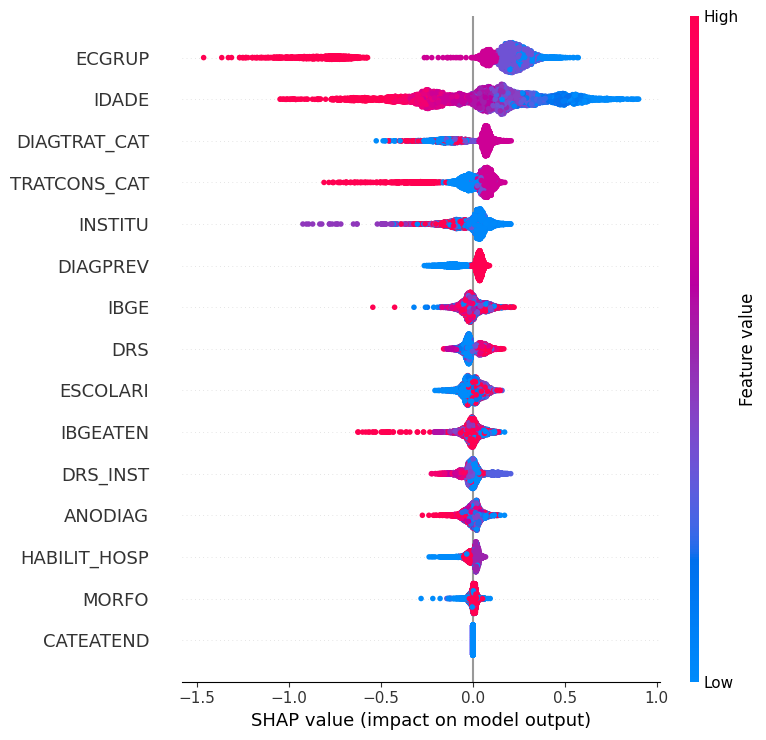

In [ ]:
# Create a SHAP TreeExplainer for the best model
explainer = shap.TreeExplainer(best)

# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test)

# Generate a summary plot to visualize the SHAP values for each feature
shap.summary_plot(shap_values, X_test, feature_names=feat_cols)

## **Machine Learning Survival - Gleason/PSA**

The training process was conducted with 'GLEASON' and 'PSA' features.

### Best Model Results - RSF and XGB-AFT on different metrics
- C-Index: XGB-AFT - 0,7492
- C-Index IPCW: RSF - 0,7160

### **Data preparation for survival models**

In [ ]:
# Reading Training Data
df_treino = pd.read_csv('prostata_treino.csv')  # Load the training data from the CSV file
print(df_treino.shape)  # Print the dimensions of the training DataFrame
df_treino.head(3).style.set_sticky(axis="columns") # Display the first 3 rows of the training DataFrame

(22703, 34)


,INSTITU,ESCOLARI,IDADE,CEP,IBGE,CATEATEND,DIAGPREV,TOPO,TOPOGRUP,MORFO,EC,ECGRUP,PSA,GLEASON,ANODIAG,DRS,RRAS,DSCINST,IBGEATEN,DRS_INST,RRAS_INST,CIDADE_INST,BAIRRO_RESID,BAIRRO_HOSP,HABILIT_HOSP,DISTANCIA_CARRO,ULTIDIAG,TRATCONS_CAT,DIAGTRAT_CAT,ivs_infraestrutura_urbana,ivs_capital_humano,ivs_renda_e_trabalho,meses_diag,OBITO_GERAL
0,20737,3,78,15790000,3544509.000000,2,2,C619,C61,85503,IIA,II,1,2,2017,15,RRAS 12,FUND PIO XII,3505500,5,RRAS 13,BARRETOS,nan,Centro,1,3,2591,3,3,0,0,1,87,0
1,208068,3,64,8693190,3552502.000000,2,2,C619,C61,81403,IIA,II,1,1,2014,1,RRAS 02,HOSP CLINICAS LUZIA PINHO MELO,3530607,1,RRAS 02,MOGI DAS CRUZES,Cidade Boa Vista,Vila Mogilar,0,1,1932,0,0,3,1,2,65,0
2,16624,2,65,4863600,3550308.000000,2,2,C619,C61,81403,IIA,II,1,2,2014,1,RRAS 06,IAVC,3550308,1,RRAS 06,SAO PAULO,Jardim Arco-Iris,Vila Buarque,1,2,3734,1,2,3,1,1,121,0


In [ ]:
# Reading Test Data
df_teste = pd.read_csv('prostata_teste.csv')  # Load the test data from the CSV file
print(df_teste.shape)  # Print the dimensions of the test DataFrame
df_teste.head(3).style.set_sticky(axis="columns")  # Display the first 3 rows of the test DataFrame

(5676, 34)


,INSTITU,ESCOLARI,IDADE,CEP,IBGE,CATEATEND,DIAGPREV,TOPO,TOPOGRUP,MORFO,EC,ECGRUP,PSA,GLEASON,ANODIAG,DRS,RRAS,DSCINST,IBGEATEN,DRS_INST,RRAS_INST,CIDADE_INST,BAIRRO_RESID,BAIRRO_HOSP,HABILIT_HOSP,DISTANCIA_CARRO,ULTIDIAG,TRATCONS_CAT,DIAGTRAT_CAT,ivs_infraestrutura_urbana,ivs_capital_humano,ivs_renda_e_trabalho,meses_diag,OBITO_GERAL
0,20737,2,55,15802125,3511102.000000,2,2,C619,C61,85503,IIB,II,1,2,2018,15,RRAS 12,FUND PIO XII,3505500,5,RRAS 13,BARRETOS,Parque Residencial Agudo Romão,Centro,1,3,2450,2,2,0,1,0,82,0
1,21130,3,64,14860000,3505609.000000,2,1,C619,C61,85503,I,I,1,1,2015,13,RRAS 13,HOSP CLINICAS DE RIBEIRAO PRETO,3543402,13,RRAS 13,RIBEIRAO PRETO,nan,Vila Monte Alegre,1,2,3383,2,2,3,2,1,113,0
2,21130,2,60,15970000,3546504.000000,2,2,C619,C61,85503,IIA,II,1,1,2016,3,RRAS 18,HOSP CLINICAS DE RIBEIRAO PRETO,3543402,13,RRAS 13,RIBEIRAO PRETO,nan,Vila Monte Alegre,1,3,2858,0,0,1,1,1,96,0


In [ ]:
# Y train and test for survival data (Death, Months from Diagnosis)
y_train = Surv.from_arrays(df_treino.OBITO_GERAL, df_treino.meses_diag)  # Create survival data for training set
y_test = Surv.from_arrays(df_teste.OBITO_GERAL, df_teste.meses_diag)  # Create survival data for test set

In [ ]:
# X train and test after removing unnecessary columns, including Death and Months from Diagnosis (which go to the target Y)
list_drop = ['CEP', 'TOPO', 'TOPOGRUP','EC', 'RRAS','DSCINST', 'RRAS_INST',
             'CIDADE_INST', 'BAIRRO_RESID', 'BAIRRO_HOSP','ULTIDIAG',
             'OBITO_GERAL', 'meses_diag','DISTANCIA_CARRO',
             'ivs_infraestrutura_urbana', 'ivs_capital_humano',
             'ivs_renda_e_trabalho']

X_train = df_treino.drop(list_drop, axis=1)  # Remove specified columns from the training dataset

X_test = df_teste.drop(list_drop, axis=1)  # Remove specified columns from the test dataset

In [ ]:
# Preprocessing of Training and Test data
X_train, X_test, feat_cols, enc, norm = preprocessing(X_train, X_test,
                                                      norm_name='StandardScaler',  # Specify normalization method
                                                      return_enc_norm=True,  # Return encoder and normalizer objects
                                                      random_state=seed)  # Set random state for reproducibility

# Display the shapes of the processed training and test datasets
X_train.shape, X_test.shape

((22703, 17), (5676, 17))

In [ ]:
# Features columns
feat_cols

Index(['INSTITU', 'ESCOLARI', 'IDADE', 'IBGE', 'CATEATEND', 'DIAGPREV',
       'MORFO', 'ECGRUP', 'PSA', 'GLEASON', 'ANODIAG', 'DRS', 'IBGEATEN',
       'DRS_INST', 'HABILIT_HOSP', 'TRATCONS_CAT', 'DIAGTRAT_CAT'],
      dtype='object')

### **Random Survival Forest**

#### **Base Model**

In [ ]:
# RSF (Random Survival Forest) Model
rsf = RandomSurvivalForest(max_depth=9, n_jobs=-1, random_state=seed)  # Initialize the RSF model with a max depth of 11
rsf.fit(X_train, y_train)  # Train the model using the training data

# Calculate the C-index for the test dataset
c_index_base = rsf.score(X_test, y_test)

# Print the C-index for both test and training datasets
print(f'C-Index Test: {c_index_base}')
print(f'C-Index Train: {rsf.score(X_train, y_train)}')

C-Index Test: 0.7486327839391903
C-Index Train: 0.7742000875698494


C-Index IPCW Teste: 0.7160063002548696
C-Index IPCW Treino: 0.7446714543975159

Integrated Brier Score (IBS): 0.13011599845516758

Brier Score:
    > 1 ano = 0.031419668951527445
    > 3 anos = 0.09465505423395972
    > 5 anos = 0.13895922883040557



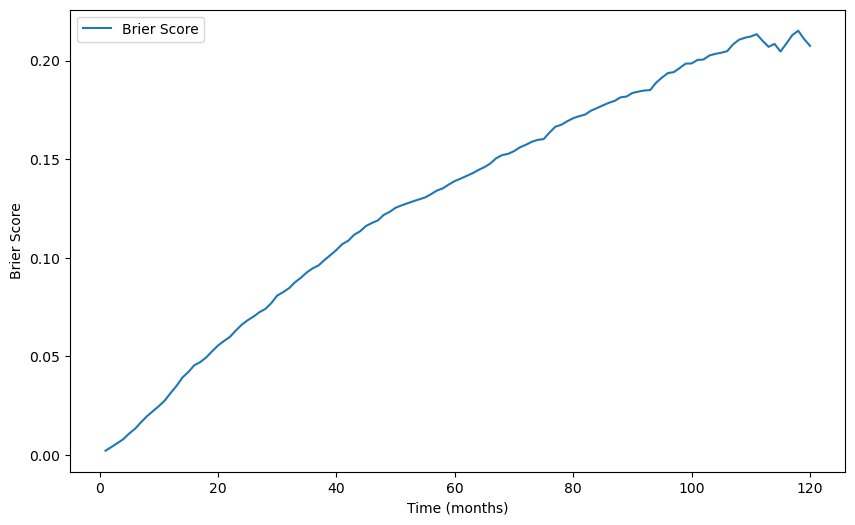

In [ ]:
# C-Index IPCW and Brier Score
c_index_ipcw_brier_score(rsf, X_train, y_train, X_test, y_test)  # Compute and evaluate the IPCW C-index and Brier Score

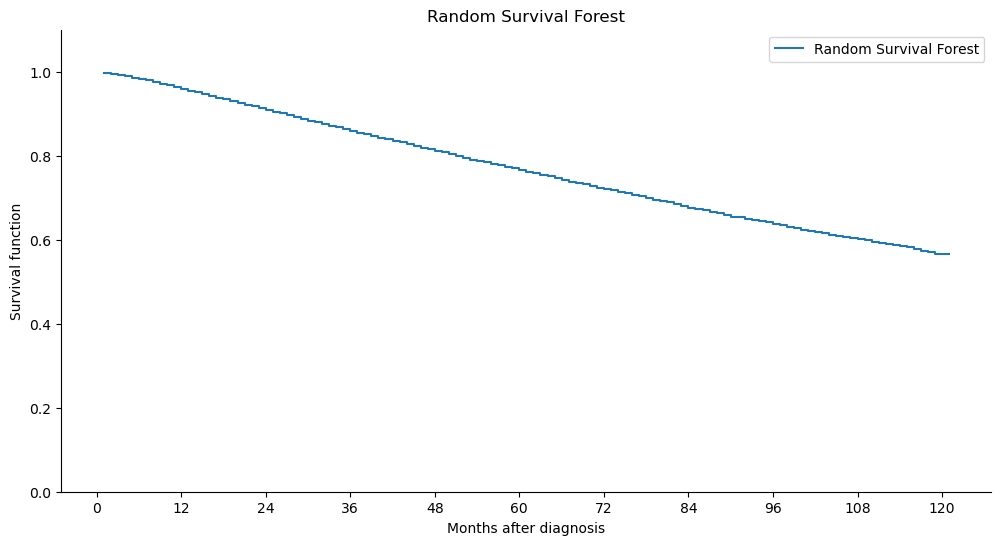

In [ ]:
# Survival prediction (Probability)
surv_rsf = rsf.predict_survival_function(X_test, return_array=True)  # Predict survival probabilities for the test set
surv_rsf_mean = surv_rsf.mean(axis=0)  # Compute the mean survival probability across samples

# Plot the predicted survival curve
name = 'Random Survival Forest'

plot_survival_curve(rsf.unique_times_, surv_rsf_mean, name=name)  # Generate and display the survival curve

In [ ]:
# Survival probability at 12, 36, 60, 84 and 120 months
print(f'12 months: {surv_rsf_mean[12]}')  # Print survival probability at 12 months
print(f'36 months: {surv_rsf_mean[36]}')  # Print survival probability at 36 months
print(f'60 months: {surv_rsf_mean[60]}')  # Print survival probability at 60 months
print(f'84 months: {surv_rsf_mean[84]}')  # Print survival probability at 84 months
print(f'120 months: {surv_rsf_mean[120]}')  # Print survival probability at 120 months

12 months: 0.955138723663889
36 months: 0.8550291483422641
60 months: 0.7616931504327422
84 months: 0.6733382490110509
120 months: 0.5652839951793239


#### **Optuna**

**Principais Hiperparâmetros para Otimização no RSF**

1. `n_estimators` (int)
* Descrição: Número de árvores na floresta. Mais árvores geralmente aumentam a precisão, mas podem tornar o treinamento mais lento.
* Sugestão de valores: 50 a 1000.

2. `max_depth` (int)
* Descrição: Profundidade máxima das árvores. Uma maior profundidade permite capturar padrões complexos, mas pode levar ao overfitting.
* Sugestão de valores: 3 a 30.

3. `min_samples_split` (int)
* Descrição: Número mínimo de amostras necessárias para dividir um nó. Controla o crescimento da árvore. Valores mais altos evitam o overfitting.
* Sugestão de valores: 2 a 20.

4. `min_samples_leaf` (int)
* Descrição: Número mínimo de amostras necessárias para formar uma folha. Valores maiores evitam folhas com muito poucas amostras, reduzindo o overfitting.
* Sugestão de valores: 1 a 50.

5. `max_features` (float, int, str)
* Descrição: Proporção ou número de recursos a serem considerados ao dividir um nó. Define a aleatoriedade do modelo, balanceando viés e variância.

    a) 'sqrt': Considera a raiz quadrada do total de features.

    b) 'log2': Considera o logaritmo base 2 do total de features.

    c) Valores numéricos: Pode ser um número específico ou uma proporção das features.

* Sugestão de valores: 'sqrt', 'log2', ou entre 0.1 e 1.0.

6. `bootstrap` (bool)
* Descrição: Se as amostras de treino são extraídas com ou sem reposição. Aumenta a diversidade entre as árvores, reduzindo o overfitting.
* Sugestão de valores: True ou False.

7. `oob_score` (bool)
* Descrição: Se o modelo deve calcular o erro fora da amostra (out-of-bag) durante o treinamento. Pode fornecer uma estimativa do desempenho sem a necessidade de um conjunto de validação separado.
* Sugestão de valores: True ou False.

8. `n_jobs` (int)
* Descrição: Número de processadores a serem usados em paralelo. Define a quantidade de processamento paralelo.
* Sugestão de valores: -1 (usa todos os processadores disponíveis).

9. `min_weight_fraction_leaf` (float)
* Descrição: Fração mínima do peso total das amostras que deve estar em cada folha. Previne folhas muito pequenas com base no peso das amostras.
* Sugestão de valores: 0.0 a 0.5.

In [ ]:
# Optuna number of trials
n_trials = 128

In [ ]:
# Folds for cross-validation
kf = KFold(n_splits=10, shuffle=True, random_state=seed)  # Create a 10-fold cross-validation strategy

# Function to compute the C-index for a given estimator
def c_index(estimator, X, y):
    cindex = estimator.score(X, y)  # Compute the C-index score
    return cindex

# Objective function for hyperparameter optimization
def objective(trial):
    # Define hyperparameters to be optimized
    n_estimators = trial.suggest_int('n_estimators', 50, 150)  # Number of trees in the forest
    max_depth = trial.suggest_int('max_depth', 5, 9)  # Maximum depth of each tree
    min_samples_split = trial.suggest_int('min_samples_split', 3, 12)  # Min samples required to split a node
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 3, 12)  # Min samples required at a leaf node
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.5, 0.75, 1.0])  # Feature selection strategy
    bootstrap = trial.suggest_categorical('bootstrap', [True, False])  # Whether to use bootstrap sampling

    # Create and train the model with the suggested hyperparameters
    rsf = RandomSurvivalForest(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        bootstrap=bootstrap,
        random_state=seed,
        n_jobs=-1
    )

    # Perform cross-validation and return the mean C-index score
    return cross_val_score(rsf, X_train, y_train, cv=kf, scoring=c_index).mean()

**RandomSampler**

In [ ]:
# # Otimização dos hiperparâmetros com Optuna - RandomSampler
# study = optuna.create_study(direction='maximize', sampler=RandomSampler(seed),
#                             study_name='RSF_RandomSampler')
# study.optimize(objective, n_trials=n_trials, n_jobs=-1)

In [ ]:
%%time
# Pickle filename to save the study
pickle_filename = 'prost_opt_rsf_rand.pkl'

# Load existing study or create a new one
if os.path.exists(pickle_filename):
    with open(pickle_filename, 'rb') as f:
        study = pickle.load(f)
else:
    study = optuna.create_study(direction='maximize', sampler=RandomSampler(seed=seed),
                                study_name='RSF_RandomSampler')

# Total number of desired trials
completed_trials = len(study.trials)

# Execute remaining trials in batches
while completed_trials < n_trials:
    study.optimize(objective, n_trials=64, n_jobs=-1)
    completed_trials = len(study.trials)
    print(f"\nTrials completed: {completed_trials}/{n_trials}")

    # Save the study after each batch
    with open(pickle_filename, 'wb') as f:
        pickle.dump(study, f)

[I 2026-06-12 14:09:31,055] A new study created in memory with name: RSF_RandomSampler
[I 2026-06-12 14:14:03,731] Trial 12 finished with value: 0.7401646137514978 and parameters: {'n_estimators': 52, 'max_depth': 7, 'min_samples_split': 8, 'min_samples_leaf': 3, 'max_features': 1.0, 'bootstrap': True}. Best is trial 12 with value: 0.7401646137514978.
[I 2026-06-12 14:14:03,996] Trial 43 finished with value: 0.7376368779454945 and parameters: {'n_estimators': 62, 'max_depth': 6, 'min_samples_split': 11, 'min_samples_leaf': 6, 'max_features': 0.75, 'bootstrap': False}. Best is trial 12 with value: 0.7401646137514978.
[I 2026-06-12 14:14:04,366] Trial 54 finished with value: 0.746621735627617 and parameters: {'n_estimators': 67, 'max_depth': 9, 'min_samples_split': 6, 'min_samples_leaf': 3, 'max_features': 'log2', 'bootstrap': False}. Best is trial 54 with value: 0.746621735627617.
[I 2026-06-12 14:14:04,666] Trial 8 finished with value: 0.7416061642541023 and parameters: {'n_estimators'


Trials completed: 64/128


[I 2026-06-12 14:18:34,257] Trial 73 finished with value: 0.7419271245553882 and parameters: {'n_estimators': 55, 'max_depth': 7, 'min_samples_split': 6, 'min_samples_leaf': 10, 'max_features': 0.5, 'bootstrap': False}. Best is trial 10 with value: 0.7472954119695389.
[I 2026-06-12 14:18:34,461] Trial 68 finished with value: 0.7433979095269035 and parameters: {'n_estimators': 54, 'max_depth': 7, 'min_samples_split': 12, 'min_samples_leaf': 12, 'max_features': 'log2', 'bootstrap': False}. Best is trial 10 with value: 0.7472954119695389.
[I 2026-06-12 14:18:34,825] Trial 121 finished with value: 0.7382478123039984 and parameters: {'n_estimators': 75, 'max_depth': 5, 'min_samples_split': 11, 'min_samples_leaf': 12, 'max_features': 'log2', 'bootstrap': True}. Best is trial 10 with value: 0.7472954119695389.
[I 2026-06-12 14:18:36,687] Trial 127 finished with value: 0.7376878167334161 and parameters: {'n_estimators': 54, 'max_depth': 6, 'min_samples_split': 5, 'min_samples_leaf': 11, 'max_f


Trials completed: 128/128
CPU times: user 4h 8min 47s, sys: 3min 23s, total: 4h 12min 10s
Wall time: 9min 12s


In [ ]:
# Display the best hyperparameters found by Optuna
print('Best parameters:', study.best_params)  # Print the best hyperparameters after optimization

Best parameters: {'n_estimators': 98, 'max_depth': 9, 'min_samples_split': 3, 'min_samples_leaf': 11, 'max_features': 'sqrt', 'bootstrap': True}


In [ ]:
# Training and metrics with the best hyperparameters
best_params = study.best_params  # Get the best parameters from the study
rsf_rand = RandomSurvivalForest(**best_params, random_state=seed)  # Initialize the RSF model with the best parameters
rsf_rand.fit(X_train, y_train)  # Train the model with the training data

# Compute the C-index for the test dataset
c_index_rand = rsf_rand.score(X_test, y_test)

# Print the C-index for both test and training datasets
print(f'C-Index Test: {c_index_rand}')
print(f'C-Index Train: {rsf_rand.score(X_train, y_train)}')

C-Index Test: 0.7479270178632638
C-Index Train: 0.7710164908265679


**TPESampler**

In [ ]:
# # Otimização dos hiperparâmetros com Optuna - TPESampler
# study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=seed),
#                             study_name='RSF_TPESampler')
# study.optimize(objective, n_trials=n_trials, n_jobs=-1)

In [ ]:
%%time
# Pickle filename to save the study
pickle_filename = 'prost_opt_rsf_tpe.pkl'

# Load existing study or create a new one
if os.path.exists(pickle_filename):
    with open(pickle_filename, 'rb') as f:
        study = pickle.load(f)
else:
    study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=seed),
                                study_name='RSF_TPESampler')

# Total number of desired trials
completed_trials = len(study.trials)

# Execute remaining trials in batches
while completed_trials < n_trials:
    study.optimize(objective, n_trials=64, n_jobs=-1)
    completed_trials = len(study.trials)
    print(f"\nTrials completed: {completed_trials}/{n_trials}")

    # Save the study after each batch
    with open(pickle_filename, 'wb') as f:
        pickle.dump(study, f)

[I 2026-06-12 14:19:05,800] A new study created in memory with name: RSF_TPESampler
[I 2026-06-12 14:23:26,013] Trial 44 finished with value: 0.741685445224246 and parameters: {'n_estimators': 55, 'max_depth': 8, 'min_samples_split': 4, 'min_samples_leaf': 10, 'max_features': 1.0, 'bootstrap': True}. Best is trial 44 with value: 0.741685445224246.
[I 2026-06-12 14:23:26,913] Trial 37 finished with value: 0.7456462519118958 and parameters: {'n_estimators': 52, 'max_depth': 8, 'min_samples_split': 8, 'min_samples_leaf': 5, 'max_features': 'log2', 'bootstrap': False}. Best is trial 37 with value: 0.7456462519118958.
[I 2026-06-12 14:23:26,957] Trial 61 finished with value: 0.7414158128930235 and parameters: {'n_estimators': 51, 'max_depth': 7, 'min_samples_split': 11, 'min_samples_leaf': 4, 'max_features': 0.75, 'bootstrap': True}. Best is trial 37 with value: 0.7456462519118958.
[I 2026-06-12 14:23:27,374] Trial 53 finished with value: 0.739256474700503 and parameters: {'n_estimators': 6


Trials completed: 64/128


[I 2026-06-12 14:28:44,755] Trial 90 finished with value: 0.7470298631896088 and parameters: {'n_estimators': 66, 'max_depth': 9, 'min_samples_split': 7, 'min_samples_leaf': 7, 'max_features': 'log2', 'bootstrap': True}. Best is trial 24 with value: 0.747071886942168.
[I 2026-06-12 14:28:48,334] Trial 85 finished with value: 0.7469630685746289 and parameters: {'n_estimators': 65, 'max_depth': 9, 'min_samples_split': 3, 'min_samples_leaf': 7, 'max_features': 'log2', 'bootstrap': True}. Best is trial 24 with value: 0.747071886942168.
[I 2026-06-12 14:28:48,494] Trial 70 finished with value: 0.7470298631896088 and parameters: {'n_estimators': 66, 'max_depth': 9, 'min_samples_split': 3, 'min_samples_leaf': 7, 'max_features': 'log2', 'bootstrap': True}. Best is trial 24 with value: 0.747071886942168.
[I 2026-06-12 14:28:48,590] Trial 81 finished with value: 0.7470298631896088 and parameters: {'n_estimators': 66, 'max_depth': 9, 'min_samples_split': 3, 'min_samples_leaf': 7, 'max_features': 


Trials completed: 128/128
CPU times: user 3h 22min, sys: 3min 45s, total: 3h 25min 45s
Wall time: 9min 45s


In [ ]:
# Display the best hyperparameters found by Optuna
print('Best parameters:', study.best_params)  # Print the best hyperparameters after optimization

Best parameters: {'n_estimators': 120, 'max_depth': 9, 'min_samples_split': 3, 'min_samples_leaf': 8, 'max_features': 'log2', 'bootstrap': True}


In [ ]:
# Training and metrics with the best hyperparameters
best_params = study.best_params  # Get the best parameters from the study
rsf_tpe = RandomSurvivalForest(**best_params, random_state=seed)  # Initialize the RSF model with the best parameters
rsf_tpe.fit(X_train, y_train)  # Train the model with the training data

# Compute the C-index for the test dataset
c_index_tpe = rsf_tpe.score(X_test, y_test)

# Print the C-index for both test and training datasets
print(f'C-Index Test: {c_index_tpe}')
print(f'C-Index Train: {rsf_tpe.score(X_train, y_train)}')

C-Index Test: 0.7472418621002364
C-Index Train: 0.7724917432568086


**CmaEsSampler**

In [ ]:
# # Otimização dos hiperparâmetros com Optuna - CmaEsSampler
# study = optuna.create_study(direction='maximize', sampler=CmaEsSampler(seed=seed),
#                             study_name='RSF_CmaEsSampler')
# study.optimize(objective, n_trials=n_trials, n_jobs=-1)

In [ ]:
%%time
# Pickle filename to save the study
pickle_filename = 'prost_opt_rsf_cma.pkl'

# Load existing study or create a new one
if os.path.exists(pickle_filename):
    with open(pickle_filename, 'rb') as f:
        study = pickle.load(f)
else:
    study = optuna.create_study(direction='maximize', sampler=CmaEsSampler(seed=seed),
                                study_name='RSF_CmaEsSampler')

# Total number of desired trials
completed_trials = len(study.trials)

# Execute remaining trials in batches
while completed_trials < n_trials:
    study.optimize(objective, n_trials=64, n_jobs=-1)
    completed_trials = len(study.trials)
    print(f"\nTrials completed: {completed_trials}/{n_trials}")

    # Save the study after each batch
    with open(pickle_filename, 'wb') as f:
        pickle.dump(study, f)

[I 2026-06-12 14:29:00,740] A new study created in memory with name: RSF_CmaEsSampler
[I 2026-06-12 14:33:31,759] Trial 2 finished with value: 0.7423898662758525 and parameters: {'n_estimators': 62, 'max_depth': 7, 'min_samples_split': 12, 'min_samples_leaf': 5, 'max_features': 0.5, 'bootstrap': False}. Best is trial 2 with value: 0.7423898662758525.
[I 2026-06-12 14:33:32,024] Trial 12 finished with value: 0.7468326770799313 and parameters: {'n_estimators': 52, 'max_depth': 9, 'min_samples_split': 4, 'min_samples_leaf': 8, 'max_features': 'log2', 'bootstrap': True}. Best is trial 12 with value: 0.7468326770799313.
[I 2026-06-12 14:33:32,033] Trial 53 finished with value: 0.7451925506323193 and parameters: {'n_estimators': 63, 'max_depth': 8, 'min_samples_split': 4, 'min_samples_leaf': 7, 'max_features': 'log2', 'bootstrap': True}. Best is trial 12 with value: 0.7468326770799313.
[I 2026-06-12 14:33:32,055] Trial 43 finished with value: 0.745035945943936 and parameters: {'n_estimators'


Trials completed: 64/128


[W 2026-06-12 14:33:35,000] The parameter 'max_features' in trial#75 is sampled independently by using `RandomSampler` instead of `CmaEsSampler` (optimization performance may be degraded). `CmaEsSampler` does not support dynamic search space or `CategoricalDistribution`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `CmaEsSampler`, if this independent sampling is intended behavior.
[W 2026-06-12 14:33:35,002] The parameter 'max_features' in trial#77 is sampled independently by using `RandomSampler` instead of `CmaEsSampler` (optimization performance may be degraded). `CmaEsSampler` does not support dynamic search space or `CategoricalDistribution`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `CmaEsSampler`, if this independent sampling is intended behavior.
[W 2026-06-12 14:33:35,003] The parameter 'max_features' in trial#74 is sampled independently by using `RandomSampler`


Trials completed: 128/128
CPU times: user 3h 59min 49s, sys: 3min 25s, total: 4h 3min 14s
Wall time: 8min 43s


In [ ]:
# Display the best hyperparameters found by Optuna
print('Best parameters:', study.best_params)  # Print the best hyperparameters after optimization

Best parameters: {'n_estimators': 92, 'max_depth': 9, 'min_samples_split': 8, 'min_samples_leaf': 8, 'max_features': 'log2', 'bootstrap': True}


In [ ]:
# Training and metrics with the best hyperparameters
best_params = study.best_params  # Get the best parameters from the study
rsf_cma = RandomSurvivalForest(**best_params, random_state=seed)  # Initialize the RSF model with the best parameters
rsf_cma.fit(X_train, y_train)  # Train the model with the training data

# Compute the C-index for the test dataset
c_index_cma = rsf_cma.score(X_test, y_test)

# Print the C-index for both test and training datasets
print(f'C-Index Test: {c_index_cma}')
print(f'C-index Train: {rsf_cma.score(X_train, y_train)}')

C-Index Test: 0.7468747164122821
C-index Train: 0.7726373598686916


#### **Best Random Survival Forest Model**

In [ ]:
# Best RSF model
scores = [c_index_base, c_index_rand, c_index_tpe, c_index_cma]  # List of C-index scores for different models
models = [rsf, rsf_rand, rsf_tpe, rsf_cma]  # List of the corresponding models

# Find the index of the model with the highest C-index score
id_best_score = scores.index(max(scores))
best = models[id_best_score]  # Select the model with the best score

# Print the best model
print(best)

RandomSurvivalForest(max_depth=9, n_jobs=-1, random_state=1)


C-Index Test: 0.7486327839391903
C-Index Train: 0.7742000875698494

C-Index IPCW Teste: 0.7160063002548696
C-Index IPCW Treino: 0.7446714543975159

Integrated Brier Score (IBS): 0.13011599845516758

Brier Score:
    > 1 ano = 0.031419668951527445
    > 3 anos = 0.09465505423395972
    > 5 anos = 0.13895922883040557



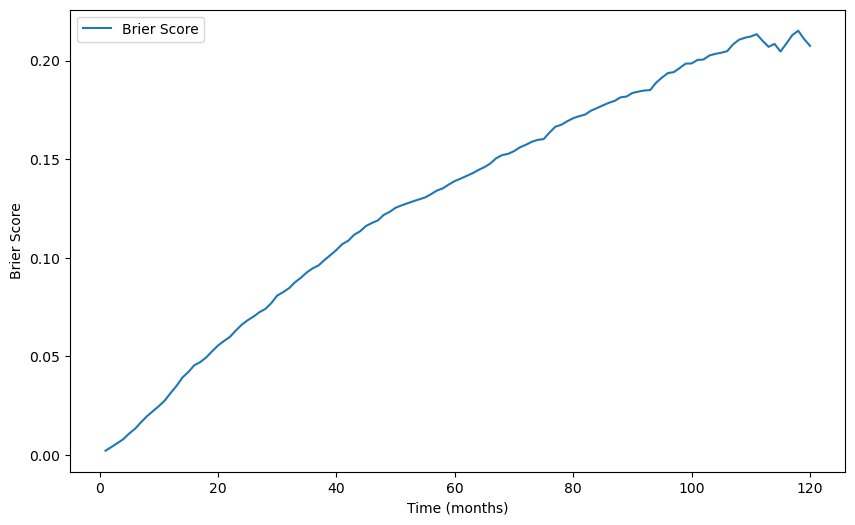

In [ ]:
# Metrics of the best RSF model
final_c_index = best.score(X_test, y_test)  # Compute the final C-index for the test dataset

# Print the C-index for both test and training datasets
print(f'C-Index Test: {final_c_index}')
print(f'C-Index Train: {best.score(X_train, y_train)}\n')

# Compute and display the IPCW C-index and Brier Score for the best model
c_index_ipcw_brier_score(best, X_train, y_train, X_test, y_test)

In [ ]:
# Best features by permutation importance
calculate_permutation_importance(best, X_test, y_test, feat_cols, random_state=seed)  # Calculate permutation importance of features for the best model

,importances_mean,importances_std
ECGRUP,0.067784,0.004792
IDADE,0.061352,0.003659
PSA,0.010512,0.001763
DIAGTRAT_CAT,0.009878,0.001726
INSTITU,0.008981,0.001082
GLEASON,0.007283,0.001234
TRATCONS_CAT,0.006410,0.000790
DRS_INST,0.002174,0.000752
IBGEATEN,0.002095,0.000427
MORFO,0.001890,0.000481


PermutationExplainer explainer: 5677it [1:24:22,  1.12it/s]                          


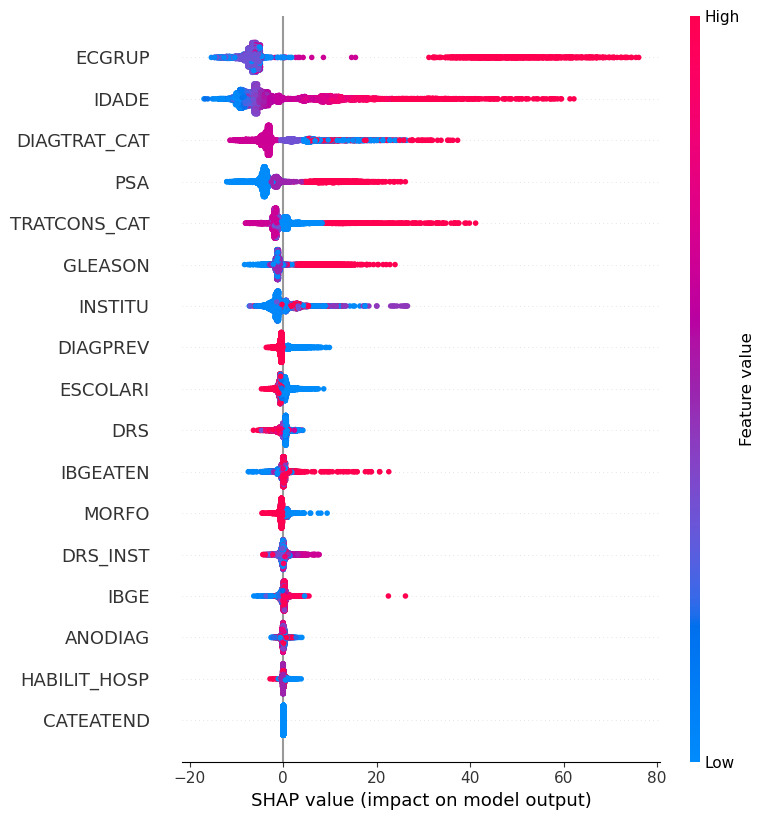

In [ ]:
# Best features by SHAP
explainer = shap.Explainer(best.predict, X_train, seed=seed,  # Create a SHAP explainer for the best model
                           output_names=feat_cols,  # Specify the feature names
                           n_jobs=-1)  # Use multiple jobs for parallel computation

shap_values = explainer(X_test)  # Calculate SHAP values for the test set

# Plot the SHAP summary plot to visualize feature importance
shap.summary_plot(shap_values, X_test, feature_names=feat_cols)

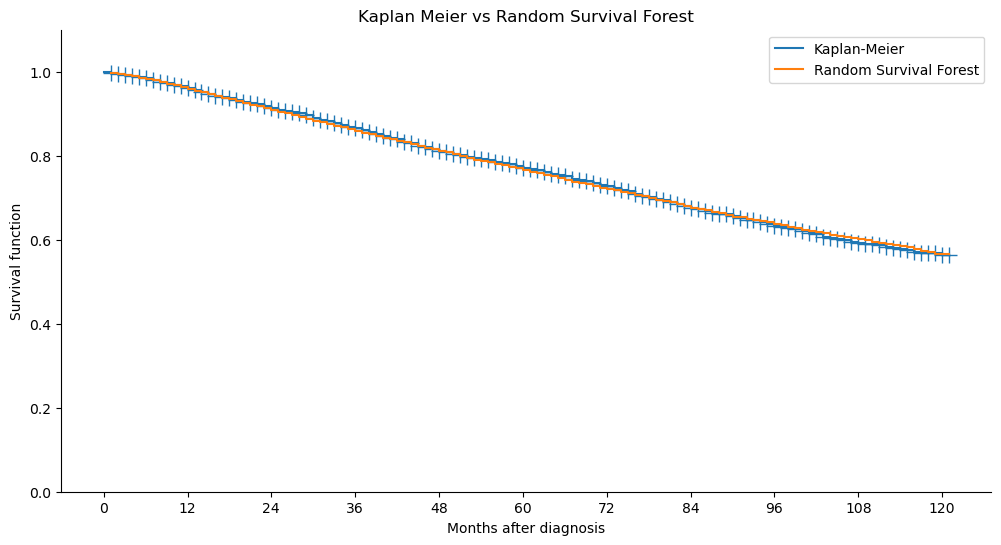

In [ ]:
# Comparison of survival curves
name = 'Random Survival Forest'  # Name of the model to be displayed on the plot

# Predict survival functions for the test set and compute the mean survival function
surv_rsf = best.predict_survival_function(X_test, return_array=True)
surv_rsf_mean = surv_rsf.mean(axis=0)  # Compute the mean survival function across all samples

# Plot the survival curve and compare with Kaplan-Meier (KM) estimates
plot_survival_curve(best.unique_times_, surv_rsf_mean,
                    name=name, compare_km=True, test_df=df_teste)  # Plot the survival curve and compare with the test dataset

### **XGBoost - AFT**

#### **Base Model**

In [ ]:
# Define weights (1.0 for events, 0.6 for censored cases)
weights = np.where(y_train['event'], 1.0, 0.6)

# The AFT model requires lower and upper bounds for survival time
label_lower_bound = y_train['time']
label_upper_bound = np.where(y_train['event'], y_train['time'], np.inf)

# Creating DMatrix for XGBoost (necessary to define bounds for AFT)
dtrain = xgb.DMatrix(X_train,
                     label_lower_bound=label_lower_bound,
                     label_upper_bound=label_upper_bound,
                     weight=weights)

dtest = xgb.DMatrix(X_test)

# Configuration of hyperparameters for the XGBoost Survival AFT model
params = {
    'objective': 'survival:aft',  # Use AFT to model survival analysis
    'eval_metric': 'aft-nloglik',  # Evaluation metric for AFT
    'aft_loss_distribution': 'normal',  # Failure time distribution ('normal', 'logistic', etc.)
    'aft_loss_distribution_scale': 1.0,  # Scale of the distribution (adjustable)
    'max_depth': 4,  # Maximum depth of trees
    'seed': seed,  # Seed for reproducibility
}

# Model training
xgb_aft = xgb.train(params, dtrain, num_boost_round=100)

# Predictions and C-Index calculation for the test set
y_pred = xgb_aft.predict(dtest)
c_index_base = concordance_index_censored(y_test['event'], y_test['time'], -y_pred)[0]

# Predictions and C-Index calculation for the training set
y_pred_train = xgb_aft.predict(dtrain)
c_index_train = concordance_index_censored(y_train['event'], y_train['time'], -y_pred_train)[0]

# Display C-Index results
print(f'C-index Test: {c_index_base}')
print(f'C-index Train: {c_index_train}')

C-index Test: 0.7454580120906521
C-index Train: 0.7883811584457918


In [ ]:
# C-Index IPCW (Inverse Probability of Censoring Weight)
surv_risks = xgb_aft.predict(dtest)  # Predict the survival risks for the test set
surv_risks_train = xgb_aft.predict(dtrain)  # Predict the survival risks for the training set

# Calculate the C-Index IPCW for Test and Train data
c_index_ipcw = concordance_index_ipcw(y_train, y_test, -surv_risks)  # Compute the C-Index IPCW for the test data
c_index_ipcw_train = concordance_index_ipcw(y_train, y_train, -surv_risks_train)  # Compute the C-Index IPCW for the training data

# Display C-Index IPCW for Test and Train data
print(f'C-Index IPCW Test: {c_index_ipcw[0]}')  # Print the C-Index IPCW for the test data
print(f'C-Index IPCW Train: {c_index_ipcw_train[0]}')  # Print the C-Index IPCW for the training data

C-Index IPCW Test: 0.7081641814544959
C-Index IPCW Train: 0.7513624000615363


#### **Optuna**

**Principais Parâmetros a Otimizar no XGBoost**

1. `n_estimators` (int):
* Número de árvores (boosting rounds) que o modelo vai treinar. Mais árvores podem melhorar o aprendizado, mas aumentam o risco de overfitting e o custo computacional.
* Sugestão de valores: 50 a 1000.

2. `learning_rate` (float):
* Taxa de aprendizado usada para diminuir a contribuição de cada árvore. Taxas menores exigem mais árvores, mas aumentam a estabilidade.
* Sugestão de valores: 0.01 a 0.3 (log-scale).

3. `max_depth` (int):
* Profundidade máxima das árvores individuais. Árvores mais profundas captam interações complexas, mas correm maior risco de overfitting.
* Sugestão de valores: 3 a 30.

4. `min_child_weight` (float):
* Peso mínimo da soma dos gradientes (hessian) em uma divisão de nó. Controla o tamanho mínimo de uma divisão, evitando overfitting.
* Sugestão de valores: 1 a 10.

5. `subsample` (float):
* Percentual de amostras utilizadas em cada árvore. Reduz overfitting ao amostrar dados de forma aleatória.
* Sugestão de valores: 0.5 a 1.0.

6. `colsample_bytree` (float):
* Percentual de colunas (features) usadas para cada árvore. Melhora a robustez e evita correlação entre as árvores.
* Sugestão de valores: 0.5 a 1.0.

7. `reg_alpha` (float):
* Regularização L1 (sparsidade). Incentiva a geração de árvores mais esparsas, evitando overfitting.
* Sugestão de valores: 1e-5 a 10 (log-scale).

8. `reg_lambda` (float):
* Regularização L2 (penalização quadrática). Controla a complexidade do modelo.
* Sugestão de valores: 1e-5 a 10 (log-scale).

9. `objective` (str):
* Função objetivo. Para sobrevivência, pode-se usar:

    'survival:cox': Regressão de Cox.
    
    'survival:aft': Modelo AFT (Accelerated Failure Time).

In [ ]:
# Optuna number o trials
n_trials = 128

In [ ]:
# Folds for Cross-Validation
kf = KFold(10, shuffle=True, random_state=seed)  # Create 10-fold cross-validation with shuffling

def objective(trial):
    # Define the hyperparameters to be optimized
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 150),  # Number of estimators (trees)
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.25, step=0.01),  # Learning rate
        'max_depth': trial.suggest_int('max_depth', 2, 5),  # Maximum depth of trees
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),  # Minimum weight of child nodes
        'subsample': trial.suggest_float('subsample', 0.5, 1.0, step=0.05),  # Fraction of data used for training
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0, step=0.05),  # Fraction of features used per tree
        'reg_alpha': trial.suggest_categorical('reg_alpha', [1e-4, 1e-3, 1e-2, 1e-1, 1, 10]),  # L1 regularization term
        'reg_lambda': trial.suggest_categorical('reg_lambda', [1e-4, 1e-3, 1e-2, 1e-1, 1, 10]),  # L2 regularization term
        'aft_loss_distribution': trial.suggest_categorical('aft_loss_distribution', ['normal', 'logistic', 'extreme']),  # AFT Distribution Type
        'aft_loss_distribution_scale': trial.suggest_float('aft_loss_distribution_scale', 0.5, 2.0, step=0.05),  # AFT distribution scale
        'objective': 'survival:aft',  # AFT loss function for survival analysis
        'eval_metric': 'aft-nloglik',  # Evaluation metric for AFT model
        'random_state': seed,  # Seed for reproducibility
        'n_jobs': -1,  # Use all available cores for training
    }

    fold_c_indices = []  # List to store the C-index values from each fold

    # Loop over the folds in cross-validation
    for train_idx, valid_idx in kf.split(X_train):
        try:
            # Split the data into training and validation sets for the current fold
            X_t, X_v = X_train[train_idx], X_train[valid_idx]  # Split features
            y_t, y_v = y_train[train_idx], y_train[valid_idx]  # Split labels

            # Defining the lower and upper limits for AFT (survival time)
            label_lower_bound = y_t['time']
            label_upper_bound = np.where(y_t['event'], y_t['time'], np.inf)

            # Create DMatrix for training and validation (DMatrix is an optimized data structure for XGBoost)
            dtrain = xgb.DMatrix(X_t, label_lower_bound=label_lower_bound,
                                 label_upper_bound=label_upper_bound,
                                 weight=np.where(y_t['event'], 1.0, 0.6))  # Set event weights

            dvalid = xgb.DMatrix(X_v)  # Validation DMatrix (no labels, predictions will be made)

            # Train the XGBoost model using the specified hyperparameters
            model = xgb.train(param, dtrain, num_boost_round=100, verbose_eval=False)  # Train model with 100 boosting rounds

            # Make predictions on the validation set
            pred_valid = model.predict(dvalid)

            # Calculate the Concordance Index (C-Index) for the validation fold
            c_index = concordance_index_censored(y_v['event'],
                                                 y_v['time'],
                                                 -pred_valid)[0]
            fold_c_indices.append(c_index)  # Append the C-Index for this fold to the list

        except (ValueError, xgb.core.XGBoostError) as e:
            continue  # Next Fold

    # Return the average C-Index
    return np.nanmean(fold_c_indices)  # The objective function returns the mean C-Index from the cross-validation folds

**RandomSampler**

In [ ]:
# Hyperparameter optimization with Optuna - RandomSampler
study = optuna.create_study(direction='maximize', sampler=RandomSampler(seed),  # Create a study to maximize the objective function
                            study_name='XGB_RandomSampler')  # Study name

study.optimize(objective, n_trials=n_trials, n_jobs=-1)  # Run the optimization with 'n_trials' trials in parallel

[I 2026-06-19 04:24:52,600] A new study created in memory with name: XGB_RandomSampler
[I 2026-06-19 04:25:05,488] Trial 1 finished with value: 0.7048974458356523 and parameters: {'n_estimators': 70, 'learning_rate': 0.03, 'max_depth': 2, 'min_child_weight': 6, 'subsample': 0.8, 'colsample_bytree': 0.75, 'reg_alpha': 0.001, 'reg_lambda': 0.0001, 'aft_loss_distribution': 'extreme', 'aft_loss_distribution_scale': 1.05}. Best is trial 1 with value: 0.7048974458356523.
[I 2026-06-19 04:25:06,878] Trial 0 finished with value: 0.7270872086072725 and parameters: {'n_estimators': 68, 'learning_rate': 0.02, 'max_depth': 4, 'min_child_weight': 5, 'subsample': 0.7, 'colsample_bytree': 0.75, 'reg_alpha': 0.0001, 'reg_lambda': 0.0001, 'aft_loss_distribution': 'extreme', 'aft_loss_distribution_scale': 1.0}. Best is trial 0 with value: 0.7270872086072725.
[I 2026-06-19 04:25:19,279] Trial 3 finished with value: 0.5867048886947065 and parameters: {'n_estimators': 148, 'learning_rate': 0.13, 'max_depth

In [ ]:
# Display the best hyperparameters found
print('Best parameters:', study.best_params)

Best parameters: {'n_estimators': 65, 'learning_rate': 0.22, 'max_depth': 4, 'min_child_weight': 9, 'subsample': 0.95, 'colsample_bytree': 0.65, 'reg_alpha': 0.1, 'reg_lambda': 0.001, 'aft_loss_distribution': 'normal', 'aft_loss_distribution_scale': 1.05}


In [ ]:
# Training and evaluation with the best hyperparameters
weights = np.where(y_train['event'], 1.0, 0.6)  # Assign higher weights to events (1.0 for event and 0.6 for non-event)

# The AFT model requires lower and upper bounds for survival time
label_lower_bound = y_train['time']
label_upper_bound = np.where(y_train['event'], y_train['time'], np.inf)

best_params = study.best_params  # Get the best parameters from the study
best_params.update({'objective': 'survival:aft',  # AFT loss function for survival analysis
                    'eval_metric': 'aft-nloglik',  # Evaluation metric for AFT model
                    'random_state': seed,  # Seed for reproducibility
                    'n_jobs': -1})  # Use all available cores for training

# Prepare the DMatrix objects for training and testing data
dtrain = xgb.DMatrix(X_train,
                     label_lower_bound=label_lower_bound,
                     label_upper_bound=label_upper_bound,
                     weight=weights)  # DMatrix for training with weights

dtest = xgb.DMatrix(X_test)  # DMatrix for testing without labels

# Train the XGBoost model with the best parameters
xgb_rand = xgb.train(best_params, dtrain, num_boost_round=100)

# Make predictions on the test and training datasets
y_pred = xgb_rand.predict(dtest)  # Predictions on the test data
y_pred_train = xgb_rand.predict(dtrain)  # Predictions on the training data

# Calculate the Concordance Index (C-Index) for test and training predictions
c_index_rand = concordance_index_censored(y_test['event'], y_test['time'], -y_pred)[0]  # C-Index for test
c_index_rand_train = concordance_index_censored(y_train['event'], y_train['time'], -y_pred_train)[0]  # C-Index for train

# Print the C-Index values
print(f'C-Index Test: {c_index_rand}')  # C-Index for the test set
print(f'C-Index Train: {c_index_rand_train}')  # C-Index for the training set

C-Index Test: 0.7496080514069791
C-Index Train: 0.7797730857443692


**TPESampler**

In [ ]:
# Hyperparameter optimization with Optuna - TPESampler
study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=seed),  # Create a study with TPE sampler for optimization
                            study_name='XGB_TPESampler')  # Study name for identification

study.optimize(objective, n_trials=n_trials, n_jobs=-1)  # Run optimization for 'n_trials' trials using parallel processing

[I 2026-06-19 05:27:10,787] A new study created in memory with name: XGB_TPESampler
[I 2026-06-19 05:27:21,651] Trial 1 finished with value: 0.7399474681178592 and parameters: {'n_estimators': 104, 'learning_rate': 0.05, 'max_depth': 2, 'min_child_weight': 10, 'subsample': 0.55, 'colsample_bytree': 0.8, 'reg_alpha': 0.0001, 'reg_lambda': 0.01, 'aft_loss_distribution': 'normal', 'aft_loss_distribution_scale': 1.8}. Best is trial 1 with value: 0.7399474681178592.
[I 2026-06-19 05:27:21,676] Trial 0 finished with value: 0.7451484149668343 and parameters: {'n_estimators': 150, 'learning_rate': 0.16, 'max_depth': 2, 'min_child_weight': 2, 'subsample': 0.7, 'colsample_bytree': 1.0, 'reg_alpha': 0.01, 'reg_lambda': 10, 'aft_loss_distribution': 'normal', 'aft_loss_distribution_scale': 1.8}. Best is trial 0 with value: 0.7451484149668343.
[I 2026-06-19 05:27:33,265] Trial 2 finished with value: 0.7417174220210289 and parameters: {'n_estimators': 115, 'learning_rate': 0.21000000000000002, 'max_d

In [ ]:
# Display the best hyperparameters found during optimization
print('Best parameters:', study.best_params)

Best parameters: {'n_estimators': 103, 'learning_rate': 0.09999999999999999, 'max_depth': 5, 'min_child_weight': 4, 'subsample': 0.75, 'colsample_bytree': 0.6, 'reg_alpha': 1, 'reg_lambda': 0.001, 'aft_loss_distribution': 'normal', 'aft_loss_distribution_scale': 1.35}


In [ ]:
# Training and evaluation with the best hyperparameters
weights = np.where(y_train['event'], 1.0, 0.6)  # Assign higher weights to events (1.0 for event and 0.6 for non-event)

# The AFT model requires lower and upper bounds for survival time
label_lower_bound = y_train['time']
label_upper_bound = np.where(y_train['event'], y_train['time'], np.inf)

best_params = study.best_params  # Get the best parameters from the study
best_params.update({'objective': 'survival:aft',  # AFT loss function for survival analysis
                    'eval_metric': 'aft-nloglik',  # Evaluation metric for AFT model
                    'random_state': seed,  # Seed for reproducibility
                    'n_jobs': -1})  # Use all available cores for training

# Prepare the DMatrix objects for training and testing data
dtrain = xgb.DMatrix(X_train,
                     label_lower_bound=label_lower_bound,
                     label_upper_bound=label_upper_bound,
                     weight=weights)  # DMatrix for training with weights

dtest = xgb.DMatrix(X_test)  # DMatrix for testing without labels

# Train the XGBoost model with the best parameters
xgb_tpe = xgb.train(best_params, dtrain, num_boost_round=100)

# Make predictions on the test and training datasets
y_pred = xgb_tpe.predict(dtest)  # Predictions on the test data
y_pred_train = xgb_tpe.predict(dtrain)  # Predictions on the training data

# Calculate the Concordance Index (C-Index) for test and training predictions
c_index_tpe = concordance_index_censored(y_test['event'], y_test['time'], -y_pred)[0]  # C-Index for test
c_index_tpe_train = concordance_index_censored(y_train['event'], y_train['time'], -y_pred_train)[0]  # C-Index for train

# Print the C-Index values
print(f'C-Index Test: {c_index_tpe}')  # C-Index for the test set
print(f'C-Index Train: {c_index_tpe_train}')  # C-Index for the training set

C-Index Test: 0.7506605095903782
C-Index Train: 0.778277918222912


**CmaEsSampler**

In [ ]:
# Hyperparameter optimization with Optuna - CmaEsSampler
study = optuna.create_study(direction='maximize', sampler=CmaEsSampler(seed=seed),  # Create a study with CMA-ES sampler for optimization
                            study_name='XGB_CmaEsSampler')  # Study name for identification

study.optimize(objective, n_trials=n_trials, n_jobs=-1)  # Run optimization for 'n_trials' trials using parallel processing

[I 2026-06-19 05:39:28,156] A new study created in memory with name: XGB_CmaEsSampler
[I 2026-06-19 05:39:41,039] Trial 0 finished with value: 0.7467899295210964 and parameters: {'n_estimators': 79, 'learning_rate': 0.21000000000000002, 'max_depth': 3, 'min_child_weight': 6, 'subsample': 0.75, 'colsample_bytree': 0.9, 'reg_alpha': 0.1, 'reg_lambda': 1, 'aft_loss_distribution': 'extreme', 'aft_loss_distribution_scale': 1.4500000000000002}. Best is trial 0 with value: 0.7467899295210964.
[W 2026-06-19 05:39:41,049] The parameter `reg_alpha` in Trial#2 is sampled independently using `RandomSampler` instead of `CmaEsSampler`, potentially degrading the optimization performance. This fallback happened because dynamic search space and `CategoricalDistribution` are not supported by `CmaEsSampler`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `CmaEsSampler` if this independent sampling is intended behavior.
[W 2026-06-19 05:39:41,053] The

In [ ]:
# Display the best hyperparameters found during optimization
print('Best parameters:', study.best_params)

Best parameters: {'n_estimators': 115, 'learning_rate': 0.14, 'max_depth': 4, 'min_child_weight': 6, 'subsample': 0.8500000000000001, 'colsample_bytree': 0.8, 'reg_alpha': 1, 'reg_lambda': 0.01, 'aft_loss_distribution': 'normal', 'aft_loss_distribution_scale': 1.15}


In [ ]:
# Training and evaluation with the best hyperparameters
weights = np.where(y_train['event'], 1.0, 0.6)  # Assign higher weights to events (1.0 for event and 0.6 for non-event)

# The AFT model requires lower and upper bounds for survival time
label_lower_bound = y_train['time']
label_upper_bound = np.where(y_train['event'], y_train['time'], np.inf)

best_params = study.best_params  # Get the best parameters from the study
best_params.update({'objective': 'survival:aft',  # AFT loss function for survival analysis
                    'eval_metric': 'aft-nloglik',  # Evaluation metric for AFT model
                    'random_state': seed,  # Seed for reproducibility
                    'n_jobs': -1})  # Use all available cores for training

# Prepare the DMatrix objects for training and testing data
dtrain = xgb.DMatrix(X_train,
                     label_lower_bound=label_lower_bound,
                     label_upper_bound=label_upper_bound,
                     weight=weights)  # DMatrix for training with weights

dtest = xgb.DMatrix(X_test)  # DMatrix for testing without labels

# Train the XGBoost model with the best parameters
xgb_cma = xgb.train(best_params, dtrain, num_boost_round=100)

# Make predictions on the test and training datasets
y_pred = xgb_cma.predict(dtest)  # Predictions on the test data
y_pred_train = xgb_cma.predict(dtrain)  # Predictions on the training data

# Calculate the Concordance Index (C-Index) for test and training predictions
c_index_cma = concordance_index_censored(y_test['event'], y_test['time'], -y_pred)[0]  # C-Index for test
c_index_cma_train = concordance_index_censored(y_train['event'], y_train['time'], -y_pred_train)[0]  # C-Index for train

# Print the C-Index values
print(f'C-Index Test: {c_index_cma}')  # C-Index for the test set
print(f'C-Index Train: {c_index_cma_train}')  # C-Index for the training set

C-Index Test: 0.7500045060570026
C-Index Train: 0.7721885804790141


#### **Best XGBoost Model**

In [ ]:
# Best XGBoost model
scores = [c_index_base, c_index_rand, c_index_tpe, c_index_cma]  # List of C-index scores for each model
models = [xgb_aft, xgb_rand, xgb_tpe, xgb_cma]  # List of the trained models

# Find the model with the highest C-index
id_best_score = scores.index(max(scores))  # Get the index of the model with the best score
best = models[id_best_score]  # Select the best model based on the highest C-index

print(best)  # Display the best model

In [ ]:
# Make predictions on the validation and training sets
y_pred = best.predict(dtest)  # Predictions on the test set
y_pred_train = best.predict(dtrain)  # Predictions on the training set

# Calculate the C-Index for the test and training sets
final_c_index = concordance_index_censored(y_test['event'], y_test['time'], -y_pred)[0]  # C-Index for the test set
final_c_index_train = concordance_index_censored(y_train['event'], y_train['time'], -y_pred_train)[0]  # C-Index for the training set

print('C-Index')  # Print label for C-Index
print(f'> Test: {final_c_index}')  # Print C-Index for the test set
print(f'> Train: {final_c_index_train}')  # Print C-Index for the training set

c_index_ipcw = concordance_index_ipcw(y_train, y_test, -y_pred)  # C-Index IPCW for the test set
c_index_ipcw_train = concordance_index_ipcw(y_train, y_train, -y_pred_train)  # C-Index IPCW for the training set

print('\nC-Index IPCW')  # Print label for C-Index IPCW
print(f'> Test: {c_index_ipcw[0]}')  # Print IPCW C-Index for the test set
print(f'> Train: {c_index_ipcw_train[0]}')  # Print IPCW C-Index for the training set

C-Index
> Test: 0.7506605095903782
> Train: 0.778277918222912

C-Index IPCW
> Test: 0.7156325675534111
> Train: 0.7440543010378146


In [ ]:
# Best features by permutation importance
calculate_permutation_importance_xgb(best, X_test, y_test, feat_cols, random_state=seed)  # Calculate permutation importance of features for the best model

,importances_mean,importances_std
CATEATEND,0.000000,0.000000
HABILIT_HOSP,-0.000577,0.000311
DRS,-0.001132,0.000301
DIAGPREV,-0.001190,0.000668
ANODIAG,-0.001305,0.000483
MORFO,-0.001417,0.000489
IBGE,-0.001527,0.000869
ESCOLARI,-0.001937,0.000567
DRS_INST,-0.002945,0.000453
IBGEATEN,-0.003316,0.000628


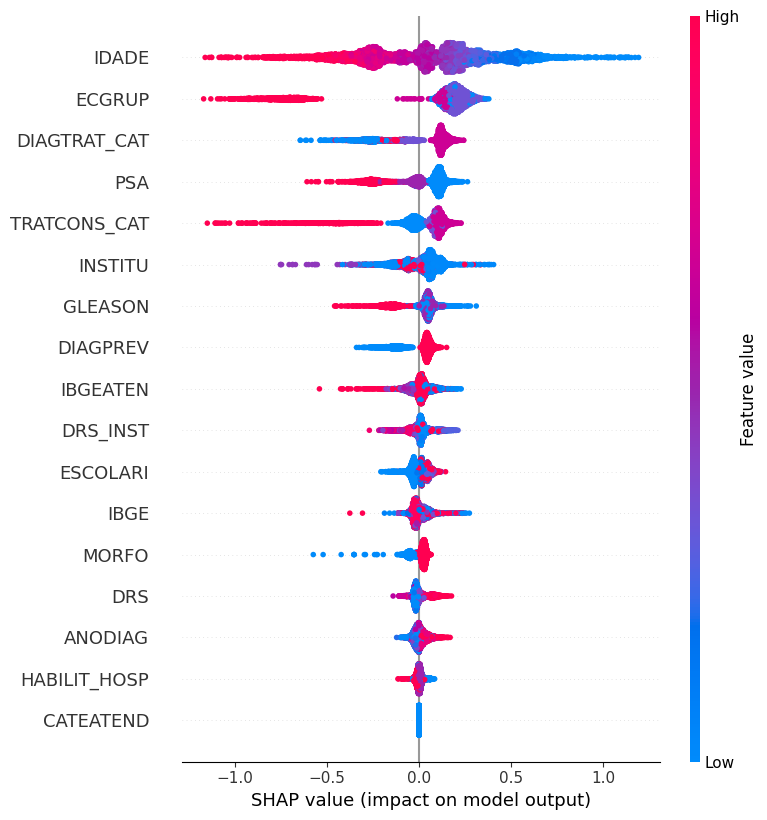

In [ ]:
# Create a SHAP TreeExplainer for the best model
explainer = shap.TreeExplainer(best)

# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test)

# Generate a summary plot to visualize the SHAP values for each feature
shap.summary_plot(shap_values, X_test, feature_names=feat_cols)

## **Machine Learning Survival - Gleason**

The training process was conducted with 'GLEASON' variable, along with other variables in the database.

### Best Model Results - RSF and XGB-AFT on different metrics
- C-Index: XGB-AFT - 0,7475
- C-Index IPCW: RSF - 0,7161

### **Data preparation for survival models**

In [ ]:
# Reading Training Data
df_treino = pd.read_csv('prostata_treino.csv')  # Load the training data from the CSV file
print(df_treino.shape)  # Print the dimensions of the training DataFrame
df_treino.head(3).style.set_sticky(axis="columns") # Display the first 3 rows of the training DataFrame

(22703, 34)


,INSTITU,ESCOLARI,IDADE,CEP,IBGE,CATEATEND,DIAGPREV,TOPO,TOPOGRUP,MORFO,EC,ECGRUP,PSA,GLEASON,ANODIAG,DRS,RRAS,DSCINST,IBGEATEN,DRS_INST,RRAS_INST,CIDADE_INST,BAIRRO_RESID,BAIRRO_HOSP,HABILIT_HOSP,DISTANCIA_CARRO,ULTIDIAG,TRATCONS_CAT,DIAGTRAT_CAT,ivs_infraestrutura_urbana,ivs_capital_humano,ivs_renda_e_trabalho,meses_diag,OBITO_GERAL
0,20737,3,78,15790000,3544509.000000,2,2,C619,C61,85503,IIA,II,1,2,2017,15,RRAS 12,FUND PIO XII,3505500,5,RRAS 13,BARRETOS,nan,Centro,1,3,2591,3,3,0,0,1,87,0
1,208068,3,64,8693190,3552502.000000,2,2,C619,C61,81403,IIA,II,1,1,2014,1,RRAS 02,HOSP CLINICAS LUZIA PINHO MELO,3530607,1,RRAS 02,MOGI DAS CRUZES,Cidade Boa Vista,Vila Mogilar,0,1,1932,0,0,3,1,2,65,0
2,16624,2,65,4863600,3550308.000000,2,2,C619,C61,81403,IIA,II,1,2,2014,1,RRAS 06,IAVC,3550308,1,RRAS 06,SAO PAULO,Jardim Arco-Iris,Vila Buarque,1,2,3734,1,2,3,1,1,121,0


In [ ]:
# Reading Test Data
df_teste = pd.read_csv('prostata_teste.csv')  # Load the test data from the CSV file
print(df_teste.shape)  # Print the dimensions of the test DataFrame
df_teste.head(3).style.set_sticky(axis="columns")  # Display the first 3 rows of the test DataFrame

(5676, 34)


,INSTITU,ESCOLARI,IDADE,CEP,IBGE,CATEATEND,DIAGPREV,TOPO,TOPOGRUP,MORFO,EC,ECGRUP,PSA,GLEASON,ANODIAG,DRS,RRAS,DSCINST,IBGEATEN,DRS_INST,RRAS_INST,CIDADE_INST,BAIRRO_RESID,BAIRRO_HOSP,HABILIT_HOSP,DISTANCIA_CARRO,ULTIDIAG,TRATCONS_CAT,DIAGTRAT_CAT,ivs_infraestrutura_urbana,ivs_capital_humano,ivs_renda_e_trabalho,meses_diag,OBITO_GERAL
0,20737,2,55,15802125,3511102.000000,2,2,C619,C61,85503,IIB,II,1,2,2018,15,RRAS 12,FUND PIO XII,3505500,5,RRAS 13,BARRETOS,Parque Residencial Agudo Romão,Centro,1,3,2450,2,2,0,1,0,82,0
1,21130,3,64,14860000,3505609.000000,2,1,C619,C61,85503,I,I,1,1,2015,13,RRAS 13,HOSP CLINICAS DE RIBEIRAO PRETO,3543402,13,RRAS 13,RIBEIRAO PRETO,nan,Vila Monte Alegre,1,2,3383,2,2,3,2,1,113,0
2,21130,2,60,15970000,3546504.000000,2,2,C619,C61,85503,IIA,II,1,1,2016,3,RRAS 18,HOSP CLINICAS DE RIBEIRAO PRETO,3543402,13,RRAS 13,RIBEIRAO PRETO,nan,Vila Monte Alegre,1,3,2858,0,0,1,1,1,96,0


In [ ]:
# Y train and test for survival data (Death, Months from Diagnosis)
y_train = Surv.from_arrays(df_treino.OBITO_GERAL, df_treino.meses_diag)  # Create survival data for training set
y_test = Surv.from_arrays(df_teste.OBITO_GERAL, df_teste.meses_diag)  # Create survival data for test set

In [ ]:
# X train and test after removing unnecessary columns, including Death and Months from Diagnosis (which go to the target Y)
list_drop = ['CEP', 'TOPO', 'TOPOGRUP','EC', 'RRAS','DSCINST', 'RRAS_INST',
             'CIDADE_INST', 'BAIRRO_RESID', 'BAIRRO_HOSP','ULTIDIAG',
             'OBITO_GERAL', 'meses_diag','PSA','DISTANCIA_CARRO',
             'ivs_infraestrutura_urbana', 'ivs_capital_humano',
             'ivs_renda_e_trabalho']

X_train = df_treino.drop(list_drop, axis=1)  # Remove specified columns from the training dataset

X_test = df_teste.drop(list_drop, axis=1)  # Remove specified columns from the test dataset

In [ ]:
# Preprocessing of Training and Test data
X_train, X_test, feat_cols, enc, norm = preprocessing(X_train, X_test,
                                                      norm_name='StandardScaler',  # Specify normalization method
                                                      return_enc_norm=True,  # Return encoder and normalizer objects
                                                      random_state=seed)  # Set random state for reproducibility

# Display the shapes of the processed training and test datasets
X_train.shape, X_test.shape

((22703, 16), (5676, 16))

In [ ]:
# Features columns
feat_cols

Index(['INSTITU', 'ESCOLARI', 'IDADE', 'IBGE', 'CATEATEND', 'DIAGPREV',
       'MORFO', 'ECGRUP', 'GLEASON', 'ANODIAG', 'DRS', 'IBGEATEN', 'DRS_INST',
       'HABILIT_HOSP', 'TRATCONS_CAT', 'DIAGTRAT_CAT'],
      dtype='object')

### **Random Survival Forest**

#### **Base Model**

In [ ]:
# RSF (Random Survival Forest) Model
rsf = RandomSurvivalForest(max_depth=9, n_jobs=-1, random_state=seed)  # Initialize the RSF model with a max depth of 11
rsf.fit(X_train, y_train)  # Train the model using the training data

# Calculate the C-index for the test dataset
c_index_base = rsf.score(X_test, y_test)

# Print the C-index for both test and training datasets
print(f'C-Index Test: {c_index_base}')
print(f'C-Index Train: {rsf.score(X_train, y_train)}')

C-Index Test: 0.7466670459591169
C-Index Train: 0.7705959728282689


C-Index IPCW Teste: 0.7152676080526195
C-Index IPCW Treino: 0.7416381638483042

Integrated Brier Score (IBS): 0.13097242152761931

Brier Score:
    > 1 ano = 0.03140434792052933
    > 3 anos = 0.09537440704642304
    > 5 anos = 0.13999915693242418



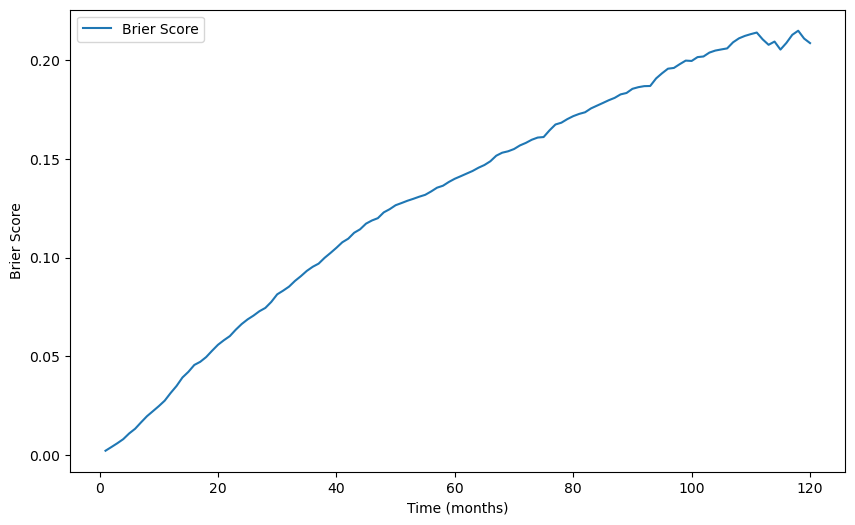

In [ ]:
# C-Index IPCW and Brier Score
c_index_ipcw_brier_score(rsf, X_train, y_train, X_test, y_test)  # Compute and evaluate the IPCW C-index and Brier Score

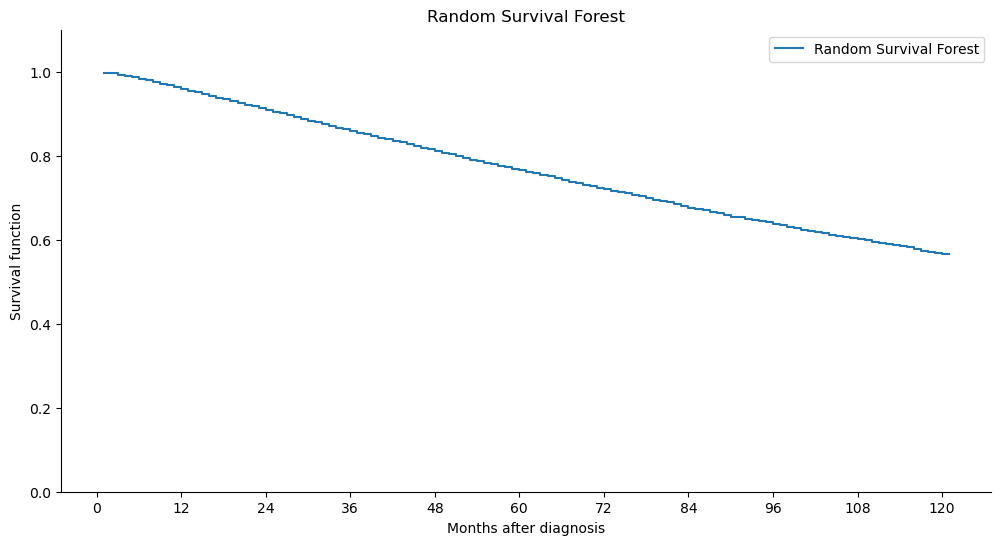

In [ ]:
# Survival prediction (Probability)
surv_rsf = rsf.predict_survival_function(X_test, return_array=True)  # Predict survival probabilities for the test set
surv_rsf_mean = surv_rsf.mean(axis=0)  # Compute the mean survival probability across samples

# Plot the predicted survival curve
name = 'Random Survival Forest'

plot_survival_curve(rsf.unique_times_, surv_rsf_mean, name=name)  # Generate and display the survival curve

In [ ]:
# Survival probability at 12, 36, 60, 84 and 120 months
print(f'12 months: {surv_rsf_mean[12]}')  # Print survival probability at 12 months
print(f'36 months: {surv_rsf_mean[36]}')  # Print survival probability at 36 months
print(f'60 months: {surv_rsf_mean[60]}')  # Print survival probability at 60 months
print(f'84 months: {surv_rsf_mean[84]}')  # Print survival probability at 84 months
print(f'120 months: {surv_rsf_mean[120]}')  # Print survival probability at 120 months

12 months: 0.9551990690304275
36 months: 0.8548742575285746
60 months: 0.7614274050208534
84 months: 0.6731033232375935
120 months: 0.5655588676051223


#### **Optuna**

**Principais Hiperparâmetros para Otimização no RSF**

1. `n_estimators` (int)
* Descrição: Número de árvores na floresta. Mais árvores geralmente aumentam a precisão, mas podem tornar o treinamento mais lento.
* Sugestão de valores: 50 a 1000.

2. `max_depth` (int)
* Descrição: Profundidade máxima das árvores. Uma maior profundidade permite capturar padrões complexos, mas pode levar ao overfitting.
* Sugestão de valores: 3 a 30.

3. `min_samples_split` (int)
* Descrição: Número mínimo de amostras necessárias para dividir um nó. Controla o crescimento da árvore. Valores mais altos evitam o overfitting.
* Sugestão de valores: 2 a 20.

4. `min_samples_leaf` (int)
* Descrição: Número mínimo de amostras necessárias para formar uma folha. Valores maiores evitam folhas com muito poucas amostras, reduzindo o overfitting.
* Sugestão de valores: 1 a 50.

5. `max_features` (float, int, str)
* Descrição: Proporção ou número de recursos a serem considerados ao dividir um nó. Define a aleatoriedade do modelo, balanceando viés e variância.

    a) 'sqrt': Considera a raiz quadrada do total de features.

    b) 'log2': Considera o logaritmo base 2 do total de features.

    c) Valores numéricos: Pode ser um número específico ou uma proporção das features.

* Sugestão de valores: 'sqrt', 'log2', ou entre 0.1 e 1.0.

6. `bootstrap` (bool)
* Descrição: Se as amostras de treino são extraídas com ou sem reposição. Aumenta a diversidade entre as árvores, reduzindo o overfitting.
* Sugestão de valores: True ou False.

7. `oob_score` (bool)
* Descrição: Se o modelo deve calcular o erro fora da amostra (out-of-bag) durante o treinamento. Pode fornecer uma estimativa do desempenho sem a necessidade de um conjunto de validação separado.
* Sugestão de valores: True ou False.

8. `n_jobs` (int)
* Descrição: Número de processadores a serem usados em paralelo. Define a quantidade de processamento paralelo.
* Sugestão de valores: -1 (usa todos os processadores disponíveis).

9. `min_weight_fraction_leaf` (float)
* Descrição: Fração mínima do peso total das amostras que deve estar em cada folha. Previne folhas muito pequenas com base no peso das amostras.
* Sugestão de valores: 0.0 a 0.5.

In [ ]:
# Optuna number of trials
n_trials = 128

In [ ]:
# Folds for cross-validation
kf = KFold(n_splits=10, shuffle=True, random_state=seed)  # Create a 10-fold cross-validation strategy

# Function to compute the C-index for a given estimator
def c_index(estimator, X, y):
    cindex = estimator.score(X, y)  # Compute the C-index score
    return cindex

# Objective function for hyperparameter optimization
def objective(trial):
    # Define hyperparameters to be optimized
    n_estimators = trial.suggest_int('n_estimators', 50, 150)  # Number of trees in the forest
    max_depth = trial.suggest_int('max_depth', 5, 9)  # Maximum depth of each tree
    min_samples_split = trial.suggest_int('min_samples_split', 3, 12)  # Min samples required to split a node
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 3, 12)  # Min samples required at a leaf node
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.5, 0.75, 1.0])  # Feature selection strategy
    bootstrap = trial.suggest_categorical('bootstrap', [True, False])  # Whether to use bootstrap sampling

    # Create and train the model with the suggested hyperparameters
    rsf = RandomSurvivalForest(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        bootstrap=bootstrap,
        random_state=seed,
        n_jobs=-1
    )

    # Perform cross-validation and return the mean C-index score
    return cross_val_score(rsf, X_train, y_train, cv=kf, scoring=c_index).mean()

**RandomSampler**

In [ ]:
# # Otimização dos hiperparâmetros com Optuna - RandomSampler
# study = optuna.create_study(direction='maximize', sampler=RandomSampler(seed),
#                             study_name='RSF_RandomSampler')
# study.optimize(objective, n_trials=n_trials, n_jobs=-1)

In [ ]:
%%time
# Pickle filename to save the study
pickle_filename = 'prost_opt_rsf_rand.pkl'

# Load existing study or create a new one
if os.path.exists(pickle_filename):
    with open(pickle_filename, 'rb') as f:
        study = pickle.load(f)
else:
    study = optuna.create_study(direction='maximize', sampler=RandomSampler(seed=seed),
                                study_name='RSF_RandomSampler')

# Total number of desired trials
completed_trials = len(study.trials)

# Execute remaining trials in batches
while completed_trials < n_trials:
    study.optimize(objective, n_trials=64, n_jobs=-1)
    completed_trials = len(study.trials)
    print(f"\nTrials completed: {completed_trials}/{n_trials}")

    # Save the study after each batch
    with open(pickle_filename, 'wb') as f:
        pickle.dump(study, f)

[I 2026-06-12 16:14:30,950] A new study created in memory with name: RSF_RandomSampler
[I 2026-06-12 16:18:14,010] Trial 30 finished with value: 0.7416665329010746 and parameters: {'n_estimators': 53, 'max_depth': 8, 'min_samples_split': 10, 'min_samples_leaf': 11, 'max_features': 0.5, 'bootstrap': False}. Best is trial 30 with value: 0.7416665329010746.
[I 2026-06-12 16:18:14,017] Trial 58 finished with value: 0.7428334228494513 and parameters: {'n_estimators': 54, 'max_depth': 8, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 58 with value: 0.7428334228494513.
[I 2026-06-12 16:18:14,334] Trial 45 finished with value: 0.741793513167234 and parameters: {'n_estimators': 50, 'max_depth': 7, 'min_samples_split': 5, 'min_samples_leaf': 7, 'max_features': 'log2', 'bootstrap': True}. Best is trial 58 with value: 0.7428334228494513.
[I 2026-06-12 16:18:14,408] Trial 28 finished with value: 0.7370917990284418 and parameters: {'n_estimat


Trials completed: 64/128


[I 2026-06-12 16:21:56,721] Trial 87 finished with value: 0.7434007256070373 and parameters: {'n_estimators': 57, 'max_depth': 8, 'min_samples_split': 9, 'min_samples_leaf': 8, 'max_features': 'log2', 'bootstrap': False}. Best is trial 13 with value: 0.745025997235701.
[I 2026-06-12 16:21:57,359] Trial 113 finished with value: 0.7427037264249639 and parameters: {'n_estimators': 61, 'max_depth': 9, 'min_samples_split': 9, 'min_samples_leaf': 10, 'max_features': 0.5, 'bootstrap': True}. Best is trial 13 with value: 0.745025997235701.
[I 2026-06-12 16:21:57,460] Trial 122 finished with value: 0.7388568821176464 and parameters: {'n_estimators': 62, 'max_depth': 6, 'min_samples_split': 7, 'min_samples_leaf': 11, 'max_features': 0.5, 'bootstrap': False}. Best is trial 13 with value: 0.745025997235701.
[I 2026-06-12 16:21:57,469] Trial 96 finished with value: 0.7427992925086878 and parameters: {'n_estimators': 59, 'max_depth': 9, 'min_samples_split': 12, 'min_samples_leaf': 6, 'max_features':


Trials completed: 128/128
CPU times: user 4h 1min 13s, sys: 3min 29s, total: 4h 4min 42s
Wall time: 7min 29s


In [ ]:
# Display the best hyperparameters found by Optuna
print('Best parameters:', study.best_params)  # Print the best hyperparameters after optimization

Best parameters: {'n_estimators': 105, 'max_depth': 9, 'min_samples_split': 12, 'min_samples_leaf': 8, 'max_features': 'sqrt', 'bootstrap': False}


In [ ]:
# Training and metrics with the best hyperparameters
best_params = study.best_params  # Get the best parameters from the study
rsf_rand = RandomSurvivalForest(**best_params, random_state=seed)  # Initialize the RSF model with the best parameters
rsf_rand.fit(X_train, y_train)  # Train the model with the training data

# Compute the C-index for the test dataset
c_index_rand = rsf_rand.score(X_test, y_test)

# Print the C-index for both test and training datasets
print(f'C-Index Test: {c_index_rand}')
print(f'C-Index Train: {rsf_rand.score(X_train, y_train)}')

C-Index Test: 0.7458747635887398
C-Index Train: 0.7709387415304311


**TPESampler**

In [ ]:
# # Otimização dos hiperparâmetros com Optuna - TPESampler
# study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=seed),
#                             study_name='RSF_TPESampler')
# study.optimize(objective, n_trials=n_trials, n_jobs=-1)

In [ ]:
%%time
# Pickle filename to save the study
pickle_filename = 'prost_opt_rsf_tpe.pkl'

# Load existing study or create a new one
if os.path.exists(pickle_filename):
    with open(pickle_filename, 'rb') as f:
        study = pickle.load(f)
else:
    study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=seed),
                                study_name='RSF_TPESampler')

# Total number of desired trials
completed_trials = len(study.trials)

# Execute remaining trials in batches
while completed_trials < n_trials:
    study.optimize(objective, n_trials=64, n_jobs=-1)
    completed_trials = len(study.trials)
    print(f"\nTrials completed: {completed_trials}/{n_trials}")

    # Save the study after each batch
    with open(pickle_filename, 'wb') as f:
        pickle.dump(study, f)

[I 2026-06-12 16:22:10,742] A new study created in memory with name: RSF_TPESampler
[I 2026-06-12 16:25:50,060] Trial 15 finished with value: 0.7435662247959589 and parameters: {'n_estimators': 55, 'max_depth': 8, 'min_samples_split': 4, 'min_samples_leaf': 9, 'max_features': 'sqrt', 'bootstrap': False}. Best is trial 15 with value: 0.7435662247959589.
[I 2026-06-12 16:25:51,403] Trial 0 finished with value: 0.7370378821422607 and parameters: {'n_estimators': 69, 'max_depth': 5, 'min_samples_split': 9, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 15 with value: 0.7435662247959589.
[I 2026-06-12 16:25:52,057] Trial 40 finished with value: 0.7364531989662978 and parameters: {'n_estimators': 57, 'max_depth': 5, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 0.5, 'bootstrap': True}. Best is trial 15 with value: 0.7435662247959589.
[I 2026-06-12 16:25:52,081] Trial 22 finished with value: 0.7370017168726836 and parameters: {'n_estimators'


Trials completed: 64/128


[I 2026-06-12 16:29:19,165] Trial 75 finished with value: 0.7449492045620195 and parameters: {'n_estimators': 64, 'max_depth': 9, 'min_samples_split': 9, 'min_samples_leaf': 11, 'max_features': 'log2', 'bootstrap': False}. Best is trial 51 with value: 0.7450808413750596.
[I 2026-06-12 16:29:20,093] Trial 120 finished with value: 0.744975533637571 and parameters: {'n_estimators': 65, 'max_depth': 9, 'min_samples_split': 9, 'min_samples_leaf': 11, 'max_features': 'log2', 'bootstrap': False}. Best is trial 51 with value: 0.7450808413750596.
[I 2026-06-12 16:29:20,381] Trial 117 finished with value: 0.7449492045620195 and parameters: {'n_estimators': 64, 'max_depth': 9, 'min_samples_split': 9, 'min_samples_leaf': 11, 'max_features': 'log2', 'bootstrap': False}. Best is trial 51 with value: 0.7450808413750596.
[I 2026-06-12 16:29:21,270] Trial 72 finished with value: 0.7449345577665804 and parameters: {'n_estimators': 63, 'max_depth': 9, 'min_samples_split': 9, 'min_samples_leaf': 11, 'max_


Trials completed: 128/128
CPU times: user 3h 37min 53s, sys: 3min 14s, total: 3h 41min 7s
Wall time: 7min 12s


In [ ]:
# Display the best hyperparameters found by Optuna
print('Best parameters:', study.best_params)  # Print the best hyperparameters after optimization

Best parameters: {'n_estimators': 119, 'max_depth': 9, 'min_samples_split': 9, 'min_samples_leaf': 11, 'max_features': 'log2', 'bootstrap': False}


In [ ]:
# Training and metrics with the best hyperparameters
best_params = study.best_params  # Get the best parameters from the study
rsf_tpe = RandomSurvivalForest(**best_params, random_state=seed)  # Initialize the RSF model with the best parameters
rsf_tpe.fit(X_train, y_train)  # Train the model with the training data

# Compute the C-index for the test dataset
c_index_tpe = rsf_tpe.score(X_test, y_test)

# Print the C-index for both test and training datasets
print(f'C-Index Test: {c_index_tpe}')
print(f'C-Index Train: {rsf_tpe.score(X_train, y_train)}')

C-Index Test: 0.7471748589917623
C-Index Train: 0.7705825660961158


**CmaEsSampler**

In [ ]:
# # Otimização dos hiperparâmetros com Optuna - CmaEsSampler
# study = optuna.create_study(direction='maximize', sampler=CmaEsSampler(seed=seed),
#                             study_name='RSF_CmaEsSampler')
# study.optimize(objective, n_trials=n_trials, n_jobs=-1)

In [ ]:
%%time
# Pickle filename to save the study
pickle_filename = 'prost_opt_rsf_cma.pkl'

# Load existing study or create a new one
if os.path.exists(pickle_filename):
    with open(pickle_filename, 'rb') as f:
        study = pickle.load(f)
else:
    study = optuna.create_study(direction='maximize', sampler=CmaEsSampler(seed=seed),
                                study_name='RSF_CmaEsSampler')

# Total number of desired trials
completed_trials = len(study.trials)

# Execute remaining trials in batches
while completed_trials < n_trials:
    study.optimize(objective, n_trials=64, n_jobs=-1)
    completed_trials = len(study.trials)
    print(f"\nTrials completed: {completed_trials}/{n_trials}")

    # Save the study after each batch
    with open(pickle_filename, 'wb') as f:
        pickle.dump(study, f)

[I 2026-06-12 16:29:36,854] A new study created in memory with name: RSF_CmaEsSampler
[I 2026-06-12 16:33:42,847] Trial 59 finished with value: 0.7414707071687723 and parameters: {'n_estimators': 58, 'max_depth': 7, 'min_samples_split': 11, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'bootstrap': False}. Best is trial 59 with value: 0.7414707071687723.
[I 2026-06-12 16:33:49,945] Trial 50 finished with value: 0.7440145684890852 and parameters: {'n_estimators': 54, 'max_depth': 9, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'log2', 'bootstrap': False}. Best is trial 50 with value: 0.7440145684890852.
[I 2026-06-12 16:33:50,428] Trial 38 finished with value: 0.7408249123960616 and parameters: {'n_estimators': 62, 'max_depth': 8, 'min_samples_split': 6, 'min_samples_leaf': 4, 'max_features': 0.75, 'bootstrap': True}. Best is trial 50 with value: 0.7440145684890852.
[I 2026-06-12 16:33:51,128] Trial 9 finished with value: 0.7396594235547563 and parameters: {'n_estima


Trials completed: 64/128


[W 2026-06-12 16:33:55,224] The parameter 'bootstrap' in trial#72 is sampled independently by using `RandomSampler` instead of `CmaEsSampler` (optimization performance may be degraded). `CmaEsSampler` does not support dynamic search space or `CategoricalDistribution`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `CmaEsSampler`, if this independent sampling is intended behavior.
[W 2026-06-12 16:33:55,227] The parameter 'max_features' in trial#84 is sampled independently by using `RandomSampler` instead of `CmaEsSampler` (optimization performance may be degraded). `CmaEsSampler` does not support dynamic search space or `CategoricalDistribution`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `CmaEsSampler`, if this independent sampling is intended behavior.
[W 2026-06-12 16:33:55,228] The parameter 'max_features' in trial#83 is sampled independently by using `RandomSampler` in


Trials completed: 128/128
CPU times: user 4h 4min 50s, sys: 3min 13s, total: 4h 8min 4s
Wall time: 8min 42s


In [ ]:
# Display the best hyperparameters found by Optuna
print('Best parameters:', study.best_params)  # Print the best hyperparameters after optimization

Best parameters: {'n_estimators': 140, 'max_depth': 9, 'min_samples_split': 8, 'min_samples_leaf': 11, 'max_features': 'sqrt', 'bootstrap': False}


In [ ]:
# Training and metrics with the best hyperparameters
best_params = study.best_params  # Get the best parameters from the study
rsf_cma = RandomSurvivalForest(**best_params, random_state=seed)  # Initialize the RSF model with the best parameters
rsf_cma.fit(X_train, y_train)  # Train the model with the training data

# Compute the C-index for the test dataset
c_index_cma = rsf_cma.score(X_test, y_test)

# Print the C-index for both test and training datasets
print(f'C-Index Test: {c_index_cma}')
print(f'C-index Train: {rsf_cma.score(X_train, y_train)}')

C-Index Test: 0.747224072970852
C-index Train: 0.7705809767889588


#### **Best Random Survival Forest Model**

In [ ]:
# Best RSF model
scores = [c_index_base, c_index_rand, c_index_tpe, c_index_cma]  # List of C-index scores for different models
models = [rsf, rsf_rand, rsf_tpe, rsf_cma]  # List of the corresponding models

# Find the index of the model with the highest C-index score
id_best_score = scores.index(max(scores))
best = models[id_best_score]  # Select the model with the best score

# Print the best model
print(best)

RandomSurvivalForest(bootstrap=False, max_depth=9, min_samples_leaf=11,
                     min_samples_split=8, n_estimators=140, random_state=1)


C-Index Test: 0.747224072970852
C-Index Train: 0.7705809767889588

C-Index IPCW Teste: 0.7161086677626918
C-Index IPCW Treino: 0.7432553830715068

Integrated Brier Score (IBS): 0.1308530345324199

Brier Score:
    > 1 ano = 0.0315663421320054
    > 3 anos = 0.09531865591812197
    > 5 anos = 0.14002816017380612



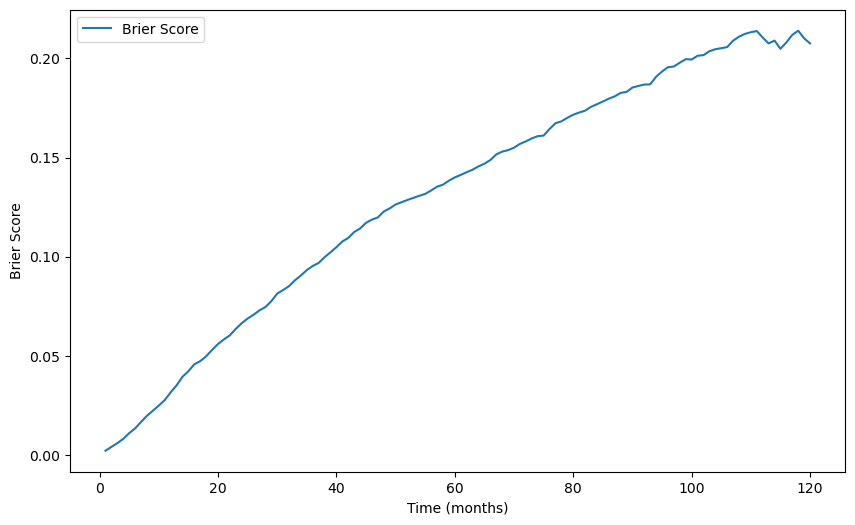

In [ ]:
# Metrics of the best RSF model
final_c_index = best.score(X_test, y_test)  # Compute the final C-index for the test dataset

# Print the C-index for both test and training datasets
print(f'C-Index Test: {final_c_index}')
print(f'C-Index Train: {best.score(X_train, y_train)}\n')

# Compute and display the IPCW C-index and Brier Score for the best model
c_index_ipcw_brier_score(best, X_train, y_train, X_test, y_test)

In [ ]:
# Best features by permutation importance
calculate_permutation_importance(best, X_test, y_test, feat_cols, random_state=seed)  # Calculate permutation importance of features for the best model

,importances_mean,importances_std
ECGRUP,0.085611,0.004987
IDADE,0.066209,0.003626
GLEASON,0.013294,0.000898
INSTITU,0.010522,0.001463
DIAGTRAT_CAT,0.010453,0.001962
TRATCONS_CAT,0.006973,0.001118
IBGEATEN,0.002744,0.000513
DRS_INST,0.002673,0.000828
ESCOLARI,0.002026,0.000652
MORFO,0.001682,0.000478


PermutationExplainer explainer: 5677it [1:31:10,  1.04it/s]                          


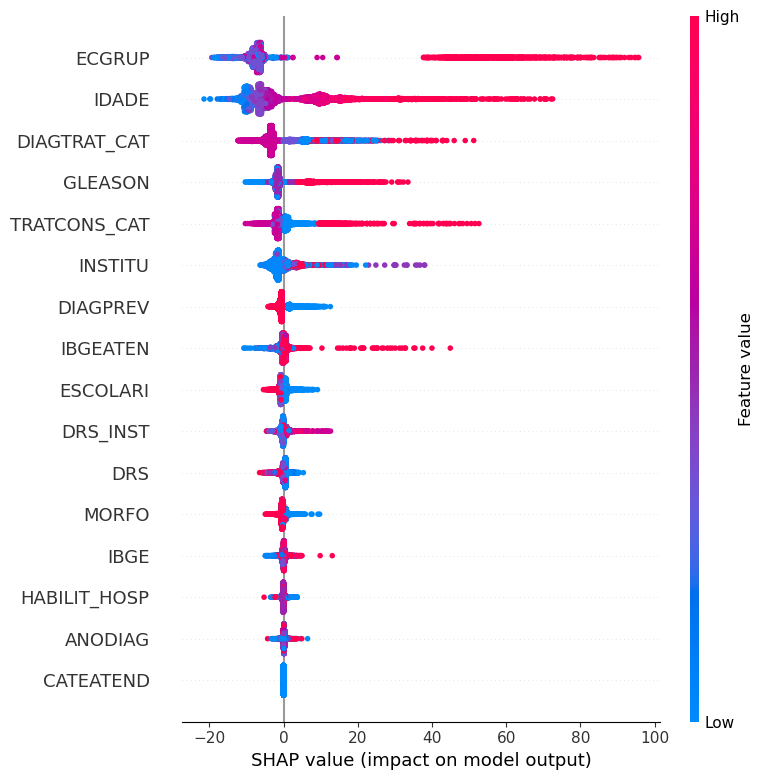

In [ ]:
# Best features by SHAP
explainer = shap.Explainer(best.predict, X_train, seed=seed,  # Create a SHAP explainer for the best model
                           output_names=feat_cols,  # Specify the feature names
                           n_jobs=-1)  # Use multiple jobs for parallel computation

shap_values = explainer(X_test)  # Calculate SHAP values for the test set

# Plot the SHAP summary plot to visualize feature importance
shap.summary_plot(shap_values, X_test, feature_names=feat_cols)

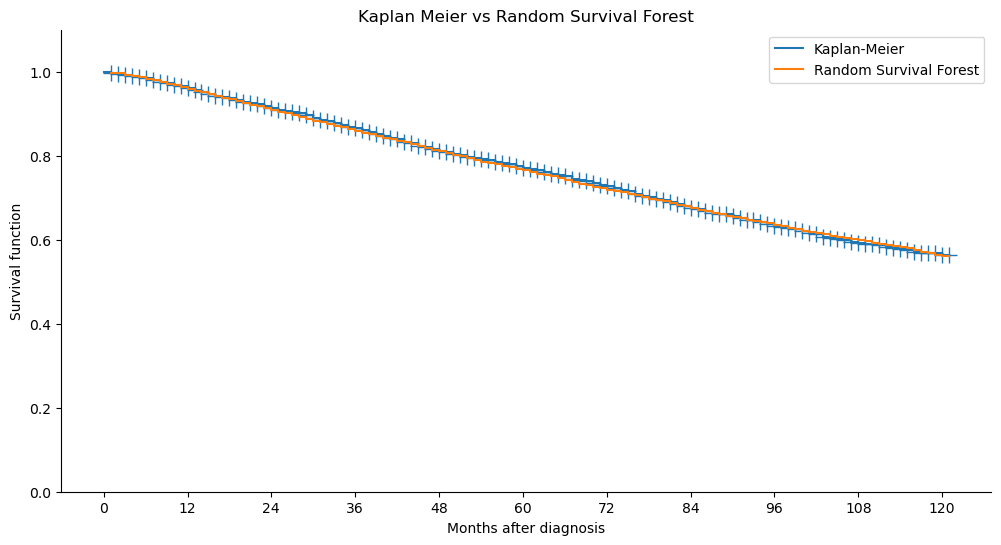

In [ ]:
# Comparison of survival curves
name = 'Random Survival Forest'  # Name of the model to be displayed on the plot

# Predict survival functions for the test set and compute the mean survival function
surv_rsf = best.predict_survival_function(X_test, return_array=True)
surv_rsf_mean = surv_rsf.mean(axis=0)  # Compute the mean survival function across all samples

# Plot the survival curve and compare with Kaplan-Meier (KM) estimates
plot_survival_curve(best.unique_times_, surv_rsf_mean,
                    name=name, compare_km=True, test_df=df_teste)  # Plot the survival curve and compare with the test dataset

### **XGBoost - AFT**

#### **Base Model**

In [ ]:
# Define weights (1.0 for events, 0.65 for censored cases)
weights = np.where(y_train['event'], 1.0, 0.65)

# The AFT model requires lower and upper bounds for survival time
label_lower_bound = y_train['time']
label_upper_bound = np.where(y_train['event'], y_train['time'], np.inf)

# Creating DMatrix for XGBoost (necessary to define bounds for AFT)
dtrain = xgb.DMatrix(X_train,
                     label_lower_bound=label_lower_bound,
                     label_upper_bound=label_upper_bound,
                     weight=weights)

dtest = xgb.DMatrix(X_test)

# Configuration of hyperparameters for the XGBoost Survival AFT model
params = {
    'objective': 'survival:aft',  # Use AFT to model survival analysis
    'eval_metric': 'aft-nloglik',  # Evaluation metric for AFT
    'aft_loss_distribution': 'normal',  # Failure time distribution ('normal', 'logistic', etc.)
    'aft_loss_distribution_scale': 1.0,  # Scale of the distribution (adjustable)
    'max_depth': 4,  # Maximum depth of trees
    'seed': seed,  # Seed for reproducibility
}

# Model training
xgb_aft = xgb.train(params, dtrain, num_boost_round=100)

# Predictions and C-Index calculation for the test set
y_pred = xgb_aft.predict(dtest)
c_index_base = concordance_index_censored(y_test['event'], y_test['time'], -y_pred)[0]

# Predictions and C-Index calculation for the training set
y_pred_train = xgb_aft.predict(dtrain)
c_index_train = concordance_index_censored(y_train['event'], y_train['time'], -y_pred_train)[0]

# Display C-Index results
print(f'C-index Test: {c_index_base}')
print(f'C-index Train: {c_index_train}')

C-index Test: 0.742304477484683
C-index Train: 0.7854972631058217


In [ ]:
# C-Index IPCW (Inverse Probability of Censoring Weight)
surv_risks = xgb_aft.predict(dtest)  # Predict the survival risks for the test set
surv_risks_train = xgb_aft.predict(dtrain)  # Predict the survival risks for the training set

# Calculate the C-Index IPCW for Test and Train data
c_index_ipcw = concordance_index_ipcw(y_train, y_test, -surv_risks)  # Compute the C-Index IPCW for the test data
c_index_ipcw_train = concordance_index_ipcw(y_train, y_train, -surv_risks_train)  # Compute the C-Index IPCW for the training data

# Display C-Index IPCW for Test and Train data
print(f'C-Index IPCW Test: {c_index_ipcw[0]}')  # Print the C-Index IPCW for the test data
print(f'C-Index IPCW Train: {c_index_ipcw_train[0]}')  # Print the C-Index IPCW for the training data

C-Index IPCW Test: 0.7051407168536856
C-Index IPCW Train: 0.7489273746023473


#### **Optuna**

**Principais Parâmetros a Otimizar no XGBoost**

1. `n_estimators` (int):
* Número de árvores (boosting rounds) que o modelo vai treinar. Mais árvores podem melhorar o aprendizado, mas aumentam o risco de overfitting e o custo computacional.
* Sugestão de valores: 50 a 1000.

2. `learning_rate` (float):
* Taxa de aprendizado usada para diminuir a contribuição de cada árvore. Taxas menores exigem mais árvores, mas aumentam a estabilidade.
* Sugestão de valores: 0.01 a 0.3 (log-scale).

3. `max_depth` (int):
* Profundidade máxima das árvores individuais. Árvores mais profundas captam interações complexas, mas correm maior risco de overfitting.
* Sugestão de valores: 3 a 30.

4. `min_child_weight` (float):
* Peso mínimo da soma dos gradientes (hessian) em uma divisão de nó. Controla o tamanho mínimo de uma divisão, evitando overfitting.
* Sugestão de valores: 1 a 10.

5. `subsample` (float):
* Percentual de amostras utilizadas em cada árvore. Reduz overfitting ao amostrar dados de forma aleatória.
* Sugestão de valores: 0.5 a 1.0.

6. `colsample_bytree` (float):
* Percentual de colunas (features) usadas para cada árvore. Melhora a robustez e evita correlação entre as árvores.
* Sugestão de valores: 0.5 a 1.0.

7. `reg_alpha` (float):
* Regularização L1 (sparsidade). Incentiva a geração de árvores mais esparsas, evitando overfitting.
* Sugestão de valores: 1e-5 a 10 (log-scale).

8. `reg_lambda` (float):
* Regularização L2 (penalização quadrática). Controla a complexidade do modelo.
* Sugestão de valores: 1e-5 a 10 (log-scale).

9. `objective` (str):
* Função objetivo. Para sobrevivência, pode-se usar:

    'survival:cox': Regressão de Cox.
    
    'survival:aft': Modelo AFT (Accelerated Failure Time).

In [ ]:
# Optuna number o trials
n_trials = 128

In [ ]:
# Folds for Cross-Validation
kf = KFold(10, shuffle=True, random_state=seed)  # Create 10-fold cross-validation with shuffling

def objective(trial):
    # Define the hyperparameters to be optimized
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 150),  # Number of estimators (trees)
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.25, step=0.01),  # Learning rate
        'max_depth': trial.suggest_int('max_depth', 2, 4),  # Maximum depth of trees
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),  # Minimum weight of child nodes
        'subsample': trial.suggest_float('subsample', 0.5, 1.0, step=0.05),  # Fraction of data used for training
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0, step=0.05),  # Fraction of features used per tree
        'reg_alpha': trial.suggest_categorical('reg_alpha', [1e-4, 1e-3, 1e-2, 1e-1, 1, 10]),  # L1 regularization term
        'reg_lambda': trial.suggest_categorical('reg_lambda', [1e-4, 1e-3, 1e-2, 1e-1, 1, 10]),  # L2 regularization term
        'aft_loss_distribution': trial.suggest_categorical('aft_loss_distribution', ['normal', 'logistic', 'extreme']),  # AFT Distribution Type
        'aft_loss_distribution_scale': trial.suggest_float('aft_loss_distribution_scale', 0.5, 2.0, step=0.05),  # AFT distribution scale
        'objective': 'survival:aft',  # AFT loss function for survival analysis
        'eval_metric': 'aft-nloglik',  # Evaluation metric for AFT model
        'random_state': seed,  # Seed for reproducibility
        'n_jobs': -1,  # Use all available cores for training
    }

    fold_c_indices = []  # List to store the C-index values from each fold

    # Loop over the folds in cross-validation
    for train_idx, valid_idx in kf.split(X_train):
        try:
            # Split the data into training and validation sets for the current fold
            X_t, X_v = X_train[train_idx], X_train[valid_idx]  # Split features
            y_t, y_v = y_train[train_idx], y_train[valid_idx]  # Split labels

            # Defining the lower and upper limits for AFT (survival time)
            label_lower_bound = y_t['time']
            label_upper_bound = np.where(y_t['event'], y_t['time'], np.inf)

            # Create DMatrix for training and validation (DMatrix is an optimized data structure for XGBoost)
            dtrain = xgb.DMatrix(X_t, label_lower_bound=label_lower_bound,
                                 label_upper_bound=label_upper_bound,
                                 weight=np.where(y_t['event'], 1.0, 0.65))  # Set event weights

            dvalid = xgb.DMatrix(X_v)  # Validation DMatrix (no labels, predictions will be made)

            # Train the XGBoost model using the specified hyperparameters
            model = xgb.train(param, dtrain, num_boost_round=100, verbose_eval=False)  # Train model with 100 boosting rounds

            # Make predictions on the validation set
            pred_valid = model.predict(dvalid)

            # Calculate the Concordance Index (C-Index) for the validation fold
            c_index = concordance_index_censored(y_v['event'],
                                                 y_v['time'],
                                                 -pred_valid)[0]
            fold_c_indices.append(c_index)  # Append the C-Index for this fold to the list

        except (ValueError, xgb.core.XGBoostError) as e:
            continue  # Next Fold

    # Return the average C-Index
    return np.nanmean(fold_c_indices)  # The objective function returns the mean C-Index from the cross-validation folds

**RandomSampler**

In [ ]:
# Hyperparameter optimization with Optuna - RandomSampler
study = optuna.create_study(direction='maximize', sampler=RandomSampler(seed),  # Create a study to maximize the objective function
                            study_name='XGB_RandomSampler')  # Study name

study.optimize(objective, n_trials=n_trials, n_jobs=-1)  # Run the optimization with 'n_trials' trials in parallel

[I 2026-06-11 21:37:42,946] A new study created in memory with name: XGB_RandomSampler
[I 2026-06-11 21:37:51,528] Trial 0 finished with value: 0.743801546501464 and parameters: {'n_estimators': 106, 'learning_rate': 0.21000000000000002, 'max_depth': 2, 'min_child_weight': 6, 'subsample': 0.8500000000000001, 'colsample_bytree': 0.6, 'reg_alpha': 10, 'reg_lambda': 0.001, 'aft_loss_distribution': 'normal', 'aft_loss_distribution_scale': 1.15}. Best is trial 0 with value: 0.743801546501464.
[I 2026-06-11 21:37:52,212] Trial 1 finished with value: 0.7386544600329439 and parameters: {'n_estimators': 58, 'learning_rate': 0.22, 'max_depth': 2, 'min_child_weight': 10, 'subsample': 0.95, 'colsample_bytree': 0.8, 'reg_alpha': 0.01, 'reg_lambda': 0.0001, 'aft_loss_distribution': 'logistic', 'aft_loss_distribution_scale': 1.4}. Best is trial 0 with value: 0.743801546501464.
[I 2026-06-11 21:38:03,011] Trial 2 finished with value: 0.7356711092063373 and parameters: {'n_estimators': 141, 'learning_r

In [ ]:
# Display the best hyperparameters found
print('Best parameters:', study.best_params)

Best parameters: {'n_estimators': 70, 'learning_rate': 0.21000000000000002, 'max_depth': 4, 'min_child_weight': 7, 'subsample': 0.95, 'colsample_bytree': 0.9, 'reg_alpha': 0.001, 'reg_lambda': 0.0001, 'aft_loss_distribution': 'extreme', 'aft_loss_distribution_scale': 0.9}


In [ ]:
# Training and evaluation with the best hyperparameters
weights = np.where(y_train['event'], 1.0, 0.65)  # Assign higher weights to events (1.0 for event and 0.65 for non-event)

# The AFT model requires lower and upper bounds for survival time
label_lower_bound = y_train['time']
label_upper_bound = np.where(y_train['event'], y_train['time'], np.inf)

best_params = study.best_params  # Get the best parameters from the study
best_params.update({'objective': 'survival:aft',  # AFT loss function for survival analysis
                    'eval_metric': 'aft-nloglik',  # Evaluation metric for AFT model
                    'random_state': seed,  # Seed for reproducibility
                    'n_jobs': -1})  # Use all available cores for training

# Prepare the DMatrix objects for training and testing data
dtrain = xgb.DMatrix(X_train,
                     label_lower_bound=label_lower_bound,
                     label_upper_bound=label_upper_bound,
                     weight=weights)  # DMatrix for training with weights

dtest = xgb.DMatrix(X_test)  # DMatrix for testing without labels

# Train the XGBoost model with the best parameters
xgb_rand = xgb.train(best_params, dtrain, num_boost_round=100)

# Make predictions on the test and training datasets
y_pred = xgb_rand.predict(dtest)  # Predictions on the test data
y_pred_train = xgb_rand.predict(dtrain)  # Predictions on the training data

# Calculate the Concordance Index (C-Index) for test and training predictions
c_index_rand = concordance_index_censored(y_test['event'], y_test['time'], -y_pred)[0]  # C-Index for test
c_index_rand_train = concordance_index_censored(y_train['event'], y_train['time'], -y_pred_train)[0]  # C-Index for train

# Print the C-Index values
print(f'C-Index Test: {c_index_rand}')  # C-Index for the test set
print(f'C-Index Train: {c_index_rand_train}')  # C-Index for the training set

C-Index Test: 0.7465223819377801
C-Index Train: 0.7719638982736555


**TPESampler**

In [ ]:
# Hyperparameter optimization with Optuna - TPESampler
study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=seed),  # Create a study with TPE sampler for optimization
                            study_name='XGB_TPESampler')  # Study name for identification

study.optimize(objective, n_trials=n_trials, n_jobs=-1)  # Run optimization for 'n_trials' trials using parallel processing

[I 2026-06-11 21:49:46,816] A new study created in memory with name: XGB_TPESampler
[I 2026-06-11 21:49:58,095] Trial 0 finished with value: 0.7409282821663555 and parameters: {'n_estimators': 137, 'learning_rate': 0.09, 'max_depth': 3, 'min_child_weight': 10, 'subsample': 0.9, 'colsample_bytree': 0.8500000000000001, 'reg_alpha': 0.0001, 'reg_lambda': 0.001, 'aft_loss_distribution': 'logistic', 'aft_loss_distribution_scale': 1.1}. Best is trial 0 with value: 0.7409282821663555.
[I 2026-06-11 21:49:59,189] Trial 1 finished with value: 0.7357162499428626 and parameters: {'n_estimators': 57, 'learning_rate': 0.13, 'max_depth': 2, 'min_child_weight': 9, 'subsample': 0.8, 'colsample_bytree': 1.0, 'reg_alpha': 0.01, 'reg_lambda': 10, 'aft_loss_distribution': 'extreme', 'aft_loss_distribution_scale': 0.5}. Best is trial 0 with value: 0.7409282821663555.
[I 2026-06-11 21:50:10,006] Trial 2 finished with value: 0.7391149953617135 and parameters: {'n_estimators': 103, 'learning_rate': 0.12, 'max

In [ ]:
# Display the best hyperparameters found during optimization
print('Best parameters:', study.best_params)

Best parameters: {'n_estimators': 93, 'learning_rate': 0.19, 'max_depth': 4, 'min_child_weight': 2, 'subsample': 0.8, 'colsample_bytree': 0.5, 'reg_alpha': 0.0001, 'reg_lambda': 10, 'aft_loss_distribution': 'extreme', 'aft_loss_distribution_scale': 0.8500000000000001}


In [ ]:
# Training and evaluation with the best hyperparameters
weights = np.where(y_train['event'], 1.0, 0.65)  # Assign higher weights to events (1.0 for event and 0.65 for non-event)

# The AFT model requires lower and upper bounds for survival time
label_lower_bound = y_train['time']
label_upper_bound = np.where(y_train['event'], y_train['time'], np.inf)

best_params = study.best_params  # Get the best parameters from the study
best_params.update({'objective': 'survival:aft',  # AFT loss function for survival analysis
                    'eval_metric': 'aft-nloglik',  # Evaluation metric for AFT model
                    'random_state': seed,  # Seed for reproducibility
                    'n_jobs': -1})  # Use all available cores for training

# Prepare the DMatrix objects for training and testing data
dtrain = xgb.DMatrix(X_train,
                     label_lower_bound=label_lower_bound,
                     label_upper_bound=label_upper_bound,
                     weight=weights)  # DMatrix for training with weights

dtest = xgb.DMatrix(X_test)  # DMatrix for testing without labels

# Train the XGBoost model with the best parameters
xgb_tpe = xgb.train(best_params, dtrain, num_boost_round=100)

# Make predictions on the test and training datasets
y_pred = xgb_tpe.predict(dtest)  # Predictions on the test data
y_pred_train = xgb_tpe.predict(dtrain)  # Predictions on the training data

# Calculate the Concordance Index (C-Index) for test and training predictions
c_index_tpe = concordance_index_censored(y_test['event'], y_test['time'], -y_pred)[0]  # C-Index for test
c_index_tpe_train = concordance_index_censored(y_train['event'], y_train['time'], -y_pred_train)[0]  # C-Index for train

# Print the C-Index values
print(f'C-Index Test: {c_index_tpe}')  # C-Index for the test set
print(f'C-Index Train: {c_index_tpe_train}')  # C-Index for the training set

C-Index Test: 0.7475182597184679
C-Index Train: 0.7642157041214752


**CmaEsSampler**

In [ ]:
# Hyperparameter optimization with Optuna - CmaEsSampler
study = optuna.create_study(direction='maximize', sampler=CmaEsSampler(seed=seed),  # Create a study with CMA-ES sampler for optimization
                            study_name='XGB_CmaEsSampler')  # Study name for identification

study.optimize(objective, n_trials=n_trials, n_jobs=-1)  # Run optimization for 'n_trials' trials using parallel processing

[I 2026-06-11 22:03:21,734] A new study created in memory with name: XGB_CmaEsSampler
[I 2026-06-11 22:03:32,533] Trial 1 finished with value: 0.7422362152606665 and parameters: {'n_estimators': 100, 'learning_rate': 0.23, 'max_depth': 4, 'min_child_weight': 3, 'subsample': 0.65, 'colsample_bytree': 0.55, 'reg_alpha': 0.0001, 'reg_lambda': 0.0001, 'aft_loss_distribution': 'normal', 'aft_loss_distribution_scale': 1.8}. Best is trial 1 with value: 0.7422362152606665.
[W 2026-06-11 22:03:32,549] The parameter `reg_alpha` in Trial#2 is sampled independently using `RandomSampler` instead of `CmaEsSampler`, potentially degrading the optimization performance. This fallback happened because dynamic search space and `CategoricalDistribution` are not supported by `CmaEsSampler`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `CmaEsSampler` if this independent sampling is intended behavior.
[W 2026-06-11 22:03:32,556] The parameter `reg_lambd

In [ ]:
# Display the best hyperparameters found during optimization
print('Best parameters:', study.best_params)

Best parameters: {'n_estimators': 118, 'learning_rate': 0.18000000000000002, 'max_depth': 4, 'min_child_weight': 7, 'subsample': 0.75, 'colsample_bytree': 0.65, 'reg_alpha': 0.0001, 'reg_lambda': 0.01, 'aft_loss_distribution': 'extreme', 'aft_loss_distribution_scale': 0.95}


In [ ]:
# Training and evaluation with the best hyperparameters
weights = np.where(y_train['event'], 1.0, 0.65)  # Assign higher weights to events (1.0 for event and 0.65 for non-event)

# The AFT model requires lower and upper bounds for survival time
label_lower_bound = y_train['time']
label_upper_bound = np.where(y_train['event'], y_train['time'], np.inf)

best_params = study.best_params  # Get the best parameters from the study
best_params.update({'objective': 'survival:aft',  # AFT loss function for survival analysis
                    'eval_metric': 'aft-nloglik',  # Evaluation metric for AFT model
                    'random_state': seed,  # Seed for reproducibility
                    'n_jobs': -1})  # Use all available cores for training

# Prepare the DMatrix objects for training and testing data
dtrain = xgb.DMatrix(X_train,
                     label_lower_bound=label_lower_bound,
                     label_upper_bound=label_upper_bound,
                     weight=weights)  # DMatrix for training with weights

dtest = xgb.DMatrix(X_test)  # DMatrix for testing without labels

# Train the XGBoost model with the best parameters
xgb_cma = xgb.train(best_params, dtrain, num_boost_round=100)

# Make predictions on the test and training datasets
y_pred = xgb_cma.predict(dtest)  # Predictions on the test data
y_pred_train = xgb_cma.predict(dtrain)  # Predictions on the training data

# Calculate the Concordance Index (C-Index) for test and training predictions
c_index_cma = concordance_index_censored(y_test['event'], y_test['time'], -y_pred)[0]  # C-Index for test
c_index_cma_train = concordance_index_censored(y_train['event'], y_train['time'], -y_pred_train)[0]  # C-Index for train

# Print the C-Index values
print(f'C-Index Test: {c_index_cma}')  # C-Index for the test set
print(f'C-Index Train: {c_index_cma_train}')  # C-Index for the training set

C-Index Test: 0.7465407196306256
C-Index Train: 0.7657797042433936


#### **Best XGBoost Model**

In [ ]:
# Best XGBoost model
scores = [c_index_base, c_index_rand, c_index_tpe, c_index_cma]  # List of C-index scores for each model
models = [xgb_aft, xgb_rand, xgb_tpe, xgb_cma]  # List of the trained models

# Find the model with the highest C-index
id_best_score = scores.index(max(scores))  # Get the index of the model with the best score
best = models[id_best_score]  # Select the best model based on the highest C-index

print(best)  # Display the best model

In [ ]:
# Make predictions on the validation and training sets
y_pred = best.predict(dtest)  # Predictions on the test set
y_pred_train = best.predict(dtrain)  # Predictions on the training set

# Calculate the C-Index for the test and training sets
final_c_index = concordance_index_censored(y_test['event'], y_test['time'], -y_pred)[0]  # C-Index for the test set
final_c_index_train = concordance_index_censored(y_train['event'], y_train['time'], -y_pred_train)[0]  # C-Index for the training set

print('C-Index')  # Print label for C-Index
print(f'> Test: {final_c_index}')  # Print C-Index for the test set
print(f'> Train: {final_c_index_train}')  # Print C-Index for the training set

c_index_ipcw = concordance_index_ipcw(y_train, y_test, -y_pred)  # C-Index IPCW for the test set
c_index_ipcw_train = concordance_index_ipcw(y_train, y_train, -y_pred_train)  # C-Index IPCW for the training set

print('\nC-Index IPCW')  # Print label for C-Index IPCW
print(f'> Test: {c_index_ipcw[0]}')  # Print IPCW C-Index for the test set
print(f'> Train: {c_index_ipcw_train[0]}')  # Print IPCW C-Index for the training set

C-Index
> Test: 0.7475182597184679
> Train: 0.7642157041214752

C-Index IPCW
> Test: 0.7156374902772865
> Train: 0.7363340621461406


In [ ]:
# Best features by permutation importance
calculate_permutation_importance_xgb(best, X_test, y_test, feat_cols, random_state=seed)  # Calculate permutation importance of features for the best model

,importances_mean,importances_std
CATEATEND,0.000000,0.000000
IBGE,-0.000171,0.000563
MORFO,-0.000567,0.000275
HABILIT_HOSP,-0.000769,0.000270
DIAGPREV,-0.001063,0.000591
ANODIAG,-0.001070,0.000554
DRS,-0.001435,0.000419
ESCOLARI,-0.001636,0.000584
DRS_INST,-0.002611,0.000794
IBGEATEN,-0.003449,0.000659


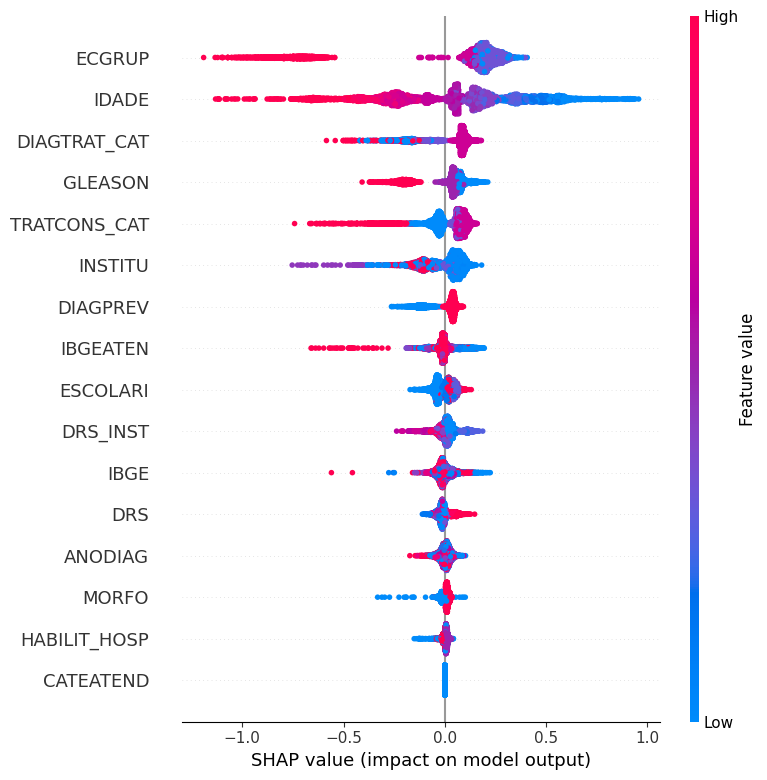

In [ ]:
# Create a SHAP TreeExplainer for the best model
explainer = shap.TreeExplainer(best)

# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test)

# Generate a summary plot to visualize the SHAP values for each feature
shap.summary_plot(shap_values, X_test, feature_names=feat_cols)

## **Machine Learning Survival - PSA**

The training process was conducted with 'PSA' variable, along with other variables in the database.

### Best Model Results - RSF and XGB-AFT on different metrics
- C-Index: XGB-AFT - 0,7470
- C-Index IPCW: RSF - 0,7114

### **Data preparation for survival models**

In [ ]:
# Reading Training Data
df_treino = pd.read_csv('prostata_treino.csv')  # Load the training data from the CSV file
print(df_treino.shape)  # Print the dimensions of the training DataFrame
df_treino.head(3).style.set_sticky(axis="columns") # Display the first 3 rows of the training DataFrame

(22703, 34)


,INSTITU,ESCOLARI,IDADE,CEP,IBGE,CATEATEND,DIAGPREV,TOPO,TOPOGRUP,MORFO,EC,ECGRUP,PSA,GLEASON,ANODIAG,DRS,RRAS,DSCINST,IBGEATEN,DRS_INST,RRAS_INST,CIDADE_INST,BAIRRO_RESID,BAIRRO_HOSP,HABILIT_HOSP,DISTANCIA_CARRO,ULTIDIAG,TRATCONS_CAT,DIAGTRAT_CAT,ivs_infraestrutura_urbana,ivs_capital_humano,ivs_renda_e_trabalho,meses_diag,OBITO_GERAL
0,20737,3,78,15790000,3544509.000000,2,2,C619,C61,85503,IIA,II,1,2,2017,15,RRAS 12,FUND PIO XII,3505500,5,RRAS 13,BARRETOS,nan,Centro,1,3,2591,3,3,0,0,1,87,0
1,208068,3,64,8693190,3552502.000000,2,2,C619,C61,81403,IIA,II,1,1,2014,1,RRAS 02,HOSP CLINICAS LUZIA PINHO MELO,3530607,1,RRAS 02,MOGI DAS CRUZES,Cidade Boa Vista,Vila Mogilar,0,1,1932,0,0,3,1,2,65,0
2,16624,2,65,4863600,3550308.000000,2,2,C619,C61,81403,IIA,II,1,2,2014,1,RRAS 06,IAVC,3550308,1,RRAS 06,SAO PAULO,Jardim Arco-Iris,Vila Buarque,1,2,3734,1,2,3,1,1,121,0


In [ ]:
# Reading Test Data
df_teste = pd.read_csv('prostata_teste.csv')  # Load the test data from the CSV file
print(df_teste.shape)  # Print the dimensions of the test DataFrame
df_teste.head(3).style.set_sticky(axis="columns")  # Display the first 3 rows of the test DataFrame

(5676, 34)


,INSTITU,ESCOLARI,IDADE,CEP,IBGE,CATEATEND,DIAGPREV,TOPO,TOPOGRUP,MORFO,EC,ECGRUP,PSA,GLEASON,ANODIAG,DRS,RRAS,DSCINST,IBGEATEN,DRS_INST,RRAS_INST,CIDADE_INST,BAIRRO_RESID,BAIRRO_HOSP,HABILIT_HOSP,DISTANCIA_CARRO,ULTIDIAG,TRATCONS_CAT,DIAGTRAT_CAT,ivs_infraestrutura_urbana,ivs_capital_humano,ivs_renda_e_trabalho,meses_diag,OBITO_GERAL
0,20737,2,55,15802125,3511102.000000,2,2,C619,C61,85503,IIB,II,1,2,2018,15,RRAS 12,FUND PIO XII,3505500,5,RRAS 13,BARRETOS,Parque Residencial Agudo Romão,Centro,1,3,2450,2,2,0,1,0,82,0
1,21130,3,64,14860000,3505609.000000,2,1,C619,C61,85503,I,I,1,1,2015,13,RRAS 13,HOSP CLINICAS DE RIBEIRAO PRETO,3543402,13,RRAS 13,RIBEIRAO PRETO,nan,Vila Monte Alegre,1,2,3383,2,2,3,2,1,113,0
2,21130,2,60,15970000,3546504.000000,2,2,C619,C61,85503,IIA,II,1,1,2016,3,RRAS 18,HOSP CLINICAS DE RIBEIRAO PRETO,3543402,13,RRAS 13,RIBEIRAO PRETO,nan,Vila Monte Alegre,1,3,2858,0,0,1,1,1,96,0


In [ ]:
# Y train and test for survival data (Death, Months from Diagnosis)
y_train = Surv.from_arrays(df_treino.OBITO_GERAL, df_treino.meses_diag)  # Create survival data for training set
y_test = Surv.from_arrays(df_teste.OBITO_GERAL, df_teste.meses_diag)  # Create survival data for test set

In [ ]:
# X train and test after removing unnecessary columns, including Death and Months from Diagnosis (which go to the target Y)
list_drop = ['CEP', 'TOPO', 'TOPOGRUP','EC', 'RRAS','DSCINST', 'RRAS_INST',
             'CIDADE_INST', 'BAIRRO_RESID', 'BAIRRO_HOSP','ULTIDIAG',
             'OBITO_GERAL', 'meses_diag','GLEASON','DISTANCIA_CARRO',
             'ivs_infraestrutura_urbana', 'ivs_capital_humano',
             'ivs_renda_e_trabalho']

X_train = df_treino.drop(list_drop, axis=1)  # Remove specified columns from the training dataset

X_test = df_teste.drop(list_drop, axis=1)  # Remove specified columns from the test dataset

In [ ]:
# Preprocessing of Training and Test data
X_train, X_test, feat_cols, enc, norm = preprocessing(X_train, X_test,
                                                      norm_name='StandardScaler',  # Specify normalization method
                                                      return_enc_norm=True,  # Return encoder and normalizer objects
                                                      random_state=seed)  # Set random state for reproducibility

# Display the shapes of the processed training and test datasets
X_train.shape, X_test.shape

((22703, 16), (5676, 16))

In [ ]:
# Features columns
feat_cols

Index(['INSTITU', 'ESCOLARI', 'IDADE', 'IBGE', 'CATEATEND', 'DIAGPREV',
       'MORFO', 'ECGRUP', 'PSA', 'ANODIAG', 'DRS', 'IBGEATEN', 'DRS_INST',
       'HABILIT_HOSP', 'TRATCONS_CAT', 'DIAGTRAT_CAT'],
      dtype='object')

### **Random Survival Forest**

#### **Base Model**

In [ ]:
# RSF (Random Survival Forest) Model
rsf = RandomSurvivalForest(max_depth=9, n_jobs=-1, random_state=seed)  # Initialize the RSF model with a max depth of 11
rsf.fit(X_train, y_train)  # Train the model using the training data

# Calculate the C-index for the test dataset
c_index_base = rsf.score(X_test, y_test)

# Print the C-index for both test and training datasets
print(f'C-Index Test: {c_index_base}')
print(f'C-Index Train: {rsf.score(X_train, y_train)}')

C-Index Test: 0.7446013126966894
C-Index Train: 0.7723667486365646


C-Index IPCW Teste: 0.7100522801192344
C-Index IPCW Treino: 0.7427087588280449

Integrated Brier Score (IBS): 0.13093420101242678

Brier Score:
    > 1 ano = 0.031594851921702354
    > 3 anos = 0.09521800314462105
    > 5 anos = 0.13986258783029776



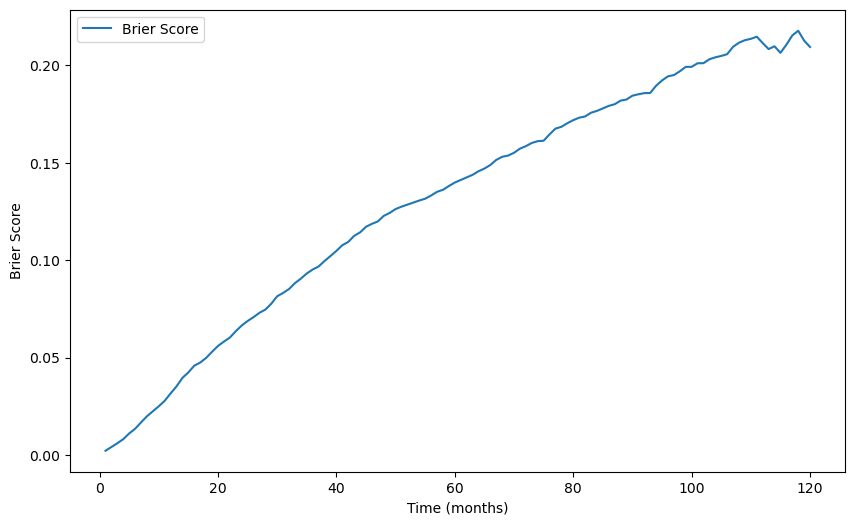

In [ ]:
# C-Index IPCW and Brier Score
c_index_ipcw_brier_score(rsf, X_train, y_train, X_test, y_test)  # Compute and evaluate the IPCW C-index and Brier Score

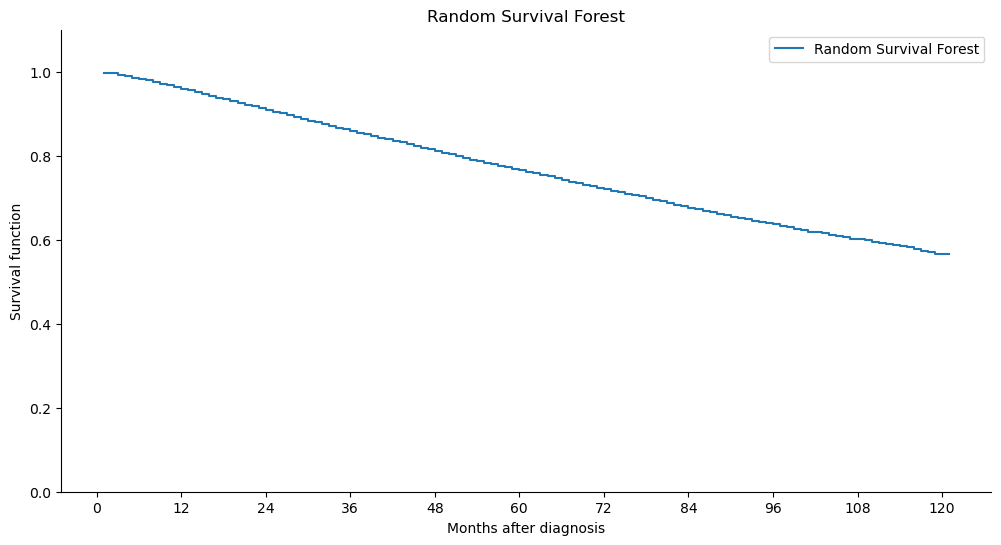

In [ ]:
# Survival prediction (Probability)
surv_rsf = rsf.predict_survival_function(X_test, return_array=True)  # Predict survival probabilities for the test set
surv_rsf_mean = surv_rsf.mean(axis=0)  # Compute the mean survival probability across samples

# Plot the predicted survival curve
name = 'Random Survival Forest'

plot_survival_curve(rsf.unique_times_, surv_rsf_mean, name=name)  # Generate and display the survival curve

In [ ]:
# Survival probability at 12, 36, 60, 84 and 120 months
print(f'12 months: {surv_rsf_mean[12]}')  # Print survival probability at 12 months
print(f'36 months: {surv_rsf_mean[36]}')  # Print survival probability at 36 months
print(f'60 months: {surv_rsf_mean[60]}')  # Print survival probability at 60 months
print(f'84 months: {surv_rsf_mean[84]}')  # Print survival probability at 84 months
print(f'120 months: {surv_rsf_mean[120]}')  # Print survival probability at 120 months

12 months: 0.955309772689081
36 months: 0.8548671858281306
60 months: 0.7614011154114483
84 months: 0.6722722518605414
120 months: 0.5652246170360937


#### **Optuna**

**Principais Hiperparâmetros para Otimização no RSF**

1. `n_estimators` (int)
* Descrição: Número de árvores na floresta. Mais árvores geralmente aumentam a precisão, mas podem tornar o treinamento mais lento.
* Sugestão de valores: 50 a 1000.

2. `max_depth` (int)
* Descrição: Profundidade máxima das árvores. Uma maior profundidade permite capturar padrões complexos, mas pode levar ao overfitting.
* Sugestão de valores: 3 a 30.

3. `min_samples_split` (int)
* Descrição: Número mínimo de amostras necessárias para dividir um nó. Controla o crescimento da árvore. Valores mais altos evitam o overfitting.
* Sugestão de valores: 2 a 20.

4. `min_samples_leaf` (int)
* Descrição: Número mínimo de amostras necessárias para formar uma folha. Valores maiores evitam folhas com muito poucas amostras, reduzindo o overfitting.
* Sugestão de valores: 1 a 50.

5. `max_features` (float, int, str)
* Descrição: Proporção ou número de recursos a serem considerados ao dividir um nó. Define a aleatoriedade do modelo, balanceando viés e variância.

    a) 'sqrt': Considera a raiz quadrada do total de features.

    b) 'log2': Considera o logaritmo base 2 do total de features.

    c) Valores numéricos: Pode ser um número específico ou uma proporção das features.

* Sugestão de valores: 'sqrt', 'log2', ou entre 0.1 e 1.0.

6. `bootstrap` (bool)
* Descrição: Se as amostras de treino são extraídas com ou sem reposição. Aumenta a diversidade entre as árvores, reduzindo o overfitting.
* Sugestão de valores: True ou False.

7. `oob_score` (bool)
* Descrição: Se o modelo deve calcular o erro fora da amostra (out-of-bag) durante o treinamento. Pode fornecer uma estimativa do desempenho sem a necessidade de um conjunto de validação separado.
* Sugestão de valores: True ou False.

8. `n_jobs` (int)
* Descrição: Número de processadores a serem usados em paralelo. Define a quantidade de processamento paralelo.
* Sugestão de valores: -1 (usa todos os processadores disponíveis).

9. `min_weight_fraction_leaf` (float)
* Descrição: Fração mínima do peso total das amostras que deve estar em cada folha. Previne folhas muito pequenas com base no peso das amostras.
* Sugestão de valores: 0.0 a 0.5.

In [ ]:
# Optuna number of trials
n_trials = 128

In [ ]:
# Folds for cross-validation
kf = KFold(n_splits=10, shuffle=True, random_state=seed)  # Create a 10-fold cross-validation strategy

# Function to compute the C-index for a given estimator
def c_index(estimator, X, y):
    cindex = estimator.score(X, y)  # Compute the C-index score
    return cindex

# Objective function for hyperparameter optimization
def objective(trial):
    # Define hyperparameters to be optimized
    n_estimators = trial.suggest_int('n_estimators', 50, 150)  # Number of trees in the forest
    max_depth = trial.suggest_int('max_depth', 4, 9)  # Maximum depth of each tree
    min_samples_split = trial.suggest_int('min_samples_split', 3, 12)  # Min samples required to split a node
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 3, 12)  # Min samples required at a leaf node
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.5, 0.75, 1.0])  # Feature selection strategy
    bootstrap = trial.suggest_categorical('bootstrap', [True, False])  # Whether to use bootstrap sampling

    # Create and train the model with the suggested hyperparameters
    rsf = RandomSurvivalForest(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        bootstrap=bootstrap,
        random_state=seed,
        n_jobs=-1
    )

    # Perform cross-validation and return the mean C-index score
    return cross_val_score(rsf, X_train, y_train, cv=kf, scoring=c_index).mean()

**RandomSampler**

In [ ]:
# # Otimização dos hiperparâmetros com Optuna - RandomSampler
# study = optuna.create_study(direction='maximize', sampler=RandomSampler(seed),
#                             study_name='RSF_RandomSampler')
# study.optimize(objective, n_trials=n_trials, n_jobs=-1)

In [ ]:
%%time
# Pickle filename to save the study
pickle_filename = 'prost_opt_rsf_rand.pkl'

# Load existing study or create a new one
if os.path.exists(pickle_filename):
    with open(pickle_filename, 'rb') as f:
        study = pickle.load(f)
else:
    study = optuna.create_study(direction='maximize', sampler=RandomSampler(seed=seed),
                                study_name='RSF_RandomSampler')

# Total number of desired trials
completed_trials = len(study.trials)

# Execute remaining trials in batches
while completed_trials < n_trials:
    study.optimize(objective, n_trials=64, n_jobs=-1)
    completed_trials = len(study.trials)
    print(f"\nTrials completed: {completed_trials}/{n_trials}")

    # Save the study after each batch
    with open(pickle_filename, 'wb') as f:
        pickle.dump(study, f)

[I 2026-06-15 10:50:49,608] A new study created in memory with name: RSF_RandomSampler
[I 2026-06-15 10:54:34,855] Trial 7 finished with value: 0.7385718596057562 and parameters: {'n_estimators': 56, 'max_depth': 5, 'min_samples_split': 6, 'min_samples_leaf': 7, 'max_features': 'sqrt', 'bootstrap': False}. Best is trial 7 with value: 0.7385718596057562.
[I 2026-06-15 10:54:36,540] Trial 25 finished with value: 0.7422829302054231 and parameters: {'n_estimators': 51, 'max_depth': 9, 'min_samples_split': 5, 'min_samples_leaf': 11, 'max_features': 0.75, 'bootstrap': True}. Best is trial 25 with value: 0.7422829302054231.
[I 2026-06-15 10:54:36,553] Trial 17 finished with value: 0.7405949839236076 and parameters: {'n_estimators': 50, 'max_depth': 6, 'min_samples_split': 12, 'min_samples_leaf': 8, 'max_features': 'sqrt', 'bootstrap': False}. Best is trial 25 with value: 0.7422829302054231.
[I 2026-06-15 10:54:37,456] Trial 33 finished with value: 0.7379804568799141 and parameters: {'n_estima


Trials completed: 64/128


[I 2026-06-15 10:58:16,522] Trial 115 finished with value: 0.7407171390213 and parameters: {'n_estimators': 53, 'max_depth': 6, 'min_samples_split': 12, 'min_samples_leaf': 7, 'max_features': 'log2', 'bootstrap': False}. Best is trial 15 with value: 0.7461719300938908.
[I 2026-06-15 10:58:17,184] Trial 108 finished with value: 0.7367685873586894 and parameters: {'n_estimators': 56, 'max_depth': 6, 'min_samples_split': 11, 'min_samples_leaf': 8, 'max_features': 0.75, 'bootstrap': False}. Best is trial 15 with value: 0.7461719300938908.
[I 2026-06-15 10:58:17,199] Trial 107 finished with value: 0.742366753990772 and parameters: {'n_estimators': 63, 'max_depth': 9, 'min_samples_split': 10, 'min_samples_leaf': 9, 'max_features': 0.75, 'bootstrap': True}. Best is trial 15 with value: 0.7461719300938908.
[I 2026-06-15 10:58:17,565] Trial 72 finished with value: 0.7406480703127174 and parameters: {'n_estimators': 79, 'max_depth': 6, 'min_samples_split': 4, 'min_samples_leaf': 10, 'max_feature


Trials completed: 128/128
CPU times: user 3h 58min 38s, sys: 3min 50s, total: 4h 2min 28s
Wall time: 7min 30s


In [ ]:
# Display the best hyperparameters found by Optuna
print('Best parameters:', study.best_params)  # Print the best hyperparameters after optimization

Best parameters: {'n_estimators': 141, 'max_depth': 9, 'min_samples_split': 6, 'min_samples_leaf': 5, 'max_features': 'log2', 'bootstrap': True}


In [ ]:
# Training and metrics with the best hyperparameters
best_params = study.best_params  # Get the best parameters from the study
rsf_rand = RandomSurvivalForest(**best_params, random_state=seed)  # Initialize the RSF model with the best parameters
rsf_rand.fit(X_train, y_train)  # Train the model with the training data

# Compute the C-index for the test dataset
c_index_rand = rsf_rand.score(X_test, y_test)

# Print the C-index for both test and training datasets
print(f'C-Index Test: {c_index_rand}')
print(f'C-Index Train: {rsf_rand.score(X_train, y_train)}')

C-Index Test: 0.7442576768713577
C-Index Train: 0.7720184807366319


**TPESampler**

In [ ]:
# # Otimização dos hiperparâmetros com Optuna - TPESampler
# study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=seed),
#                             study_name='RSF_TPESampler')
# study.optimize(objective, n_trials=n_trials, n_jobs=-1)

In [ ]:
%%time
# Pickle filename to save the study
pickle_filename = 'prost_opt_rsf_tpe.pkl'

# Load existing study or create a new one
if os.path.exists(pickle_filename):
    with open(pickle_filename, 'rb') as f:
        study = pickle.load(f)
else:
    study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=seed),
                                study_name='RSF_TPESampler')

# Total number of desired trials
completed_trials = len(study.trials)

# Execute remaining trials in batches
while completed_trials < n_trials:
    study.optimize(objective, n_trials=64, n_jobs=-1)
    completed_trials = len(study.trials)
    print(f"\nTrials completed: {completed_trials}/{n_trials}")

    # Save the study after each batch
    with open(pickle_filename, 'wb') as f:
        pickle.dump(study, f)

[I 2026-06-15 10:58:30,333] A new study created in memory with name: RSF_TPESampler
[I 2026-06-15 11:02:55,797] Trial 6 finished with value: 0.7416007810239211 and parameters: {'n_estimators': 69, 'max_depth': 7, 'min_samples_split': 11, 'min_samples_leaf': 4, 'max_features': 0.5, 'bootstrap': True}. Best is trial 6 with value: 0.7416007810239211.
[I 2026-06-15 11:02:59,841] Trial 38 finished with value: 0.7417254670333009 and parameters: {'n_estimators': 51, 'max_depth': 8, 'min_samples_split': 3, 'min_samples_leaf': 8, 'max_features': 0.75, 'bootstrap': True}. Best is trial 38 with value: 0.7417254670333009.
[I 2026-06-15 11:03:00,062] Trial 56 finished with value: 0.743125740778559 and parameters: {'n_estimators': 58, 'max_depth': 7, 'min_samples_split': 12, 'min_samples_leaf': 9, 'max_features': 'log2', 'bootstrap': False}. Best is trial 56 with value: 0.743125740778559.
[I 2026-06-15 11:03:00,925] Trial 44 finished with value: 0.7408165507508262 and parameters: {'n_estimators': 71


Trials completed: 64/128


[I 2026-06-15 11:08:22,919] Trial 81 finished with value: 0.7464341924262496 and parameters: {'n_estimators': 121, 'max_depth': 9, 'min_samples_split': 7, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 10 with value: 0.7464503147093982.
[I 2026-06-15 11:08:22,974] Trial 92 finished with value: 0.7464414499565514 and parameters: {'n_estimators': 125, 'max_depth': 9, 'min_samples_split': 7, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 10 with value: 0.7464503147093982.
[I 2026-06-15 11:08:23,044] Trial 95 finished with value: 0.7464454644773657 and parameters: {'n_estimators': 124, 'max_depth': 9, 'min_samples_split': 7, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 10 with value: 0.7464503147093982.
[I 2026-06-15 11:08:23,090] Trial 64 finished with value: 0.7464454644773657 and parameters: {'n_estimators': 124, 'max_depth': 9, 'min_samples_split': 7, 'min_samples_leaf': 3, 'max_feat


Trials completed: 128/128
CPU times: user 3h 20min 31s, sys: 4min 8s, total: 3h 24min 40s
Wall time: 9min 53s


In [ ]:
# Display the best hyperparameters found by Optuna
print('Best parameters:', study.best_params)  # Print the best hyperparameters after optimization

Best parameters: {'n_estimators': 124, 'max_depth': 9, 'min_samples_split': 6, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'bootstrap': True}


In [ ]:
# Training and metrics with the best hyperparameters
best_params = study.best_params  # Get the best parameters from the study
rsf_tpe = RandomSurvivalForest(**best_params, random_state=seed)  # Initialize the RSF model with the best parameters
rsf_tpe.fit(X_train, y_train)  # Train the model with the training data

# Compute the C-index for the test dataset
c_index_tpe = rsf_tpe.score(X_test, y_test)

# Print the C-index for both test and training datasets
print(f'C-Index Test: {c_index_tpe}')
print(f'C-Index Train: {rsf_tpe.score(X_train, y_train)}')

C-Index Test: 0.7445904197936744
C-Index Train: 0.772428590235605


**CmaEsSampler**

In [ ]:
# # Otimização dos hiperparâmetros com Optuna - CmaEsSampler
# study = optuna.create_study(direction='maximize', sampler=CmaEsSampler(seed=seed),
#                             study_name='RSF_CmaEsSampler')
# study.optimize(objective, n_trials=n_trials, n_jobs=-1)

In [ ]:
%%time
# Pickle filename to save the study
pickle_filename = 'prost_opt_rsf_cma.pkl'

# Load existing study or create a new one
if os.path.exists(pickle_filename):
    with open(pickle_filename, 'rb') as f:
        study = pickle.load(f)
else:
    study = optuna.create_study(direction='maximize', sampler=CmaEsSampler(seed=seed),
                                study_name='RSF_CmaEsSampler')

# Total number of desired trials
completed_trials = len(study.trials)

# Execute remaining trials in batches
while completed_trials < n_trials:
    study.optimize(objective, n_trials=64, n_jobs=-1)
    completed_trials = len(study.trials)
    print(f"\nTrials completed: {completed_trials}/{n_trials}")

    # Save the study after each batch
    with open(pickle_filename, 'wb') as f:
        pickle.dump(study, f)

[I 2026-06-15 11:08:32,513] A new study created in memory with name: RSF_CmaEsSampler
[I 2026-06-15 11:13:05,219] Trial 0 finished with value: 0.7423137999075657 and parameters: {'n_estimators': 51, 'max_depth': 9, 'min_samples_split': 6, 'min_samples_leaf': 4, 'max_features': 0.75, 'bootstrap': True}. Best is trial 0 with value: 0.7423137999075657.
[I 2026-06-15 11:13:07,748] Trial 7 finished with value: 0.7434676106015161 and parameters: {'n_estimators': 71, 'max_depth': 7, 'min_samples_split': 7, 'min_samples_leaf': 10, 'max_features': 'log2', 'bootstrap': True}. Best is trial 7 with value: 0.7434676106015161.
[I 2026-06-15 11:13:08,693] Trial 19 finished with value: 0.7390823450571158 and parameters: {'n_estimators': 52, 'max_depth': 6, 'min_samples_split': 8, 'min_samples_leaf': 3, 'max_features': 0.5, 'bootstrap': False}. Best is trial 7 with value: 0.7434676106015161.
[I 2026-06-15 11:13:08,821] Trial 55 finished with value: 0.7372064470975622 and parameters: {'n_estimators': 96


Trials completed: 64/128


[W 2026-06-15 11:13:13,725] The parameter 'max_features' in trial#73 is sampled independently by using `RandomSampler` instead of `CmaEsSampler` (optimization performance may be degraded). `CmaEsSampler` does not support dynamic search space or `CategoricalDistribution`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `CmaEsSampler`, if this independent sampling is intended behavior.
[W 2026-06-15 11:13:13,726] The parameter 'bootstrap' in trial#64 is sampled independently by using `RandomSampler` instead of `CmaEsSampler` (optimization performance may be degraded). `CmaEsSampler` does not support dynamic search space or `CategoricalDistribution`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `CmaEsSampler`, if this independent sampling is intended behavior.
[W 2026-06-15 11:13:13,727] The parameter 'max_features' in trial#79 is sampled independently by using `RandomSampler` in


Trials completed: 128/128
CPU times: user 4h 20min 18s, sys: 3min 23s, total: 4h 23min 42s
Wall time: 9min 6s


In [ ]:
# Display the best hyperparameters found by Optuna
print('Best parameters:', study.best_params)  # Print the best hyperparameters after optimization

Best parameters: {'n_estimators': 120, 'max_depth': 9, 'min_samples_split': 9, 'min_samples_leaf': 7, 'max_features': 'sqrt', 'bootstrap': True}


In [ ]:
# Training and metrics with the best hyperparameters
best_params = study.best_params  # Get the best parameters from the study
rsf_cma = RandomSurvivalForest(**best_params, random_state=seed)  # Initialize the RSF model with the best parameters
rsf_cma.fit(X_train, y_train)  # Train the model with the training data

# Compute the C-index for the test dataset
c_index_cma = rsf_cma.score(X_test, y_test)

# Print the C-index for both test and training datasets
print(f'C-Index Test: {c_index_cma}')
print(f'C-index Train: {rsf_cma.score(X_train, y_train)}')

C-Index Test: 0.7450686103994153
C-index Train: 0.771493161094299


#### **Best Random Survival Forest Model**

In [ ]:
# Best RSF model
scores = [c_index_base, c_index_rand, c_index_tpe, c_index_cma]  # List of C-index scores for different models
models = [rsf, rsf_rand, rsf_tpe, rsf_cma]  # List of the corresponding models

# Find the index of the model with the highest C-index score
id_best_score = scores.index(max(scores))
best = models[id_best_score]  # Select the model with the best score

# Print the best model
print(best)

RandomSurvivalForest(max_depth=9, min_samples_leaf=7, min_samples_split=9,
                     n_estimators=120, random_state=1)


C-Index Test: 0.7450686103994153
C-Index Train: 0.771493161094299

C-Index IPCW Teste: 0.7114193122891909
C-Index IPCW Treino: 0.7425638561871748

Integrated Brier Score (IBS): 0.13070425438302338

Brier Score:
    > 1 ano = 0.03167986211210497
    > 3 anos = 0.09508600931574265
    > 5 anos = 0.13968156541487464



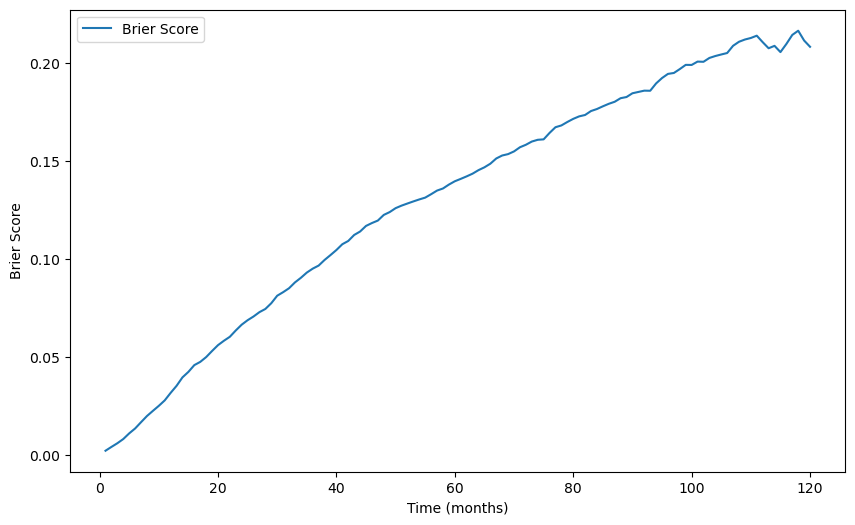

In [ ]:
# Metrics of the best RSF model
final_c_index = best.score(X_test, y_test)  # Compute the final C-index for the test dataset

# Print the C-index for both test and training datasets
print(f'C-Index Test: {final_c_index}')
print(f'C-Index Train: {best.score(X_train, y_train)}\n')

# Compute and display the IPCW C-index and Brier Score for the best model
c_index_ipcw_brier_score(best, X_train, y_train, X_test, y_test)

In [ ]:
# Best features by permutation importance
calculate_permutation_importance(best, X_test, y_test, feat_cols, random_state=seed)  # Calculate permutation importance of features for the best model

,importances_mean,importances_std
ECGRUP,0.076790,0.005057
IDADE,0.062305,0.003500
PSA,0.013920,0.002057
DIAGTRAT_CAT,0.010592,0.001532
INSTITU,0.009878,0.001082
TRATCONS_CAT,0.006945,0.001144
MORFO,0.002517,0.000733
DRS_INST,0.002164,0.000683
IBGEATEN,0.001775,0.000410
DRS,0.001484,0.000389


PermutationExplainer explainer: 5677it [1:31:28,  1.03it/s]                          


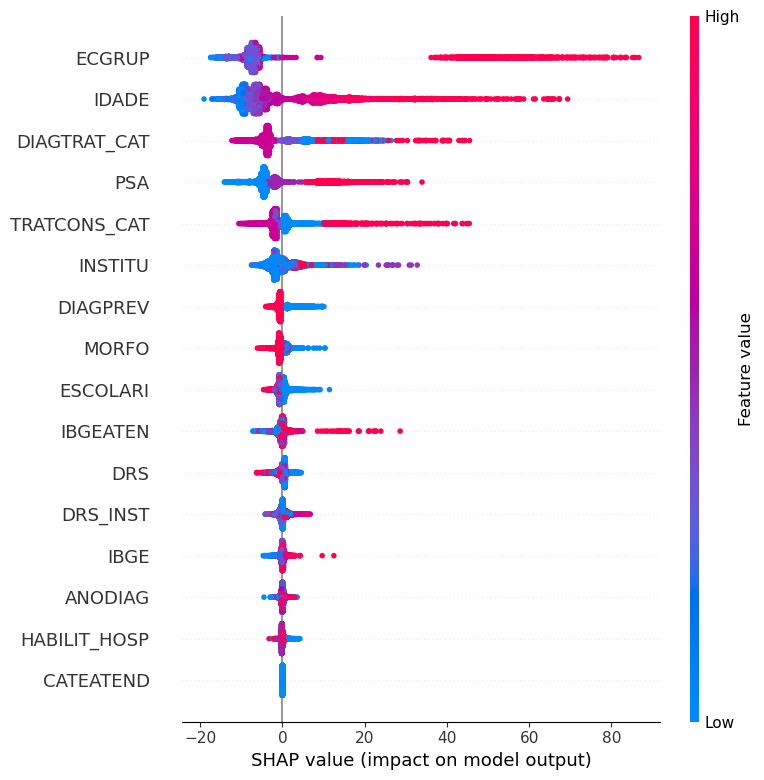

In [ ]:
# Best features by SHAP
explainer = shap.Explainer(best.predict, X_train, seed=seed,  # Create a SHAP explainer for the best model
                           output_names=feat_cols,  # Specify the feature names
                           n_jobs=-1)  # Use multiple jobs for parallel computation

shap_values = explainer(X_test)  # Calculate SHAP values for the test set

# Plot the SHAP summary plot to visualize feature importance
shap.summary_plot(shap_values, X_test, feature_names=feat_cols)

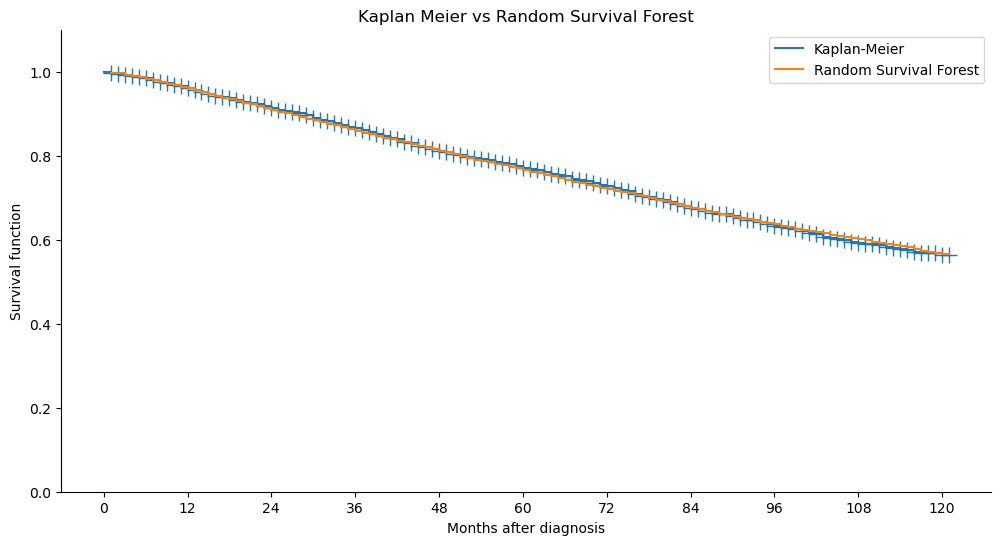

In [ ]:
# Comparison of survival curves
name = 'Random Survival Forest'  # Name of the model to be displayed on the plot

# Predict survival functions for the test set and compute the mean survival function
surv_rsf = best.predict_survival_function(X_test, return_array=True)
surv_rsf_mean = surv_rsf.mean(axis=0)  # Compute the mean survival function across all samples

# Plot the survival curve and compare with Kaplan-Meier (KM) estimates
plot_survival_curve(best.unique_times_, surv_rsf_mean,
                    name=name, compare_km=True, test_df=df_teste)  # Plot the survival curve and compare with the test dataset

### **XGBoost - AFT**

#### **Base Model**

In [ ]:
# Define weights (1.0 for events, 0.7 for censored cases)
weights = np.where(y_train['event'], 1.0, 0.7)

# The AFT model requires lower and upper bounds for survival time
label_lower_bound = y_train['time']
label_upper_bound = np.where(y_train['event'], y_train['time'], np.inf)

# Creating DMatrix for XGBoost (necessary to define bounds for AFT)
dtrain = xgb.DMatrix(X_train,
                     label_lower_bound=label_lower_bound,
                     label_upper_bound=label_upper_bound,
                     weight=weights)

dtest = xgb.DMatrix(X_test)

# Configuration of hyperparameters for the XGBoost Survival AFT model
params = {
    'objective': 'survival:aft',  # Use AFT to model survival analysis
    'eval_metric': 'aft-nloglik',  # Evaluation metric for AFT
    'aft_loss_distribution': 'normal',  # Failure time distribution ('normal', 'logistic', etc.)
    'aft_loss_distribution_scale': 1.0,  # Scale of the distribution (adjustable)
    'max_depth': 3,  # Maximum depth of trees
    'seed': seed,  # Seed for reproducibility
}

# Model training
xgb_aft = xgb.train(params, dtrain, num_boost_round=100)

# Predictions and C-Index calculation for the test set
y_pred = xgb_aft.predict(dtest)
c_index_base = concordance_index_censored(y_test['event'], y_test['time'], -y_pred)[0]

# Predictions and C-Index calculation for the training set
y_pred_train = xgb_aft.predict(dtrain)
c_index_train = concordance_index_censored(y_train['event'], y_train['time'], -y_pred_train)[0]

# Display C-Index results
print(f'C-index Test: {c_index_base}')
print(f'C-index Train: {c_index_train}')

C-index Test: 0.744338550798779
C-index Train: 0.7683628938939345


In [ ]:
# C-Index IPCW (Inverse Probability of Censoring Weight)
surv_risks = xgb_aft.predict(dtest)  # Predict the survival risks for the test set
surv_risks_train = xgb_aft.predict(dtrain)  # Predict the survival risks for the training set

# Calculate the C-Index IPCW for Test and Train data
c_index_ipcw = concordance_index_ipcw(y_train, y_test, -surv_risks)  # Compute the C-Index IPCW for the test data
c_index_ipcw_train = concordance_index_ipcw(y_train, y_train, -surv_risks_train)  # Compute the C-Index IPCW for the training data

# Display C-Index IPCW for Test and Train data
print(f'C-Index IPCW Test: {c_index_ipcw[0]}')  # Print the C-Index IPCW for the test data
print(f'C-Index IPCW Train: {c_index_ipcw_train[0]}')  # Print the C-Index IPCW for the training data

C-Index IPCW Test: 0.7083042455420171
C-Index IPCW Train: 0.7354466418379436


#### **Optuna**

**Principais Parâmetros a Otimizar no XGBoost**

1. `n_estimators` (int):
* Número de árvores (boosting rounds) que o modelo vai treinar. Mais árvores podem melhorar o aprendizado, mas aumentam o risco de overfitting e o custo computacional.
* Sugestão de valores: 50 a 1000.

2. `learning_rate` (float):
* Taxa de aprendizado usada para diminuir a contribuição de cada árvore. Taxas menores exigem mais árvores, mas aumentam a estabilidade.
* Sugestão de valores: 0.01 a 0.3 (log-scale).

3. `max_depth` (int):
* Profundidade máxima das árvores individuais. Árvores mais profundas captam interações complexas, mas correm maior risco de overfitting.
* Sugestão de valores: 3 a 30.

4. `min_child_weight` (float):
* Peso mínimo da soma dos gradientes (hessian) em uma divisão de nó. Controla o tamanho mínimo de uma divisão, evitando overfitting.
* Sugestão de valores: 1 a 10.

5. `subsample` (float):
* Percentual de amostras utilizadas em cada árvore. Reduz overfitting ao amostrar dados de forma aleatória.
* Sugestão de valores: 0.5 a 1.0.

6. `colsample_bytree` (float):
* Percentual de colunas (features) usadas para cada árvore. Melhora a robustez e evita correlação entre as árvores.
* Sugestão de valores: 0.5 a 1.0.

7. `reg_alpha` (float):
* Regularização L1 (sparsidade). Incentiva a geração de árvores mais esparsas, evitando overfitting.
* Sugestão de valores: 1e-5 a 10 (log-scale).

8. `reg_lambda` (float):
* Regularização L2 (penalização quadrática). Controla a complexidade do modelo.
* Sugestão de valores: 1e-5 a 10 (log-scale).

9. `objective` (str):
* Função objetivo. Para sobrevivência, pode-se usar:

    'survival:cox': Regressão de Cox.
    
    'survival:aft': Modelo AFT (Accelerated Failure Time).

In [ ]:
# Optuna number o trials
n_trials = 128

In [ ]:
# Folds for Cross-Validation
kf = KFold(10, shuffle=True, random_state=seed)  # Create 10-fold cross-validation with shuffling

def objective(trial):
    # Define the hyperparameters to be optimized
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 150),  # Number of estimators (trees)
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.25, step=0.01),  # Learning rate
        'max_depth': trial.suggest_int('max_depth', 2, 5),  # Maximum depth of trees
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),  # Minimum weight of child nodes
        'subsample': trial.suggest_float('subsample', 0.5, 1.0, step=0.05),  # Fraction of data used for training
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0, step=0.05),  # Fraction of features used per tree
        'reg_alpha': trial.suggest_categorical('reg_alpha', [1e-4, 1e-3, 1e-2, 1e-1, 1, 10]),  # L1 regularization term
        'reg_lambda': trial.suggest_categorical('reg_lambda', [1e-4, 1e-3, 1e-2, 1e-1, 1, 10]),  # L2 regularization term
        'aft_loss_distribution': trial.suggest_categorical('aft_loss_distribution', ['normal', 'logistic', 'extreme']),  # AFT Distribution Type
        'aft_loss_distribution_scale': trial.suggest_float('aft_loss_distribution_scale', 0.5, 2.0, step=0.05),  # AFT distribution scale
        'objective': 'survival:aft',  # AFT loss function for survival analysis
        'eval_metric': 'aft-nloglik',  # Evaluation metric for AFT model
        'random_state': seed,  # Seed for reproducibility
        'n_jobs': -1,  # Use all available cores for training
    }

    fold_c_indices = []  # List to store the C-index values from each fold

    # Loop over the folds in cross-validation
    for train_idx, valid_idx in kf.split(X_train):
        try:
            # Split the data into training and validation sets for the current fold
            X_t, X_v = X_train[train_idx], X_train[valid_idx]  # Split features
            y_t, y_v = y_train[train_idx], y_train[valid_idx]  # Split labels

            # Defining the lower and upper limits for AFT (survival time)
            label_lower_bound = y_t['time']
            label_upper_bound = np.where(y_t['event'], y_t['time'], np.inf)

            # Create DMatrix for training and validation (DMatrix is an optimized data structure for XGBoost)
            dtrain = xgb.DMatrix(X_t, label_lower_bound=label_lower_bound,
                                 label_upper_bound=label_upper_bound,
                                 weight=np.where(y_t['event'], 1.0, 0.7))  # Set event weights

            dvalid = xgb.DMatrix(X_v)  # Validation DMatrix (no labels, predictions will be made)

            # Train the XGBoost model using the specified hyperparameters
            model = xgb.train(param, dtrain, num_boost_round=100, verbose_eval=False)  # Train model with 100 boosting rounds

            # Make predictions on the validation set
            pred_valid = model.predict(dvalid)

            # Calculate the Concordance Index (C-Index) for the validation fold
            c_index = concordance_index_censored(y_v['event'],
                                                 y_v['time'],
                                                 -pred_valid)[0]
            fold_c_indices.append(c_index)  # Append the C-Index for this fold to the list

        except (ValueError, xgb.core.XGBoostError) as e:
            continue  # Next Fold

    # Return the average C-Index
    return np.nanmean(fold_c_indices)  # The objective function returns the mean C-Index from the cross-validation folds

**RandomSampler**

In [ ]:
# Hyperparameter optimization with Optuna - RandomSampler
study = optuna.create_study(direction='maximize', sampler=RandomSampler(seed),  # Create a study to maximize the objective function
                            study_name='XGB_RandomSampler')  # Study name

study.optimize(objective, n_trials=n_trials, n_jobs=-1)  # Run the optimization with 'n_trials' trials in parallel

[I 2026-06-23 18:21:04,040] A new study created in memory with name: XGB_RandomSampler
[I 2026-06-23 18:21:15,071] Trial 0 finished with value: 0.7026557835928091 and parameters: {'n_estimators': 57, 'learning_rate': 0.09999999999999999, 'max_depth': 3, 'min_child_weight': 8, 'subsample': 0.75, 'colsample_bytree': 0.55, 'reg_alpha': 0.1, 'reg_lambda': 1, 'aft_loss_distribution': 'logistic', 'aft_loss_distribution_scale': 0.75}. Best is trial 0 with value: 0.7026557835928091.
[I 2026-06-23 18:21:17,715] Trial 1 finished with value: 0.7438227691112359 and parameters: {'n_estimators': 148, 'learning_rate': 0.060000000000000005, 'max_depth': 5, 'min_child_weight': 4, 'subsample': 0.6, 'colsample_bytree': 0.65, 'reg_alpha': 0.01, 'reg_lambda': 0.0001, 'aft_loss_distribution': 'extreme', 'aft_loss_distribution_scale': 1.05}. Best is trial 1 with value: 0.7438227691112359.
[I 2026-06-23 18:21:26,468] Trial 2 finished with value: 0.6011198778347728 and parameters: {'n_estimators': 96, 'learnin

In [ ]:
# Display the best hyperparameters found
print('Best parameters:', study.best_params)

Best parameters: {'n_estimators': 71, 'learning_rate': 0.09999999999999999, 'max_depth': 5, 'min_child_weight': 9, 'subsample': 0.9, 'colsample_bytree': 0.7, 'reg_alpha': 0.1, 'reg_lambda': 10, 'aft_loss_distribution': 'normal', 'aft_loss_distribution_scale': 1.4}


In [ ]:
# Training and evaluation with the best hyperparameters
weights = np.where(y_train['event'], 1.0, 0.7)  # Assign higher weights to events (1.0 for event and 0.7 for non-event)

# The AFT model requires lower and upper bounds for survival time
label_lower_bound = y_train['time']
label_upper_bound = np.where(y_train['event'], y_train['time'], np.inf)

best_params = study.best_params  # Get the best parameters from the study
best_params.update({'objective': 'survival:aft',  # AFT loss function for survival analysis
                    'eval_metric': 'aft-nloglik',  # Evaluation metric for AFT model
                    'random_state': seed,  # Seed for reproducibility
                    'n_jobs': -1})  # Use all available cores for training

# Prepare the DMatrix objects for training and testing data
dtrain = xgb.DMatrix(X_train,
                     label_lower_bound=label_lower_bound,
                     label_upper_bound=label_upper_bound,
                     weight=weights)  # DMatrix for training with weights

dtest = xgb.DMatrix(X_test)  # DMatrix for testing without labels

# Train the XGBoost model with the best parameters
xgb_rand = xgb.train(best_params, dtrain, num_boost_round=100)

# Make predictions on the test and training datasets
y_pred = xgb_rand.predict(dtest)  # Predictions on the test data
y_pred_train = xgb_rand.predict(dtrain)  # Predictions on the training data

# Calculate the Concordance Index (C-Index) for test and training predictions
c_index_rand = concordance_index_censored(y_test['event'], y_test['time'], -y_pred)[0]  # C-Index for test
c_index_rand_train = concordance_index_censored(y_train['event'], y_train['time'], -y_pred_train)[0]  # C-Index for train

# Print the C-Index values
print(f'C-Index Test: {c_index_rand}')  # C-Index for the test set
print(f'C-Index Train: {c_index_rand_train}')  # C-Index for the training set

C-Index Test: 0.745278240007799
C-Index Train: 0.7715680389121674


**TPESampler**

In [ ]:
# Hyperparameter optimization with Optuna - TPESampler
study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=seed),  # Create a study with TPE sampler for optimization
                            study_name='XGB_TPESampler')  # Study name for identification

study.optimize(objective, n_trials=n_trials, n_jobs=-1)  # Run optimization for 'n_trials' trials using parallel processing

[I 2026-06-23 18:33:09,582] A new study created in memory with name: XGB_TPESampler
[I 2026-06-23 18:33:21,544] Trial 0 finished with value: 0.7378925379268368 and parameters: {'n_estimators': 125, 'learning_rate': 0.12, 'max_depth': 2, 'min_child_weight': 9, 'subsample': 0.55, 'colsample_bytree': 0.75, 'reg_alpha': 10, 'reg_lambda': 1, 'aft_loss_distribution': 'extreme', 'aft_loss_distribution_scale': 1.6500000000000001}. Best is trial 0 with value: 0.7378925379268368.
[I 2026-06-23 18:33:21,809] Trial 1 finished with value: 0.7378619401895764 and parameters: {'n_estimators': 85, 'learning_rate': 0.11, 'max_depth': 2, 'min_child_weight': 1, 'subsample': 0.65, 'colsample_bytree': 0.75, 'reg_alpha': 0.01, 'reg_lambda': 0.001, 'aft_loss_distribution': 'extreme', 'aft_loss_distribution_scale': 0.65}. Best is trial 0 with value: 0.7378925379268368.
[I 2026-06-23 18:33:33,807] Trial 3 finished with value: 0.7466526006481542 and parameters: {'n_estimators': 66, 'learning_rate': 0.05, 'max_de

In [ ]:
# Display the best hyperparameters found during optimization
print('Best parameters:', study.best_params)

Best parameters: {'n_estimators': 83, 'learning_rate': 0.19, 'max_depth': 3, 'min_child_weight': 6, 'subsample': 1.0, 'colsample_bytree': 0.9, 'reg_alpha': 0.01, 'reg_lambda': 0.0001, 'aft_loss_distribution': 'normal', 'aft_loss_distribution_scale': 1.15}


In [ ]:
# Training and evaluation with the best hyperparameters
weights = np.where(y_train['event'], 1.0, 0.7)  # Assign higher weights to events (1.0 for event and 0.7 for non-event)

# The AFT model requires lower and upper bounds for survival time
label_lower_bound = y_train['time']
label_upper_bound = np.where(y_train['event'], y_train['time'], np.inf)

best_params = study.best_params  # Get the best parameters from the study
best_params.update({'objective': 'survival:aft',  # AFT loss function for survival analysis
                    'eval_metric': 'aft-nloglik',  # Evaluation metric for AFT model
                    'random_state': seed,  # Seed for reproducibility
                    'n_jobs': -1})  # Use all available cores for training

# Prepare the DMatrix objects for training and testing data
dtrain = xgb.DMatrix(X_train,
                     label_lower_bound=label_lower_bound,
                     label_upper_bound=label_upper_bound,
                     weight=weights)  # DMatrix for training with weights

dtest = xgb.DMatrix(X_test)  # DMatrix for testing without labels

# Train the XGBoost model with the best parameters
xgb_tpe = xgb.train(best_params, dtrain, num_boost_round=100)

# Make predictions on the test and training datasets
y_pred = xgb_tpe.predict(dtest)  # Predictions on the test data
y_pred_train = xgb_tpe.predict(dtrain)  # Predictions on the training data

# Calculate the Concordance Index (C-Index) for test and training predictions
c_index_tpe = concordance_index_censored(y_test['event'], y_test['time'], -y_pred)[0]  # C-Index for test
c_index_tpe_train = concordance_index_censored(y_train['event'], y_train['time'], -y_pred_train)[0]  # C-Index for train

# Print the C-Index values
print(f'C-Index Test: {c_index_tpe}')  # C-Index for the test set
print(f'C-Index Train: {c_index_tpe_train}')  # C-Index for the training set

C-Index Test: 0.7453145235624463
C-Index Train: 0.7634380746551979


**CmaEsSampler**

In [ ]:
# Hyperparameter optimization with Optuna - CmaEsSampler
study = optuna.create_study(direction='maximize', sampler=CmaEsSampler(seed=seed),  # Create a study with CMA-ES sampler for optimization
                            study_name='XGB_CmaEsSampler')  # Study name for identification

study.optimize(objective, n_trials=n_trials, n_jobs=-1)  # Run optimization for 'n_trials' trials using parallel processing

[I 2026-06-23 18:44:11,438] A new study created in memory with name: XGB_CmaEsSampler
[I 2026-06-23 18:44:21,283] Trial 0 finished with value: 0.7449522043762377 and parameters: {'n_estimators': 85, 'learning_rate': 0.18000000000000002, 'max_depth': 2, 'min_child_weight': 4, 'subsample': 0.75, 'colsample_bytree': 0.55, 'reg_alpha': 0.001, 'reg_lambda': 0.0001, 'aft_loss_distribution': 'normal', 'aft_loss_distribution_scale': 1.2000000000000002}. Best is trial 0 with value: 0.7449522043762377.
[W 2026-06-23 18:44:21,356] The parameter `reg_alpha` in Trial#2 is sampled independently using `RandomSampler` instead of `CmaEsSampler`, potentially degrading the optimization performance. This fallback happened because dynamic search space and `CategoricalDistribution` are not supported by `CmaEsSampler`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `CmaEsSampler` if this independent sampling is intended behavior.
[W 2026-06-23 18:44:21,3

In [ ]:
# Display the best hyperparameters found during optimization
print('Best parameters:', study.best_params)

Best parameters: {'n_estimators': 84, 'learning_rate': 0.15000000000000002, 'max_depth': 4, 'min_child_weight': 8, 'subsample': 0.8, 'colsample_bytree': 0.65, 'reg_alpha': 0.1, 'reg_lambda': 1, 'aft_loss_distribution': 'normal', 'aft_loss_distribution_scale': 1.15}


In [ ]:
# Training and evaluation with the best hyperparameters
weights = np.where(y_train['event'], 1.0, 0.7)  # Assign higher weights to events (1.0 for event and 0.7 for non-event)

# The AFT model requires lower and upper bounds for survival time
label_lower_bound = y_train['time']
label_upper_bound = np.where(y_train['event'], y_train['time'], np.inf)

best_params = study.best_params  # Get the best parameters from the study
best_params.update({'objective': 'survival:aft',  # AFT loss function for survival analysis
                    'eval_metric': 'aft-nloglik',  # Evaluation metric for AFT model
                    'random_state': seed,  # Seed for reproducibility
                    'n_jobs': -1})  # Use all available cores for training

# Prepare the DMatrix objects for training and testing data
dtrain = xgb.DMatrix(X_train,
                     label_lower_bound=label_lower_bound,
                     label_upper_bound=label_upper_bound,
                     weight=weights)  # DMatrix for training with weights

dtest = xgb.DMatrix(X_test)  # DMatrix for testing without labels

# Train the XGBoost model with the best parameters
xgb_cma = xgb.train(best_params, dtrain, num_boost_round=100)

# Make predictions on the test and training datasets
y_pred = xgb_cma.predict(dtest)  # Predictions on the test data
y_pred_train = xgb_cma.predict(dtrain)  # Predictions on the training data

# Calculate the Concordance Index (C-Index) for test and training predictions
c_index_cma = concordance_index_censored(y_test['event'], y_test['time'], -y_pred)[0]  # C-Index for test
c_index_cma_train = concordance_index_censored(y_train['event'], y_train['time'], -y_pred_train)[0]  # C-Index for train

# Print the C-Index values
print(f'C-Index Test: {c_index_cma}')  # C-Index for the test set
print(f'C-Index Train: {c_index_cma_train}')  # C-Index for the training set

C-Index Test: 0.7470051177836281
C-Index Train: 0.7699818226162777


#### **Best XGBoost Model**

In [ ]:
# Best XGBoost model
scores = [c_index_base, c_index_rand, c_index_tpe, c_index_cma]  # List of C-index scores for each model
models = [xgb_aft, xgb_rand, xgb_tpe, xgb_cma]  # List of the trained models

# Find the model with the highest C-index
id_best_score = scores.index(max(scores))  # Get the index of the model with the best score
best = models[id_best_score]  # Select the best model based on the highest C-index

print(best)  # Display the best model

In [ ]:
# Make predictions on the validation and training sets
y_pred = best.predict(dtest)  # Predictions on the test set
y_pred_train = best.predict(dtrain)  # Predictions on the training set

# Calculate the C-Index for the test and training sets
final_c_index = concordance_index_censored(y_test['event'], y_test['time'], -y_pred)[0]  # C-Index for the test set
final_c_index_train = concordance_index_censored(y_train['event'], y_train['time'], -y_pred_train)[0]  # C-Index for the training set

print('C-Index')  # Print label for C-Index
print(f'> Test: {final_c_index}')  # Print C-Index for the test set
print(f'> Train: {final_c_index_train}')  # Print C-Index for the training set

c_index_ipcw = concordance_index_ipcw(y_train, y_test, -y_pred)  # C-Index IPCW for the test set
c_index_ipcw_train = concordance_index_ipcw(y_train, y_train, -y_pred_train)  # C-Index IPCW for the training set

print('\nC-Index IPCW')  # Print label for C-Index IPCW
print(f'> Test: {c_index_ipcw[0]}')  # Print IPCW C-Index for the test set
print(f'> Train: {c_index_ipcw_train[0]}')  # Print IPCW C-Index for the training set

C-Index
> Test: 0.7470051177836281
> Train: 0.7699818226162777

C-Index IPCW
> Test: 0.7109987622682812
> Train: 0.7364171797990554


In [ ]:
# Best features by permutation importance
calculate_permutation_importance_xgb(best, X_test, y_test, feat_cols, random_state=seed)  # Calculate permutation importance of features for the best model

,importances_mean,importances_std
CATEATEND,0.000000,0.000000
IBGE,-0.000083,0.000710
MORFO,-0.000390,0.000336
ANODIAG,-0.000609,0.000466
HABILIT_HOSP,-0.000634,0.000217
DIAGPREV,-0.001344,0.000563
DRS,-0.001412,0.000573
ESCOLARI,-0.001637,0.000619
DRS_INST,-0.003724,0.000934
IBGEATEN,-0.004584,0.001088


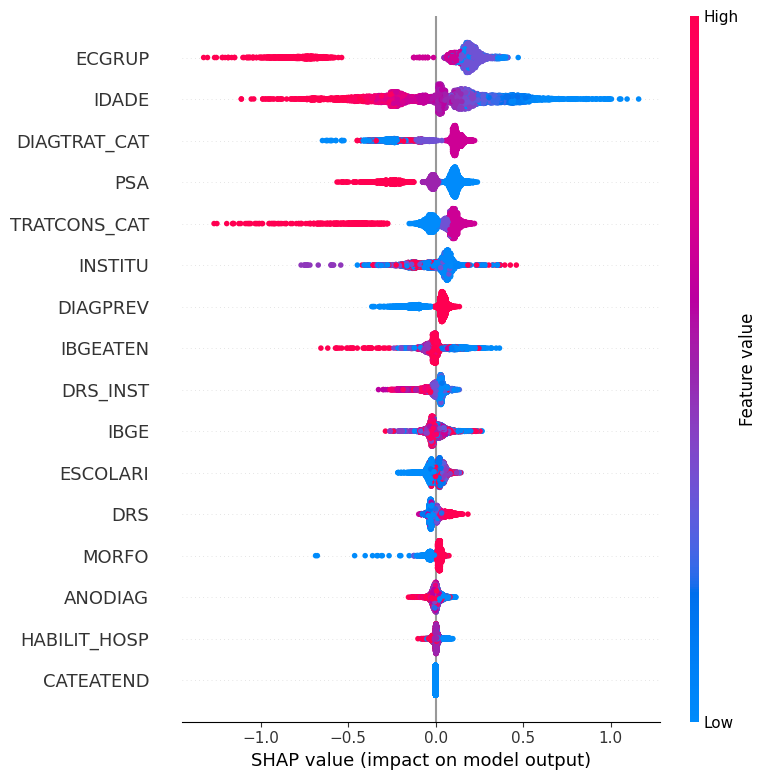

In [ ]:
# Create a SHAP TreeExplainer for the best model
explainer = shap.TreeExplainer(best)

# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test)

# Generate a summary plot to visualize the SHAP values for each feature
shap.summary_plot(shap_values, X_test, feature_names=feat_cols)